As an exploratory representation-learning analysis, downsampled epoch-level wPLI networks are encoded using a compact edge-aware GATv2 autoencoder. The learned graph embeddings are examined longitudinally and in relation to independently scored sleep stages. Because repeated epochs within participant are correlated and the dataset includes 28 participants, analyses emphasize within-subject trajectories and transition-associated embedding changes rather than claims of clinical staging performance. The GATv2 representation examines whether the evolving connectivity graph has a compact, data-driven latent structure.

The point is to show: epoch-level functional networks have a learnable low-dimensional structure, and that structure can be examined in relation to sleep stage, within-stage stability, and stage transitions.

| Term                | Applies to            | Shape for one graph | Meaning                                                 |
| ------------------- | --------------------- | ------------------- | ------------------------------------------------------- |
| Input node features | Each electrode/node   | 83×483 \\times 483×4 | x,y,zx,y,zx,y,z coordinates plus weighted node strength |
| Hidden channels     | Each electrode/node   | 83×883 \\times 883×8 | Learned representation of each electrode after GATv2    |
| Graph embedding     | The whole epoch graph | 888                 | One summary vector for the full 83-electrode graph      |

Input:
83 nodes × 4 features

After GATv2 layer 1:
83 nodes × 8 hidden values
(or 83 × 16 temporarily if using 2 concatenated heads)

After GATv2 layer 2:
83 nodes × 8 final node embeddings

Global pooling:
83 node embeddings × 8
→ one graph embedding × 8

They happen to have the same number because of the architecture choice, but: hidden_channels = 8 means eight learned values per node, and graph_embedding_dim = 8 means eight learned values for the whole graph.

In [2]:
# ------------------------------------------------------------------
# Phase B — Dynamic wPLI Graph Representation Learning
#
# Goal:
# Learn an unsupervised representation of downsampled epoch-level delta-band functional connectivity graphs across the night.
#
# Each graph represents:
# - One 30-second EEG epoch
# - One participant
# - One frequency band (delta initially)
# - 83 EEG electrodes as nodes
# - Top 20% wPLI connections as edges
#
# The GATv2 graph autoencoder learns to distinguish:
# - Retained high-wPLI edges (positive edges)
# - Randomly sampled non-retained pairs (negative edges)
#
# After training, every selected epoch gets an 8D graph embedding.
# These embeddings can be related to:
# - Time through the night
# - Scored sleep stage
# - Stable-stage segments
# - Stage transitions
# - Classical graph metrics
# ------------------------------------------------------------------

from pathlib import Path
from collections import Counter
import copy
import json
import random
import time
import re

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import torch
import torch.nn.functional as F

from torch import nn
from torch.optim import AdamW

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv, global_mean_pool
from torch_geometric.utils import batched_negative_sampling


# ------------------------------------------------------------------
# Reproducibility settings.
# ------------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)


# ------------------------------------------------------------------
# Plot style.
# ------------------------------------------------------------------

sns.set_theme(
    style="whitegrid",
    context="talk",
)

PyTorch version: 2.12.1+cpu
Device: cpu


In [ ]:
# ------------------------------------------------------------------
# Input and output paths.
#
# EPOCH_GRAPH_DIR contains the original per-subject HDF5 files:
#
# EPCTL01.h5
# EPCTL02.h5
# ...
#
# Each one contains:
# - epoch-level stage labels
# - epoch indices
# - channel names
# - one (n_epochs, 83, 83) wPLI dataset per frequency band
# ------------------------------------------------------------------

EPOCH_GRAPH_DIR = Path(
    r"..\graphs_output"
)

POS_PATH = Path(
    r"..\anphy_sleep_data\co-registered_average_positions.pos"
)

PHASE_B_OUTPUT_DIR = Path(
    r"..\graphs_output\phase_B_gatv2_autoencoder"
)

PHASE_B_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


#Choices:

BAND_TO_RUN = "delta"

# Keep one ordinary graph every 10 original 30-second epochs:
# 10 × 30 seconds = 300 seconds = 5 minutes.
EPOCH_STRIDE = 10

# Keep the strongest 20% of undirected wPLI edges.
RETAINED_DENSITY = 0.20

# At every stage boundary, additionally preserve:
# t - 1, t, t + 1
KEEP_TRANSITION_NEIGHBOURS = True

# The first band-specific run uses all selected epoch graphs from
# every participant, but splits participants—not epochs—into:
# training / validation / held-out exploratory test.
VALIDATION_SUBJECTS = [
    "EPCTL04",
    "EPCTL05",
    "EPCTL06",
]

TEST_SUBJECTS = [
    "EPCTL01",
    "EPCTL02",
    "EPCTL03",
]

STAGE_ORDER = [
    "Wake",
    "N1",
    "N2",
    "N3",
    "REM",
]

BAND_ORDER = [
    "delta",
    "theta",
    "alpha",
    "sigma",
    "beta",
]

N_NODES = 83
N_COORDINATE_FEATURES = 3
N_NODE_FEATURES = 4  # x/y/z coordinates + weighted node strength


# ------------------------------------------------------------------
# Model hyperparameters.
#
# Keep the model small because epochs are repeated observations from
# 28 participants, not independent people.
# ------------------------------------------------------------------

HIDDEN_CHANNELS = 8
ATTENTION_HEADS = 2
DROPOUT = 0.30

GRAPH_EMBEDDING_DIM = 8

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

BATCH_SIZE = 4

MAX_EPOCHS = 50
PATIENCE = 10

# Sample approximately one negative directed edge per positive
# directed edge in each batch.
NEGATIVE_SAMPLING_RATIO = 1.0


# ------------------------------------------------------------------
# Expected input file list.
# ------------------------------------------------------------------

epoch_h5_paths = sorted(
    EPOCH_GRAPH_DIR.glob("EPCTL*.h5")
)

if not epoch_h5_paths:
    raise FileNotFoundError(
        "No subject epoch-level HDF5 files found in:\n"
        f"{EPOCH_GRAPH_DIR.resolve()}\n\n"
        "Check EPOCH_GRAPH_DIR."
    )

if not POS_PATH.exists():
    raise FileNotFoundError(
        "Could not find the co-registered electrode position file:\n"
        f"{POS_PATH}"
    )

print("Epoch-level HDF5 files found:", len(epoch_h5_paths))
print("First file:", epoch_h5_paths[0].name)

print("\nLocked Phase B configuration:")
print("Band:", BAND_TO_RUN)
print("Epoch stride:", EPOCH_STRIDE)
print("Graph density:", RETAINED_DENSITY)
print("Transition neighbours:", KEEP_TRANSITION_NEIGHBOURS)
print("Hidden channels:", HIDDEN_CHANNELS)
print("Graph embedding dimension:", GRAPH_EMBEDDING_DIM)

Epoch-level HDF5 files found: 28
First file: EPCTL01.h5

Locked Phase B configuration:
Band: delta
Epoch stride: 10
Graph density: 0.2
Transition neighbours: True
Hidden channels: 8
Graph embedding dimension: 8


In [ ]:
# ------------------------------------------------------------------
# Helper functions used throughout Phase B.
# ------------------------------------------------------------------

def decode_value(value):
    """
    Convert HDF5 strings stored as bytes into normal Python strings.
    """
    return (
        value.decode()
        if isinstance(value, bytes)
        else str(value)
    )


def normalize_channel_name(name):
    """
    Normalize a channel name for matching across EDF / HDF5 / .pos.

    Examples:
    FZ       -> fz
    Fz       -> fz
    C3-REF   -> c3
    C3-CAR   -> c3

    This is used only for name matching. Original channel labels are
    preserved as graph metadata.
    """
    name = str(name).strip().lower()

    for suffix in [
        "-ref",
        "ref",
        "-avg",
        "avg",
        "-car",
        "car",
    ]:
        if name.endswith(suffix):
            name = name[:-len(suffix)]

    name = re.sub(
        r"^[-_.\s]+|[-_.\s]+$",
        "",
        name,
    )

    return name


def read_anphy_sleep_pos_file(pos_path):
    """
    Read the ANPHY-Sleep .pos file.

    Expected file format:
    First line:
        83

    Then 83 rows:
        index  channel_name  x  y  z

    Coordinates in the source file are centimetres.
    This function returns values in metres.

    Returns
    -------
    position_by_pos_name : dict
        Maps the original .pos channel name to an array:
        np.array([x_m, y_m, z_m]).
    """
    position_by_pos_name = {}

    with open(pos_path, "r", encoding="utf-8") as f:

        first_line = f.readline().strip()

        try:
            n_pos_channels = int(first_line)
        except ValueError as exc:
            raise ValueError(
                "Expected an integer channel count on the first line "
                f"of the .pos file, but found {first_line!r}."
            ) from exc

        for row_index in range(n_pos_channels):

            line = f.readline().strip()

            if not line:
                raise ValueError(
                    f"Unexpected blank .pos row at index {row_index}."
                )

            parts = line.split()

            if len(parts) != 5:
                raise ValueError(
                    "Every .pos channel row must contain five values:\n"
                    "index name x y z\n\n"
                    f"Problem row: {line!r}"
                )

            position_index, channel_name, x_cm, y_cm, z_cm = parts

            # Validate the position-file index even though channel
            # labels, rather than indices, are used for matching.
            _ = int(position_index)

            position_cm = np.array(
                [
                    float(x_cm),
                    float(y_cm),
                    float(z_cm),
                ],
                dtype=np.float32,
            )

            position_m = position_cm / 100.0

            if channel_name in position_by_pos_name:
                raise ValueError(
                    "Duplicate electrode label in .pos file: "
                    f"{channel_name!r}"
                )

            position_by_pos_name[channel_name] = position_m

    return position_by_pos_name


def inspect_epoch_h5_file(h5_path):
    """
    Print key metadata and dataset shapes from one epoch-level HDF5
    file. This prevents accidentally using stage-mean files.
    """
    with h5py.File(h5_path, "r") as f:

        print("File:", h5_path.name)
        print("Root attributes:", list(f.attrs.keys()))
        print("Top-level datasets/groups:", list(f.keys()))

        subject_id = decode_value(
            f.attrs.get("subject_id", h5_path.stem)
        )

        print("Subject ID:", subject_id)

        if "stage" in f:
            print("stage shape:", f["stage"].shape)

        if "epoch_idx" in f:
            print("epochidx shape:", f["epoch_idx"].shape)

        if "channelnames" in f:
            print("channelnames shape:", f["channelnames"].shape)

        elif "channel_names" in f:
            print(
                "channel_names shape:",
                f["channel_names"].shape,
            )

        for band in BAND_ORDER:
            if band in f:
                print(
                    f"{band} shape:",
                    f[band].shape,
                )


inspect_epoch_h5_file(
    epoch_h5_paths[0]
)

File: EPCTL01.h5
Root attributes: ['bands', 'max_bad_fraction', 'n_epochs', 'subject_id']
Top-level datasets/groups: ['alpha', 'beta', 'channel_names', 'delta', 'epoch_idx', 'n_bad_channels', 'sigma', 'stage', 'theta']
Subject ID: EPCTL01
stage shape: (952,)
channel_names shape: (83,)
delta shape: (952, 83, 83)
theta shape: (952, 83, 83)
alpha shape: (952, 83, 83)
sigma shape: (952, 83, 83)
beta shape: (952, 83, 83)


In [6]:
# ------------------------------------------------------------------
# Read the 83 physical electrode positions once.
#
# These positions remain in metres and are never standardized in this
# variable. Use them later for physically meaningful scalp plots.
# ------------------------------------------------------------------

position_by_pos_name = read_anphy_sleep_pos_file(
    POS_PATH
)

if len(position_by_pos_name) != N_NODES:
    raise ValueError(
        f"Expected {N_NODES} electrodes in .pos file, but found "
        f"{len(position_by_pos_name)}."
    )

position_by_normalized_channel = {}

for original_pos_name, position_m in (
    position_by_pos_name.items()
):
    normalized_name = normalize_channel_name(
        original_pos_name
    )

    if normalized_name in position_by_normalized_channel:
        raise ValueError(
            "Ambiguous position-file labels after normalization:\n"
            f"{original_pos_name!r} -> {normalized_name!r}"
        )

    position_by_normalized_channel[normalized_name] = (
        position_m.copy()
    )

print(
    "Physical electrode-position lookup created for",
    len(position_by_normalized_channel),
    "channels.",
)

print("\nExample position entries, in metres:")
for position_name in list(position_by_pos_name.keys())[:5]:
    print(
        position_name,
        "->",
        position_by_pos_name[position_name],
    )

Physical electrode-position lookup created for 83 channels.

Example position entries, in metres:
Fp1 -> [0.10560794 0.02908233 0.06274943]
Fp2 -> [ 0.1087859  -0.02347835  0.05977278]
F3 -> [0.06498792 0.0465418  0.10367873]
F4 -> [ 0.06016924 -0.05284127  0.10343477]
C3 -> [0.00708472 0.05980106 0.12086172]


In [8]:
# ------------------------------------------------------------------
# Phase B epoch selection:
#
# Keep:
# 1. Every EPOCH_STRIDE-th epoch for broad whole-night coverage.
# 2. Both sides of each scored stage boundary:
#    t - 1 = final epoch of old stage
#    t     = first epoch of new stage
#
# We intentionally do NOT retain t + 1 in the initial version.
# This keeps the dataset smaller while retaining the exact 30-second
# graph pair spanning every stage transition.
# ------------------------------------------------------------------

def select_epoch_positions(
    stage_labels,
    stride,
    keep_transition_neighbours=True,
):
    """
    Select longitudinal epochs and exact stage-boundary pairs.

    Parameters
    ----------
    stage_labels : array-like of str
        One scored sleep-stage label per stored 30-second epoch.

    stride : int
        Keep every `stride`-th stored epoch.

    keep_transition_neighbours : bool
        If True, retain:
        - t - 1: last epoch before a stage change
        - t: first epoch after a stage change

        A stage transition starts at t when:
        stage_labels[t] != stage_labels[t - 1].

    Returns
    -------
    selected_positions : np.ndarray
        Sorted, unique stored-epoch positions to retain.

    transition_positions : np.ndarray
        Positions t at which a new stage begins.
    """
    stage_labels = np.asarray(
        stage_labels,
        dtype=str,
    )

    n_epochs = len(stage_labels)

    if n_epochs == 0:
        raise ValueError(
            "No stage labels are available."
        )

    if stride < 1:
        raise ValueError(
            "stride must be at least 1."
        )

    # Rule 1: regular samples at a fixed five-minute interval when
    # EPOCH_STRIDE = 10.
    selected_positions = set(
        range(0, n_epochs, stride)
    )

    # A transition begins at t when the current label differs from
    # the immediately preceding 30-second epoch.
    transition_positions = np.flatnonzero(
        stage_labels[1:] != stage_labels[:-1]
    ) + 1

    # Rule 2: retain both sides of every stage boundary.
    if keep_transition_neighbours:

        for transition_position in transition_positions:

            # Last old-stage epoch.
            selected_positions.add(
                int(transition_position - 1)
            )

            # First new-stage epoch.
            selected_positions.add(
                int(transition_position)
            )

    selected_positions = np.array(
        sorted(selected_positions),
        dtype=np.int64,
    )

    return (
        selected_positions,
        transition_positions.astype(np.int64),
    )


# ------------------------------------------------------------------
# Test selection on the first subject file.
# ------------------------------------------------------------------

with h5py.File(epoch_h5_paths[0], "r") as f:

    raw_stage_labels = [
        decode_value(value)
        for value in f["stage"][:]
    ]

test_selected_positions, test_transition_positions = (
    select_epoch_positions(
        stage_labels=raw_stage_labels,
        stride=EPOCH_STRIDE,
        keep_transition_neighbours=KEEP_TRANSITION_NEIGHBOURS,
    )
)

print("Epochs in first subject:", len(raw_stage_labels))
print(
    "Transitions in first subject:",
    len(test_transition_positions),
)
print(
    "Selected epochs after stride + transitions:",
    len(test_selected_positions),
)

print("\nFirst 20 selected stored-epoch positions:")
print(test_selected_positions[:20])

print("\nFirst 10 transition positions:")
print(test_transition_positions[:10])

Epochs in first subject: 952
Transitions in first subject: 116
Selected epochs after stride + transitions: 274

First 20 selected stored-epoch positions:
[ 0  1  2  5  6  7 10 11 12 13 14 15 19 20 21 23 24 30 37 38]

First 10 transition positions:
[ 2  6  7 12 14 15 20 21 24 38]


In [9]:
# ------------------------------------------------------------------
# Graph-construction helpers.
#
# Every epoch starts as a dense weighted wPLI matrix:
# (83, 83)
#
# We retain the top 20% of undirected connections, create:
# - edge_index: source/destination node pairs
# - edge_attr: retained wPLI values
# - node features: scaled x/y/z + scaled weighted node strength
# ------------------------------------------------------------------

def prepare_adjacency(adjacency_matrix):
    """
    Ensure a wPLI adjacency matrix is symmetric, finite, non-negative,
    and has a zero diagonal.

    Parameters
    ----------
    adjacency_matrix : np.ndarray
        Expected shape: (83, 83).

    Returns
    -------
    adjacency_clean : np.ndarray
        Float32, symmetric, zero diagonal.
    """
    adjacency_clean = np.asarray(
        adjacency_matrix,
        dtype=np.float32,
    ).copy()

    if adjacency_clean.shape != (
        N_NODES,
        N_NODES,
    ):
        raise ValueError(
            f"Expected adjacency shape ({N_NODES}, {N_NODES}), "
            f"but got {adjacency_clean.shape}."
        )

    adjacency_clean = (
        adjacency_clean
        + adjacency_clean.T
    ) / 2.0

    np.fill_diagonal(
        adjacency_clean,
        0.0,
    )

    if not np.all(np.isfinite(adjacency_clean)):
        raise ValueError(
            "Adjacency matrix contains NaN or infinite values."
        )

    if np.any(adjacency_clean < 0):
        raise ValueError(
            "wPLI adjacency matrix contains negative values."
        )

    return adjacency_clean


def proportional_threshold(
    adjacency_matrix,
    density,
):
    """
    Retain the strongest requested proportion of undirected edges.

    Parameters
    ----------
    adjacency_matrix : np.ndarray
        Raw weighted wPLI graph, shape (83, 83).

    density : float
        Proportion of possible undirected edges to retain.
        For this Phase B run: 0.20.

    Returns
    -------
    adjacency_thresholded : np.ndarray
        Weighted symmetric matrix with zeros for non-retained edges.
    """
    if not (0 < density <= 1):
        raise ValueError(
            "density must be in (0, 1]."
        )

    adjacency_clean = prepare_adjacency(
        adjacency_matrix
    )

    upper_i, upper_j = np.triu_indices(
        N_NODES,
        k=1,
    )

    upper_weights = adjacency_clean[
        upper_i,
        upper_j,
    ]

    positive_edge_indices = np.flatnonzero(
        upper_weights > 0
    )

    n_possible_undirected_edges = len(
        upper_weights
    )

    n_edges_to_keep = int(
        np.ceil(
            density
            * n_possible_undirected_edges
        )
    )

    if n_edges_to_keep > len(positive_edge_indices):
        raise ValueError(
            f"Cannot retain {n_edges_to_keep} positive edges; "
            f"only {len(positive_edge_indices)} are available."
        )

    # Stable sort ensures deterministic tie handling.
    ranked_indices = positive_edge_indices[
        np.argsort(
            upper_weights[
                positive_edge_indices
            ],
            kind="mergesort",
        )[::-1]
    ]

    retained_indices = ranked_indices[
        :n_edges_to_keep
    ]

    adjacency_thresholded = np.zeros_like(
        adjacency_clean
    )

    retained_i = upper_i[retained_indices]
    retained_j = upper_j[retained_indices]
    retained_weights = upper_weights[
        retained_indices
    ]

    # Restore symmetric undirected adjacency.
    adjacency_thresholded[
        retained_i,
        retained_j,
    ] = retained_weights

    adjacency_thresholded[
        retained_j,
        retained_i,
    ] = retained_weights

    return adjacency_thresholded


def adjacency_to_pyg_edges(
    adjacency_thresholded,
):
    """
    Convert a symmetric thresholded adjacency matrix to PyG format.

    PyG represents every undirected edge in both directions:

    i -> j
    j -> i

    Returns
    -------
    edge_index : np.ndarray
        Shape (2, n_directed_edges), integer indices.

    edge_attr : np.ndarray
        Shape (n_directed_edges, 1), retained wPLI values.
    """
    source_nodes, target_nodes = np.nonzero(
        adjacency_thresholded > 0
    )

    edge_index = np.vstack(
        [
            source_nodes,
            target_nodes,
        ]
    ).astype(np.int64)

    edge_attr = adjacency_thresholded[
        source_nodes,
        target_nodes,
    ].astype(np.float32).reshape(-1, 1)

    return edge_index, edge_attr


def weighted_node_strength(
    adjacency_thresholded,
):
    """
    Calculate weighted node strength for each electrode.

    For node i:
    strength[i] = sum_j adjacency_thresholded[i, j]

    Returns
    -------
    strength : np.ndarray
        Shape (83,).
    """
    return adjacency_thresholded.sum(
        axis=1
    ).astype(np.float32)


def positions_for_h5_channel_order(
    current_channel_names,
    position_lookup,
):
    """
    Return physical electrode positions aligned to THIS HDF5 file's
    channel ordering.

    This is necessary because individual HDF5 files may store the same
    83 electrodes in different row/column orders.

    Returns
    -------
    aligned_positions_m : np.ndarray
        Shape (83, 3), physical coordinates in metres.
    """
    aligned_position_rows = []
    missing_channels = []
    normalized_names_used = []

    for channel_name in current_channel_names:

        normalized_name = normalize_channel_name(
            channel_name
        )

        if normalized_name not in position_lookup:
            missing_channels.append(channel_name)
            continue

        aligned_position_rows.append(
            position_lookup[normalized_name]
        )

        normalized_names_used.append(
            normalized_name
        )

    if missing_channels:
        raise ValueError(
            "Channels missing from physical position lookup:\n"
            f"{missing_channels}"
        )

    if len(set(normalized_names_used)) != N_NODES:
        raise ValueError(
            "At least one channel is duplicated after normalization. "
            "Do not continue until it is resolved."
        )

    aligned_positions_m = np.vstack(
        aligned_position_rows
    ).astype(np.float32)

    if aligned_positions_m.shape != (
        N_NODES,
        N_COORDINATE_FEATURES,
    ):
        raise ValueError(
            "Unexpected aligned position matrix shape: "
            f"{aligned_positions_m.shape}"
        )

    return aligned_positions_m


def make_epoch_pyg_graph(
    adjacency_matrix,
    channel_names_for_graph,
    physical_positions_m,
    subject_id,
    stored_epoch_position,
    original_epoch_index,
    stage_label,
    band_name,
):
    """
    Convert one epoch-level wPLI matrix into one PyG Data graph.

    Initial node features are not built here because coordinate/strength
    scalers must be fitted on training participants only. Instead, we
    temporarily store:
    - physical positions
    - raw weighted node strength

    After the subject-disjoint split, Cell 8 will create final graph.x
    using training-fitted feature scalers.
    """
    adjacency_thresholded = proportional_threshold(
        adjacency_matrix=adjacency_matrix,
        density=RETAINED_DENSITY,
    )

    edge_index, edge_attr = adjacency_to_pyg_edges(
        adjacency_thresholded
    )

    raw_strength = weighted_node_strength(
        adjacency_thresholded
    )

    graph = Data(
        # Temporary placeholder. Cell 8 replaces this after training-
        # only scaling of coordinates and node strength.
        x=torch.zeros(
            (
                N_NODES,
                N_NODE_FEATURES,
            ),
            dtype=torch.float,
        ),
        edge_index=torch.tensor(
            edge_index,
            dtype=torch.long,
        ),
        edge_attr=torch.tensor(
            edge_attr,
            dtype=torch.float,
        ),
    )

    # Metadata and raw feature values; not used directly by the
    # GAT until Cell 8 constructs graph.x.
    graph.subject_id = subject_id
    graph.band = band_name
    graph.stage = stage_label
    graph.stored_epoch_position = int(
        stored_epoch_position
    )
    graph.original_epoch_index = int(
        original_epoch_index
    )
    graph.channel_names = list(
        channel_names_for_graph
    )

    graph.physical_positions_m = torch.tensor(
        physical_positions_m,
        dtype=torch.float,
    )

    graph.raw_weighted_strength = torch.tensor(
        raw_strength.reshape(-1, 1),
        dtype=torch.float,
    )

    return graph

In [13]:
# ------------------------------------------------------------------
# Build downsampled, transition-aware PyG graph objects.
#
# Important memory rule:
# - Read one subject file at a time.
# - Read only selected epochs for the chosen band.
# - Do not load all subjects / all bands / all dense matrices together.
#
# This creates in-memory sparse PyG graph objects for the selected
# delta epochs. At stride 10 this should be manageable, but if your
# laptop struggles, begin with MAX_SUBJECTS_FOR_SMOKE_TEST = 3.
# ------------------------------------------------------------------

# Set to None for all 28 subject files.
# Set to a small integer, e.g. 3, for an initial smoke test.
MAX_SUBJECTS_FOR_SMOKE_TEST = None #3

if BAND_TO_RUN not in BAND_ORDER:
    raise ValueError(
        f"BAND_TO_RUN={BAND_TO_RUN!r} is not recognized."
    )

if MAX_SUBJECTS_FOR_SMOKE_TEST is None:
    h5_paths_to_process = epoch_h5_paths
else:
    h5_paths_to_process = epoch_h5_paths[
        :MAX_SUBJECTS_FOR_SMOKE_TEST
    ]

all_epoch_graphs = []
dataset_summary_rows = []

start_build_time = time.perf_counter()

for file_number, h5_path in enumerate(
    h5_paths_to_process,
    start=1,
):

    with h5py.File(h5_path, "r") as f:

        # ----------------------------------------------------------
        # Read subject identity.
        # ----------------------------------------------------------

        subject_id = decode_value(
            f.attrs.get(
                "subject_id",
                h5_path.stem,
            )
        )

        # ----------------------------------------------------------
        # Confirm chosen band exists.
        # ----------------------------------------------------------

        if BAND_TO_RUN not in f:
            raise ValueError(
                f"{h5_path.name} does not contain "
                f"band={BAND_TO_RUN!r}."
            )

        # ----------------------------------------------------------
        # Read channel names.
        #
        # Your earlier files used "channel_names" for stage means,
        # while original epoch files may use "channelnames".
        # This supports both names.
        # ----------------------------------------------------------

        if "channelnames" in f:
            channel_dataset_name = "channelnames"

        elif "channel_names" in f:
            channel_dataset_name = "channel_names"

        else:
            raise KeyError(
                f"{h5_path.name} has no channelnames / "
                "channel_names dataset."
            )

        current_channel_names = [
            decode_value(value)
            for value in f[channel_dataset_name][:]
        ]

        if len(current_channel_names) != N_NODES:
            raise ValueError(
                f"{subject_id} has {len(current_channel_names)} "
                f"channels, expected {N_NODES}."
            )

        # Align the physical positions to this subject's matrix order.
        subject_positions_m = positions_for_h5_channel_order(
            current_channel_names=current_channel_names,
            position_lookup=position_by_normalized_channel,
        )

        # ----------------------------------------------------------
        # Read epoch metadata.
        # ----------------------------------------------------------

        if "stage" not in f:
            raise KeyError(
                f"{h5_path.name} has no 'stage' dataset."
            )

        if "epoch_idx" not in f:
            raise KeyError(
                f"{h5_path.name} has no 'epochidx' dataset."
            )

        stage_labels = np.array(
            [
                decode_value(value)
                for value in f["stage"][:]
            ],
            dtype=str,
        )

        original_epoch_indices = np.asarray(
            f["epoch_idx"][:],
            dtype=np.int64,
        )

        wpli_dataset = f[BAND_TO_RUN]

        if wpli_dataset.ndim != 3:
            raise ValueError(
                f"{subject_id}, {BAND_TO_RUN}: expected a 3D "
                f"(epochs, nodes, nodes) dataset, but got "
                f"shape {wpli_dataset.shape}."
            )

        n_epochs = wpli_dataset.shape[0]

        if len(stage_labels) != n_epochs:
            raise ValueError(
                f"{subject_id}: stage count ({len(stage_labels)}) "
                f"does not match {BAND_TO_RUN} graph count "
                f"({n_epochs})."
            )

        if len(original_epoch_indices) != n_epochs:
            raise ValueError(
                f"{subject_id}: epochidx count "
                f"({len(original_epoch_indices)}) does not match "
                f"graph count ({n_epochs})."
            )

        # ----------------------------------------------------------
        # Select ordinary stride samples plus transition neighbours.
        # ----------------------------------------------------------

        (
            selected_positions,
            transition_positions,
        ) = select_epoch_positions(
            stage_labels=stage_labels,
            stride=EPOCH_STRIDE,
            keep_transition_neighbours=(
                KEEP_TRANSITION_NEIGHBOURS
            ),
        )

        # ----------------------------------------------------------
        # Build sparse PyG graphs only for selected epoch positions.
        # ----------------------------------------------------------

        graphs_before_this_subject = len(
            all_epoch_graphs
        )

        for stored_epoch_position in selected_positions:

            adjacency_matrix = np.asarray(
                wpli_dataset[stored_epoch_position],
                dtype=np.float32,
            )

            graph = make_epoch_pyg_graph(
                adjacency_matrix=adjacency_matrix,
                channel_names_for_graph=current_channel_names,
                physical_positions_m=subject_positions_m,
                subject_id=subject_id,
                stored_epoch_position=stored_epoch_position,
                original_epoch_index=original_epoch_indices[
                    stored_epoch_position
                ],
                stage_label=stage_labels[
                    stored_epoch_position
                ],
                band_name=BAND_TO_RUN,
            )

            all_epoch_graphs.append(graph)

        graphs_added = (
            len(all_epoch_graphs)
            - graphs_before_this_subject
        )

        dataset_summary_rows.append(
            {
                "subject_id": subject_id,
                "n_stored_epochs": n_epochs,
                "n_stage_transitions": len(
                    transition_positions
                ),
                "n_selected_epochs": graphs_added,
                "selected_stage_counts": dict(
                    Counter(
                        stage_labels[
                            selected_positions
                        ]
                    )
                ),
            }
        )

        print(
            f"{file_number:02d}/{len(h5_paths_to_process):02d} "
            f"{subject_id}: "
            f"{n_epochs} stored epochs -> "
            f"{graphs_added} selected graphs"
        )

build_elapsed_seconds = (
    time.perf_counter()
    - start_build_time
)

dataset_summary_df = pd.DataFrame(
    dataset_summary_rows
)

print("\n" + "=" * 70)
print("PHASE B GRAPH DATASET SUMMARY")
print("=" * 70)

print("Band:", BAND_TO_RUN)
print("Selected epoch graphs:", len(all_epoch_graphs))
print(
    "Elapsed build time:",
    f"{build_elapsed_seconds / 60:.2f} minutes",
)

display(dataset_summary_df.head())

if len(all_epoch_graphs) == 0:
    raise RuntimeError(
        "No graphs were created."
    )


# ------------------------------------------------------------------
# Inspect a single graph object.
# ------------------------------------------------------------------

example_epoch_graph = all_epoch_graphs[0]

print("\nExample graph:")
print(example_epoch_graph)

print("\nExample metadata:")
print("Subject:", example_epoch_graph.subject_id)
print("Band:", example_epoch_graph.band)
print("Stage:", example_epoch_graph.stage)
print(
    "Stored epoch position:",
    example_epoch_graph.stored_epoch_position,
)
print(
    "Original scoring epoch index:",
    example_epoch_graph.original_epoch_index,
)
print(
    "Node-feature placeholder shape:",
    tuple(example_epoch_graph.x.shape),
)
print(
    "Edge index shape:",
    tuple(example_epoch_graph.edge_index.shape),
)
print(
    "Edge attribute shape:",
    tuple(example_epoch_graph.edge_attr.shape),
)
print(
    "Raw node strength shape:",
    tuple(
        example_epoch_graph.raw_weighted_strength.shape
    ),
)
print(
    "Physical positions shape:",
    tuple(
        example_epoch_graph.physical_positions_m.shape
    ),
)

assert example_epoch_graph.x.shape == (
    N_NODES,
    N_NODE_FEATURES,
)

assert example_epoch_graph.physical_positions_m.shape == (
    N_NODES,
    3,
)

assert example_epoch_graph.raw_weighted_strength.shape == (
    N_NODES,
    1,
)

01/28 EPCTL01: 952 stored epochs -> 274 selected graphs
02/28 EPCTL02: 1017 stored epochs -> 244 selected graphs
03/28 EPCTL03: 761 stored epochs -> 225 selected graphs
04/28 EPCTL04: 735 stored epochs -> 226 selected graphs
05/28 EPCTL05: 729 stored epochs -> 213 selected graphs
06/28 EPCTL06: 822 stored epochs -> 223 selected graphs
07/28 EPCTL07: 891 stored epochs -> 313 selected graphs
08/28 EPCTL09: 910 stored epochs -> 298 selected graphs
09/28 EPCTL10: 881 stored epochs -> 248 selected graphs
10/28 EPCTL11: 774 stored epochs -> 193 selected graphs
11/28 EPCTL12: 748 stored epochs -> 265 selected graphs
12/28 EPCTL13: 829 stored epochs -> 201 selected graphs
13/28 EPCTL14: 728 stored epochs -> 221 selected graphs
14/28 EPCTL15: 730 stored epochs -> 199 selected graphs
15/28 EPCTL16: 820 stored epochs -> 335 selected graphs
16/28 EPCTL17: 911 stored epochs -> 269 selected graphs
17/28 EPCTL18: 586 stored epochs -> 118 selected graphs
18/28 EPCTL19: 914 stored epochs -> 269 selecte

,subject_id,n_stored_epochs,n_stage_transitions,n_selected_epochs,selected_stage_counts
0,EPCTL01,952,116,274,"{'Wake': 21, 'N1': 53, 'N2': 116, 'N3': 48, 'R..."
1,EPCTL02,1017,99,244,"{'Wake': 45, 'N1': 50, 'N2': 100, 'N3': 27, 'R..."
2,EPCTL03,761,97,225,"{'Wake': 32, 'N1': 52, 'N2': 81, 'N3': 28, 'RE..."
3,EPCTL04,735,106,226,"{'Wake': 45, 'N1': 66, 'N2': 70, 'N3': 24, 'RE..."
4,EPCTL05,729,89,213,"{'Wake': 19, 'N1': 41, 'N2': 82, 'N3': 42, 'RE..."



Example graph:
Data(x=[83, 4], edge_index=[2, 1362], edge_attr=[1362, 1], subject_id='EPCTL01', band='delta', stage='Wake', stored_epoch_position=0, original_epoch_index=0, channel_names=[83], physical_positions_m=[83, 3], raw_weighted_strength=[83, 1])

Example metadata:
Subject: EPCTL01
Band: delta
Stage: Wake
Stored epoch position: 0
Original scoring epoch index: 0
Node-feature placeholder shape: (83, 4)
Edge index shape: (2, 1362)
Edge attribute shape: (1362, 1)
Raw node strength shape: (83, 1)
Physical positions shape: (83, 3)


In [14]:
# ------------------------------------------------------------------
# Split by SUBJECT, then fit node-feature scalers using only graphs
# belonging to training participants.
#
# Why:
# We must not use validation/test-subject node-strength distributions
# to calculate preprocessing values used for training.
#
# Node features finally assigned to graph.x:
#
# [x_scaled, y_scaled, z_scaled, strength_scaled]
#
# Every graph has a potentially different channel ordering, but its
# physical_positions_m and raw_weighted_strength were already aligned
# node-for-node during graph construction.
# ------------------------------------------------------------------

all_subject_ids = sorted(
    {
        graph.subject_id
        for graph in all_epoch_graphs
    }
)

unknown_validation_subjects = (
    set(VALIDATION_SUBJECTS)
    - set(all_subject_ids)
)

unknown_test_subjects = (
    set(TEST_SUBJECTS)
    - set(all_subject_ids)
)

if unknown_validation_subjects:
    raise ValueError(
        "Validation subjects missing from this Phase B dataset:\n"
        f"{sorted(unknown_validation_subjects)}"
    )

if unknown_test_subjects:
    raise ValueError(
        "Test subjects missing from this Phase B dataset:\n"
        f"{sorted(unknown_test_subjects)}"
    )

if set(VALIDATION_SUBJECTS) & set(TEST_SUBJECTS):
    raise ValueError(
        "A subject appears in both validation and test sets."
    )

TRAIN_SUBJECTS = [
    subject_id
    for subject_id in all_subject_ids
    if subject_id not in VALIDATION_SUBJECTS
    and subject_id not in TEST_SUBJECTS
]

if not TRAIN_SUBJECTS:
    raise ValueError(
        "No training subjects remain after splitting."
    )

train_subject_set = set(TRAIN_SUBJECTS)
validation_subject_set = set(
    VALIDATION_SUBJECTS
)
test_subject_set = set(TEST_SUBJECTS)

train_epoch_graphs = [
    graph
    for graph in all_epoch_graphs
    if graph.subject_id in train_subject_set
]

validation_epoch_graphs = [
    graph
    for graph in all_epoch_graphs
    if graph.subject_id in validation_subject_set
]

test_epoch_graphs = [
    graph
    for graph in all_epoch_graphs
    if graph.subject_id in test_subject_set
]

print("Subjects:")
print("Training:", len(TRAIN_SUBJECTS))
print("Validation:", len(VALIDATION_SUBJECTS))
print("Test:", len(TEST_SUBJECTS))

print("\nGraphs:")
print("Training:", len(train_epoch_graphs))
print("Validation:", len(validation_epoch_graphs))
print("Test:", len(test_epoch_graphs))


# ------------------------------------------------------------------
# Fit coordinate scaler on reference physical positions appearing in
# training graphs. Since the same montage positions occur for every
# subject, one graph's physical positions is enough as a reference.
# ------------------------------------------------------------------

reference_training_positions_m = (
    train_epoch_graphs[0]
    .physical_positions_m
    .detach()
    .cpu()
    .numpy()
)

coordinate_scaler = StandardScaler()

coordinate_scaler.fit(
    reference_training_positions_m
)


# ------------------------------------------------------------------
# Fit the node-strength scaler using training graphs only.
#
# Unlike coordinates, strength changes by epoch. We stack strengths
# from all training graphs and all 83 nodes.
# ------------------------------------------------------------------

training_strength_values = np.vstack(
    [
        graph.raw_weighted_strength
        .detach()
        .cpu()
        .numpy()
        for graph in train_epoch_graphs
    ]
)

strength_scaler = StandardScaler()

strength_scaler.fit(
    training_strength_values
)

print("\nCoordinate feature mean:")
print(coordinate_scaler.mean_)

print("\nCoordinate feature standard deviation:")
print(coordinate_scaler.scale_)

print("\nTraining-only strength mean:")
print(strength_scaler.mean_)

print("\nTraining-only strength standard deviation:")
print(strength_scaler.scale_)


# ------------------------------------------------------------------
# Build final model node features for every graph.
#
# Important:
# We transform every graph separately to preserve that graph's own
# HDF5 channel ordering.
# ------------------------------------------------------------------

def assign_scaled_node_features(
    graph,
    coordinate_scaler,
    strength_scaler,
):
    """
    Construct graph.x with four scaled node features:

    Column 0: standardized x coordinate
    Column 1: standardized y coordinate
    Column 2: standardized z coordinate
    Column 3: standardized weighted node strength

    The output remains aligned with the graph's own adjacency matrix.
    """
    positions_m = (
        graph.physical_positions_m
        .detach()
        .cpu()
        .numpy()
    )

    raw_strength = (
        graph.raw_weighted_strength
        .detach()
        .cpu()
        .numpy()
    )

    scaled_positions = coordinate_scaler.transform(
        positions_m
    ).astype(np.float32)

    scaled_strength = strength_scaler.transform(
        raw_strength
    ).astype(np.float32)

    node_features = np.hstack(
        [
            scaled_positions,
            scaled_strength,
        ]
    ).astype(np.float32)

    if node_features.shape != (
        N_NODES,
        N_NODE_FEATURES,
    ):
        raise ValueError(
            "Unexpected node-feature shape: "
            f"{node_features.shape}"
        )

    graph.x = torch.tensor(
        node_features,
        dtype=torch.float,
    )


for graph in all_epoch_graphs:
    assign_scaled_node_features(
        graph=graph,
        coordinate_scaler=coordinate_scaler,
        strength_scaler=strength_scaler,
    )


# ------------------------------------------------------------------
# Final feature checks.
# ------------------------------------------------------------------

for graph_index, graph in enumerate(all_epoch_graphs):

    if graph.x.shape != (
        N_NODES,
        N_NODE_FEATURES,
    ):
        raise ValueError(
            f"Graph {graph_index} has incorrect x shape: "
            f"{tuple(graph.x.shape)}"
        )

    if not torch.isfinite(graph.x).all():
        raise ValueError(
            f"Graph {graph_index} contains NaN/infinite features."
        )

print("\nScaled node features successfully assigned.")
print(
    "Final graph.x shape:",
    tuple(all_epoch_graphs[0].x.shape),
)

print(
    "\nNode feature columns:"
)
print("0: standardized x coordinate")
print("1: standardized y coordinate")
print("2: standardized z coordinate")
print("3: standardized weighted node strength")

Subjects:
Training: 22
Validation: 3
Test: 3

Graphs:
Training: 5749
Validation: 662
Test: 743

Coordinate feature mean:
[ 0.00843714 -0.00189944  0.07115812]

Coordinate feature standard deviation:
[0.05698706 0.05828042 0.04603255]

Training-only strength mean:
[7.7636568]

Training-only strength standard deviation:
[6.71729511]

Scaled node features successfully assigned.
Final graph.x shape: (83, 4)

Node feature columns:
0: standardized x coordinate
1: standardized y coordinate
2: standardized z coordinate
3: standardized weighted node strength


In [16]:
# ------------------------------------------------------------------
# GATv2 Graph Autoencoder model.
#
# Encoder:
# Node features + graph structure + wPLI edge attributes
# -> 8D node latent representation
#
# Decoder:
# Uses the dot product of two node latent vectors to predict whether
# a candidate pair is:
# - a retained positive edge
# - a sampled non-edge
#
# Graph summary:
# global_mean_pool averages the 83 node latent vectors to produce one
# 8D graph embedding per epoch.
# ------------------------------------------------------------------

class GATv2GraphAutoencoder(nn.Module):
    """
    Small edge-aware GATv2 graph autoencoder.

    The decoder is intentionally simple:
    score(i, j) = dot(z_i, z_j)

    A sigmoid later converts that score to a probability in [0, 1].
    """

    def __init__(
        self,
        in_channels,
        hidden_channels,
        embedding_channels,
        heads=2,
        dropout=0.30,
    ):
        super().__init__()

        self.dropout = dropout

        # First attention layer.
        #
        # With:
        # hidden_channels = 8
        # heads = 2
        # concat=True
        #
        # output per node = 8 * 2 = 16 values.
        self.gat1 = GATv2Conv(
            in_channels=in_channels,
            out_channels=hidden_channels,
            heads=heads,
            concat=True,
            dropout=dropout,
            edge_dim=1,
        )

        first_layer_channels = (
            hidden_channels * heads
        )

        # Second attention layer.
        #
        # concat=False means the output is exactly:
        # embedding_channels values per node.
        #
        # This is the final node latent representation Z:
        # (total_nodes_in_batch, 8)
        self.gat2 = GATv2Conv(
            in_channels=first_layer_channels,
            out_channels=embedding_channels,
            heads=1,
            concat=False,
            dropout=dropout,
            edge_dim=1,
        )

    def encode(
        self,
        x,
        edge_index,
        edge_attr,
    ):
        """
        Create a latent embedding for every node.

        Returns
        -------
        node_latent : torch.Tensor
            Shape:
            (total_nodes_in_batch, GRAPH_EMBEDDING_DIM)

        For a single graph:
            (83, 8)
        """
        x = self.gat1(
            x,
            edge_index,
            edge_attr=edge_attr,
        )

        x = F.elu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training,
        )

        node_latent = self.gat2(
            x,
            edge_index,
            edge_attr=edge_attr,
        )

        return node_latent

    def decode(
        self,
        node_latent,
        candidate_edge_index,
    ):
        """
        Score candidate edges using a dot-product decoder.

        For every candidate pair (i, j):

        score_ij = z_i dot z_j

        This returns unbounded logits. Use:
        binary_cross_entropy_with_logits()
        rather than applying sigmoid manually during training.

        Returns
        -------
        edge_logits : torch.Tensor
            Shape:
            (number_of_candidate_edges,)
        """
        source_nodes = candidate_edge_index[0]
        target_nodes = candidate_edge_index[1]

        source_latent = node_latent[source_nodes]
        target_latent = node_latent[target_nodes]

        edge_logits = (
            source_latent
            * target_latent
        ).sum(dim=-1)

        return edge_logits

    def graph_embeddings(
        self,
        node_latent,
        batch_vector,
    ):
        """
        Pool node embeddings into one embedding per graph.

        For a batch of B graphs:
        - node_latent shape: (total_nodes, 8)
        - returned shape: (B, 8)
        """
        return global_mean_pool(
            node_latent,
            batch_vector,
        )

    def forward(
        self,
        x,
        edge_index,
        edge_attr,
        batch_vector,
    ):
        """
        Convenience forward method.

        Returns:
        - node_latent: one 8D embedding per node
        - graph_latent: one 8D embedding per graph
        """
        node_latent = self.encode(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
        )

        graph_latent = self.graph_embeddings(
            node_latent=node_latent,
            batch_vector=batch_vector,
        )

        return (
            node_latent,
            graph_latent,
        )


# ------------------------------------------------------------------
# Build a debug model and inspect it.
# ------------------------------------------------------------------

gat_autoencoder = GATv2GraphAutoencoder(
    in_channels=N_NODE_FEATURES,
    hidden_channels=HIDDEN_CHANNELS,
    embedding_channels=GRAPH_EMBEDDING_DIM,
    heads=ATTENTION_HEADS,
    dropout=DROPOUT,
).to(DEVICE)

print(gat_autoencoder)

GATv2GraphAutoencoder(
  (gat1): GATv2Conv(4, 8, heads=2)
  (gat2): GATv2Conv(16, 8, heads=1)
)


| Layer | Input per node | Output per node                      | Why                                              |
| ----- | -------------- | ------------------------------------ | ------------------------------------------------ |
| gat1  | 4 features     | 8×2=168 \\times 2 = 168×2=16 features | Two attention heads, each learning eight values  |
| gat2  | 16 features    | 8 features                           | Produces the final 8D node latent representation |

In [22]:
# ------------------------------------------------------------------
# Link-reconstruction helpers.
#
# Positive edges:
# All threshold-retained directed edges from batch.edge_index.
#
# Negative edges:
# Randomly sampled within each graph's node set, excluding known
# positive edges. These are candidate pairs below the threshold for
# that specific epoch graph.
#
# Important:
# A negative edge does NOT mean a biologically absent interaction.
# It means the pair was outside that epoch's top-20% retained wPLI
# backbone.
# ------------------------------------------------------------------

def reconstruction_loss_for_batch(
    model,
    batch,
    negative_sampling_ratio=1.0,
):
    """
    Calculate binary edge-reconstruction loss for one PyG batch.

    Returns
    -------
    loss : torch.Tensor
        Binary cross-entropy reconstruction loss.

    metrics : dict
        Counts and average probabilities for debugging.
    """
    # Encode all nodes in the batch.
    node_latent, graph_latent = model(
        x=batch.x,
        edge_index=batch.edge_index,
        edge_attr=batch.edge_attr,
        batch_vector=batch.batch,
    )

    # Positive edge pairs are the retained directed wPLI edges.
    positive_edge_index = batch.edge_index

    # ------------------------------------------------------------------
    # Sample negatives separately inside each graph.
    #
    # batch.edge_index contains 1,362 directed positive edges per graph.
    # With BATCH_SIZE = 4, there are 5,448 total positive entries.
    #
    # batched_negative_sampling interprets num_neg_samples as a
    # per-graph request when batching. Therefore request the number
    # expected for ONE graph, not the total batch count.
    # ------------------------------------------------------------------

    positive_edges_per_graph = (
        positive_edge_index.size(1)
        // batch.num_graphs
    )

    negative_edges_per_graph = int(
        positive_edges_per_graph
        * negative_sampling_ratio
    )

    negative_edge_index = batched_negative_sampling(
        edge_index=positive_edge_index,
        batch=batch.batch,
        num_neg_samples=negative_edges_per_graph,
        method="sparse",
        force_undirected=False,
    )

    # Score positive and negative edge pairs.
    positive_logits = model.decode(
        node_latent=node_latent,
        candidate_edge_index=positive_edge_index,
    )

    negative_logits = model.decode(
        node_latent=node_latent,
        candidate_edge_index=negative_edge_index,
    )

    # Binary labels:
    # retained edge = 1
    # sampled non-edge = 0
    positive_targets = torch.ones_like(
        positive_logits
    )

    negative_targets = torch.zeros_like(
        negative_logits
    )

    # Binary cross-entropy directly on logits is numerically stable.
    positive_loss = F.binary_cross_entropy_with_logits(
        positive_logits,
        positive_targets,
    )

    negative_loss = F.binary_cross_entropy_with_logits(
        negative_logits,
        negative_targets,
    )

    loss = positive_loss + negative_loss

    # Useful monitoring values.
    positive_probabilities = torch.sigmoid(
        positive_logits
    )

    negative_probabilities = torch.sigmoid(
        negative_logits
    )

    metrics = {
        "n_positive_edges": int(
            positive_edge_index.size(1)
        ),
        "n_negative_edges": int(
            negative_edge_index.size(1)
        ),
        "positive_probability_mean": float(
            positive_probabilities
            .detach()
            .mean()
            .cpu()
            .item()
        ),
        "negative_probability_mean": float(
            negative_probabilities
            .detach()
            .mean()
            .cpu()
            .item()
        ),
    }

    return (
        loss,
        metrics,
    )


def train_autoencoder_one_epoch(
    model,
    data_loader,
    optimizer,
):
    """
    Train the GATv2 graph autoencoder for one full epoch.
    """
    model.train()

    total_loss = 0.0
    total_graphs = 0

    for batch in data_loader:

        batch = batch.to(DEVICE)

        optimizer.zero_grad()

        loss, _ = reconstruction_loss_for_batch(
            model=model,
            batch=batch,
            negative_sampling_ratio=(
                NEGATIVE_SAMPLING_RATIO
            ),
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        total_loss += (
            loss.item()
            * batch.num_graphs
        )

        total_graphs += batch.num_graphs

    return total_loss / total_graphs


@torch.no_grad()
def evaluate_autoencoder(
    model,
    data_loader,
):
    """
    Evaluate reconstruction loss without updating parameters.
    """
    model.eval()

    total_loss = 0.0
    total_graphs = 0

    all_positive_probability_means = []
    all_negative_probability_means = []

    for batch in data_loader:

        batch = batch.to(DEVICE)

        loss, batch_metrics = reconstruction_loss_for_batch(
            model=model,
            batch=batch,
            negative_sampling_ratio=(
                NEGATIVE_SAMPLING_RATIO
            ),
        )

        total_loss += (
            loss.item()
            * batch.num_graphs
        )

        total_graphs += batch.num_graphs

        all_positive_probability_means.append(
            batch_metrics[
                "positive_probability_mean"
            ]
        )

        all_negative_probability_means.append(
            batch_metrics[
                "negative_probability_mean"
            ]
        )

    return {
        "reconstruction_loss": (
            total_loss / total_graphs
        ),
        "mean_positive_probability": float(
            np.mean(
                all_positive_probability_means
            )
        ),
        "mean_negative_probability": float(
            np.mean(
                all_negative_probability_means
            )
        ),
    }

In [23]:
# ------------------------------------------------------------------
# Smoke test before real training.
#
# This confirms:
# - Batching works.
# - GATv2 receives node features and wPLI edge attributes.
# - Negative sampling stays inside individual graphs.
# - The decoder produces one logit per candidate edge.
# - Reconstruction loss is finite.
# ------------------------------------------------------------------

smoke_loader = DataLoader(
    train_epoch_graphs,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

smoke_batch = next(
    iter(smoke_loader)
).to(DEVICE)

gat_autoencoder.eval()

with torch.no_grad():

    smoke_node_latent, smoke_graph_latent = (
        gat_autoencoder(
            x=smoke_batch.x,
            edge_index=smoke_batch.edge_index,
            edge_attr=smoke_batch.edge_attr,
            batch_vector=smoke_batch.batch,
        )
    )

    smoke_loss, smoke_metrics = (
        reconstruction_loss_for_batch(
            model=gat_autoencoder,
            batch=smoke_batch,
            negative_sampling_ratio=(
                NEGATIVE_SAMPLING_RATIO
            ),
        )
    )

print("Graphs in smoke-test batch:", smoke_batch.num_graphs)

print(
    "Batched node features:",
    tuple(smoke_batch.x.shape),
)

print(
    "Batched positive edge index:",
    tuple(smoke_batch.edge_index.shape),
)

print(
    "Batched wPLI edge attributes:",
    tuple(smoke_batch.edge_attr.shape),
)

print(
    "Node latent representation:",
    tuple(smoke_node_latent.shape),
)

print(
    "Graph summary embedding:",
    tuple(smoke_graph_latent.shape),
)

print(
    "Reconstruction loss:",
    float(smoke_loss.item()),
)

print("\nReconstruction metrics:")
for metric_name, metric_value in smoke_metrics.items():
    print(metric_name, ":", metric_value)

assert smoke_node_latent.shape[1] == (
    GRAPH_EMBEDDING_DIM
)

assert smoke_graph_latent.shape == (
    smoke_batch.num_graphs,
    GRAPH_EMBEDDING_DIM,
)

assert torch.isfinite(smoke_loss)

print("\nSmoke test completed successfully.")

Graphs in smoke-test batch: 4
Batched node features: (332, 4)
Batched positive edge index: (2, 5448)
Batched wPLI edge attributes: (5448, 1)
Node latent representation: (332, 8)
Graph summary embedding: (4, 8)
Reconstruction loss: 1.8044060468673706

Reconstruction metrics:
n_positive_edges : 5448
n_negative_edges : 5448
positive_probability_mean : 0.8336639404296875
negative_probability_mean : 0.7492661476135254

Smoke test completed successfully.


In [25]:
# ------------------------------------------------------------------
# Cell 12 — faster training of the Phase B GATv2 graph autoencoder
#
# Main speed improvement:
#
# Original version:
# Every epoch performed:
# 1. Full training pass with backpropagation
# 2. Full evaluation pass over ALL training graphs
# 3. Full evaluation pass over validation graphs
#
# Faster version:
# Every epoch performs:
# 1. Full training pass with backpropagation
# 2. Full validation evaluation
#
# Every TRAIN_EVALUATION_INTERVAL epochs performs:
# 3. Full training evaluation for diagnostic plots only
#
# The best model is STILL selected only by subject-disjoint
# validation reconstruction loss.
#
# Training labels are not used:
# This is self-supervised graph-edge reconstruction.
# ------------------------------------------------------------------

import copy
import time

from torch.optim import AdamW
from torch_geometric.loader import DataLoader


# ------------------------------------------------------------------
# 1. Faster first-run settings.
#
# These overwrite only the values used in Cell 12. They do not change
# graph construction, density, node features, or model structure.
#
# With a small 2-layer GATv2 and 5,749 training graphs, 30 epochs is
# sufficient for the first proof-of-concept run.
#
# If validation loss is still clearly decreasing at epoch 30, you can
# later rerun with MAX_EPOCHS = 50.
# ------------------------------------------------------------------

MAX_EPOCHS = 30
PATIENCE = 8

# Perform a full training-set evaluation only occasionally.
#
# This is only for monitoring training-vs-validation curves.
# It does not affect gradient updates or early stopping.
TRAIN_EVALUATION_INTERVAL = 5


# ------------------------------------------------------------------
# 2. Validate required variables from previous notebook cells.
# ------------------------------------------------------------------

required_variables = [
    "train_epoch_graphs",
    "validation_epoch_graphs",
    "test_epoch_graphs",
    "GATv2GraphAutoencoder",
    "train_autoencoder_one_epoch",
    "evaluate_autoencoder",
    "N_NODE_FEATURES",
    "HIDDEN_CHANNELS",
    "GRAPH_EMBEDDING_DIM",
    "ATTENTION_HEADS",
    "DROPOUT",
    "LEARNING_RATE",
    "WEIGHT_DECAY",
    "BATCH_SIZE",
    "BAND_TO_RUN",
    "DEVICE",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run the earlier Phase B notebook cells first.\n"
        f"Missing variables: {missing_variables}"
    )

if len(train_epoch_graphs) == 0:
    raise RuntimeError(
        "train_epoch_graphs is empty."
    )

if len(validation_epoch_graphs) == 0:
    raise RuntimeError(
        "validation_epoch_graphs is empty."
    )

if len(test_epoch_graphs) == 0:
    raise RuntimeError(
        "test_epoch_graphs is empty."
    )

if TRAIN_EVALUATION_INTERVAL < 1:
    raise ValueError(
        "TRAIN_EVALUATION_INTERVAL must be at least 1."
    )


# ------------------------------------------------------------------
# 3. Build data loaders.
#
# Training graphs are shuffled because the autoencoder does not use
# chronological order during reconstruction training.
#
# Validation graphs are not shuffled so the evaluation is stable and
# reproducible.
# ------------------------------------------------------------------

train_loader = DataLoader(
    train_epoch_graphs,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

validation_loader = DataLoader(
    validation_epoch_graphs,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_epoch_graphs,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


# ------------------------------------------------------------------
# 4. Create a fresh model.
#
# This is important:
# Do not reuse the smoke-test model or timing-test model. Every final
# training run should start from a new random initialization, under
# the fixed seed defined earlier in the notebook.
# ------------------------------------------------------------------

# Reset the PyTorch seed immediately before initializing the final
# model. This makes this specific run reproducible.
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = GATv2GraphAutoencoder(
    in_channels=N_NODE_FEATURES,
    hidden_channels=HIDDEN_CHANNELS,
    embedding_channels=GRAPH_EMBEDDING_DIM,
    heads=ATTENTION_HEADS,
    dropout=DROPOUT,
).to(DEVICE)


# ------------------------------------------------------------------
# 5. Optimizer.
#
# AdamW:
# - adaptive gradient optimization
# - decoupled weight decay regularization
#
# Weight decay discourages unnecessarily large parameter values.
# ------------------------------------------------------------------

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


# ------------------------------------------------------------------
# 6. Early-stopping state.
#
# Lower validation reconstruction loss is better.
#
# The model state from the best validation-loss epoch is copied and
# restored after training. We do NOT keep the final epoch by default.
# ------------------------------------------------------------------

best_model_state = None
best_epoch = None
best_validation_loss = np.inf

epochs_without_improvement = 0

training_history_rows = []


# ------------------------------------------------------------------
# 7. Print run configuration before beginning.
# ------------------------------------------------------------------

print("=" * 70)
print("TRAINING PHASE B GATv2 GRAPH AUTOENCODER — FAST VERSION")
print("=" * 70)

print("\nBand:", BAND_TO_RUN)

print("\nDataset:")
print("Training graphs:", len(train_epoch_graphs))
print("Validation graphs:", len(validation_epoch_graphs))
print("Held-out test graphs:", len(test_epoch_graphs))

print("\nModel:")
print("Node input features:", N_NODE_FEATURES)
print("Hidden channels:", HIDDEN_CHANNELS)
print("Attention heads:", ATTENTION_HEADS)
print("Node latent dimension:", GRAPH_EMBEDDING_DIM)
print("Graph embedding dimension:", GRAPH_EMBEDDING_DIM)
print("Dropout:", DROPOUT)

print("\nOptimization:")
print("Device:", DEVICE)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print(
    "Full training evaluation interval:",
    TRAIN_EVALUATION_INTERVAL,
    "epochs",
)

print("\nModel-selection rule:")
print(
    "Lowest subject-disjoint validation reconstruction loss."
)


# ------------------------------------------------------------------
# 8. Main training loop.
# ------------------------------------------------------------------

training_start_time = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):

    # --------------------------------------------------------------
    # A. Training pass:
    #
    # Uses all training graphs once.
    # Performs forward pass, negative sampling, reconstruction loss,
    # backpropagation, gradient clipping, and optimizer updates.
    #
    # The returned value is the mean loss observed during training
    # updates. It is cheap because it is already calculated.
    # --------------------------------------------------------------

    mean_update_train_loss = train_autoencoder_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
    )

    # --------------------------------------------------------------
    # B. Validation pass:
    #
    # Happens EVERY epoch because:
    # - It controls early stopping.
    # - It selects the model checkpoint.
    # - It must remain subject-disjoint from training.
    # --------------------------------------------------------------

    validation_results = evaluate_autoencoder(
        model=model,
        data_loader=validation_loader,
    )

    validation_loss = validation_results[
        "reconstruction_loss"
    ]

    # --------------------------------------------------------------
    # C. Training-set diagnostic evaluation:
    #
    # Happens only periodically because it is expensive and is NOT
    # needed for early stopping.
    #
    # The current training loss is still logged every epoch through
    # mean_update_train_loss. The periodically evaluated values give
    # comparable no-gradient train metrics for the loss curve.
    # --------------------------------------------------------------

    run_full_train_evaluation = (
        epoch == 1
        or epoch % TRAIN_EVALUATION_INTERVAL == 0
    )

    if run_full_train_evaluation:

        train_results = evaluate_autoencoder(
            model=model,
            data_loader=train_loader,
        )

        train_reconstruction_loss = train_results[
            "reconstruction_loss"
        ]

        train_positive_probability = train_results[
            "mean_positive_probability"
        ]

        train_negative_probability = train_results[
            "mean_negative_probability"
        ]

    else:

        # NaN indicates that this full evaluation was intentionally
        # skipped for speed. It does NOT indicate a model failure.
        train_reconstruction_loss = np.nan
        train_positive_probability = np.nan
        train_negative_probability = np.nan

    # --------------------------------------------------------------
    # D. Save all relevant metrics.
    # --------------------------------------------------------------

    training_history_rows.append(
        {
            "epoch": epoch,

            # Cheap training loss from the learning/update pass.
            "train_update_loss": mean_update_train_loss,

            # Full evaluation of the training set only every
            # TRAIN_EVALUATION_INTERVAL epochs.
            "train_reconstruction_loss": (
                train_reconstruction_loss
            ),
            "train_positive_probability": (
                train_positive_probability
            ),
            "train_negative_probability": (
                train_negative_probability
            ),

            # Validation is measured every epoch.
            "validation_reconstruction_loss": (
                validation_loss
            ),
            "validation_positive_probability": (
                validation_results[
                    "mean_positive_probability"
                ]
            ),
            "validation_negative_probability": (
                validation_results[
                    "mean_negative_probability"
                ]
            ),
        }
    )

    # --------------------------------------------------------------
    # E. Early stopping and model checkpointing.
    #
    # A small tolerance prevents microscopic floating-point noise from
    # resetting patience.
    # --------------------------------------------------------------

    improvement_tolerance = 1e-6

    if (
        validation_loss
        < best_validation_loss
        - improvement_tolerance
    ):

        best_validation_loss = validation_loss
        best_epoch = epoch

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    # --------------------------------------------------------------
    # F. Print progress.
    #
    # Prints:
    # - epoch 1
    # - every 5th epoch
    # - any epoch that sets a new best validation loss
    # --------------------------------------------------------------

    is_new_best_epoch = (
        epoch == best_epoch
    )

    if (
        epoch == 1
        or epoch % 5 == 0
        or is_new_best_epoch
    ):

        train_probability_text = (
            "not evaluated"
        )

        if run_full_train_evaluation:
            train_probability_text = (
                f"pos={train_positive_probability:.3f}, "
                f"neg={train_negative_probability:.3f}"
            )

        print(
            f"Epoch {epoch:03d} | "
            f"Update train loss: "
            f"{mean_update_train_loss:.4f} | "
            f"Validation loss: "
            f"{validation_loss:.4f} | "
            f"Validation p(pos): "
            f"{validation_results['mean_positive_probability']:.3f} | "
            f"Validation p(neg): "
            f"{validation_results['mean_negative_probability']:.3f} | "
            f"Train probabilities: {train_probability_text}"
        )

    # --------------------------------------------------------------
    # G. Stop if validation loss has not improved for PATIENCE
    # consecutive epochs.
    # --------------------------------------------------------------

    if epochs_without_improvement >= PATIENCE:

        print("\nEarly stopping triggered.")

        print(
            f"Validation loss did not improve for "
            f"{PATIENCE} consecutive epochs."
        )

        break


# ------------------------------------------------------------------
# 9. Restore the model selected by validation loss.
# ------------------------------------------------------------------

if best_model_state is None:
    raise RuntimeError(
        "No best model checkpoint was saved. "
        "Check the validation-loss calculation."
    )

model.load_state_dict(
    best_model_state
)


# ------------------------------------------------------------------
# 10. Create the training-history DataFrame and final timing summary.
# ------------------------------------------------------------------

training_elapsed_seconds = (
    time.perf_counter()
    - training_start_time
)

training_elapsed_minutes = (
    training_elapsed_seconds / 60
)

history_df = pd.DataFrame(
    training_history_rows
)


# ------------------------------------------------------------------
# 11. Final validation evaluation using the restored best model.
#
# This is useful because the last trained epoch may not be the best
# epoch. These values describe the restored selected checkpoint.
# ------------------------------------------------------------------

final_validation_results = evaluate_autoencoder(
    model=model,
    data_loader=validation_loader,
)


# ------------------------------------------------------------------
# 12. Print final summary.
# ------------------------------------------------------------------

print("\n" + "=" * 70)
print("AUTOENCODER TRAINING COMPLETE")
print("=" * 70)

print("Band:", BAND_TO_RUN)

print("\nBest validation checkpoint:")
print("Best epoch:", best_epoch)

print(
    "Best validation reconstruction loss:",
    f"{best_validation_loss:.4f}",
)

print(
    "Validation loss after restoring best checkpoint:",
    f"{final_validation_results['reconstruction_loss']:.4f}",
)

print(
    "Validation retained-edge probability:",
    f"{final_validation_results['mean_positive_probability']:.3f}",
)

print(
    "Validation sampled-non-edge probability:",
    f"{final_validation_results['mean_negative_probability']:.3f}",
)

print("\nTraining duration:")
print("Completed epochs:", len(history_df))

print(
    "Elapsed time:",
    f"{training_elapsed_seconds:.1f} seconds "
    f"({training_elapsed_minutes:.2f} minutes)",
)

print("\nLast five stored history rows:")
display(
    history_df.tail(5)
)


# ------------------------------------------------------------------
# 13. Save clear in-notebook names for later cells.
#
# Cell 13:
# plots history_df.
#
# Cell 14:
# evaluates `model` on test_loader.
#
# Cell 15:
# extracts graph embeddings using `model`.
# ------------------------------------------------------------------

gatv2_autoencoder_model = model
gatv2_autoencoder_history_df = history_df
gatv2_autoencoder_best_epoch = best_epoch
gatv2_autoencoder_best_validation_loss = (
    best_validation_loss
)

print("\nModel is ready for the next cells:")
print("- gatv2_autoencoder_model")
print("- gatv2_autoencoder_history_df")
print("- gatv2_autoencoder_best_epoch")
print("- gatv2_autoencoder_best_validation_loss")

TRAINING PHASE B GATv2 GRAPH AUTOENCODER — FAST VERSION

Band: delta

Dataset:
Training graphs: 5749
Validation graphs: 662
Held-out test graphs: 743

Model:
Node input features: 4
Hidden channels: 8
Attention heads: 2
Node latent dimension: 8
Graph embedding dimension: 8
Dropout: 0.3

Optimization:
Device: cpu
Learning rate: 0.001
Weight decay: 0.0001
Batch size: 4
Maximum epochs: 30
Early-stopping patience: 8
Full training evaluation interval: 5 epochs

Model-selection rule:
Lowest subject-disjoint validation reconstruction loss.
Epoch 001 | Update train loss: 1.2753 | Validation loss: 1.1953 | Validation p(pos): 0.651 | Validation p(neg): 0.500 | Train probabilities: pos=0.662, neg=0.498
Epoch 002 | Update train loss: 1.2086 | Validation loss: 1.1698 | Validation p(pos): 0.674 | Validation p(neg): 0.502 | Train probabilities: not evaluated
Epoch 003 | Update train loss: 1.1916 | Validation loss: 1.1592 | Validation p(pos): 0.679 | Validation p(neg): 0.501 | Train probabilities: not 

,epoch,train_update_loss,train_reconstruction_loss,train_positive_probability,train_negative_probability,validation_reconstruction_loss,validation_positive_probability,validation_negative_probability
25,26,1.141960,NaN,NaN,NaN,1.119631,0.735555,0.506720
26,27,1.141442,NaN,NaN,NaN,1.114654,0.732019,0.501220
27,28,1.141631,NaN,NaN,NaN,1.117687,0.733657,0.505777
28,29,1.140445,NaN,NaN,NaN,1.115733,0.732486,0.502915
29,30,1.140644,1.107915,0.720519,0.495793,1.122321,0.709576,0.499395



Model is ready for the next cells:
- gatv2_autoencoder_model
- gatv2_autoencoder_history_df
- gatv2_autoencoder_best_epoch
- gatv2_autoencoder_best_validation_loss


A compact edge-aware GATv2 graph autoencoder was trained on downsampled delta-band wPLI graphs from 22 participants, with three independent validation participants. The model reconstructed retained top-20% wPLI edges more strongly than sampled non-retained pairs on validation data, with mean predicted probabilities of 0.732 and 0.502, respectively. The model selected by validation reconstruction loss occurred at epoch 27.

Total training epochs completed: 30
Epochs with full training evaluation: [1, 5, 10, 15, 20, 25, 30]
Best validation epoch: 27
Best validation reconstruction loss: 1.1147


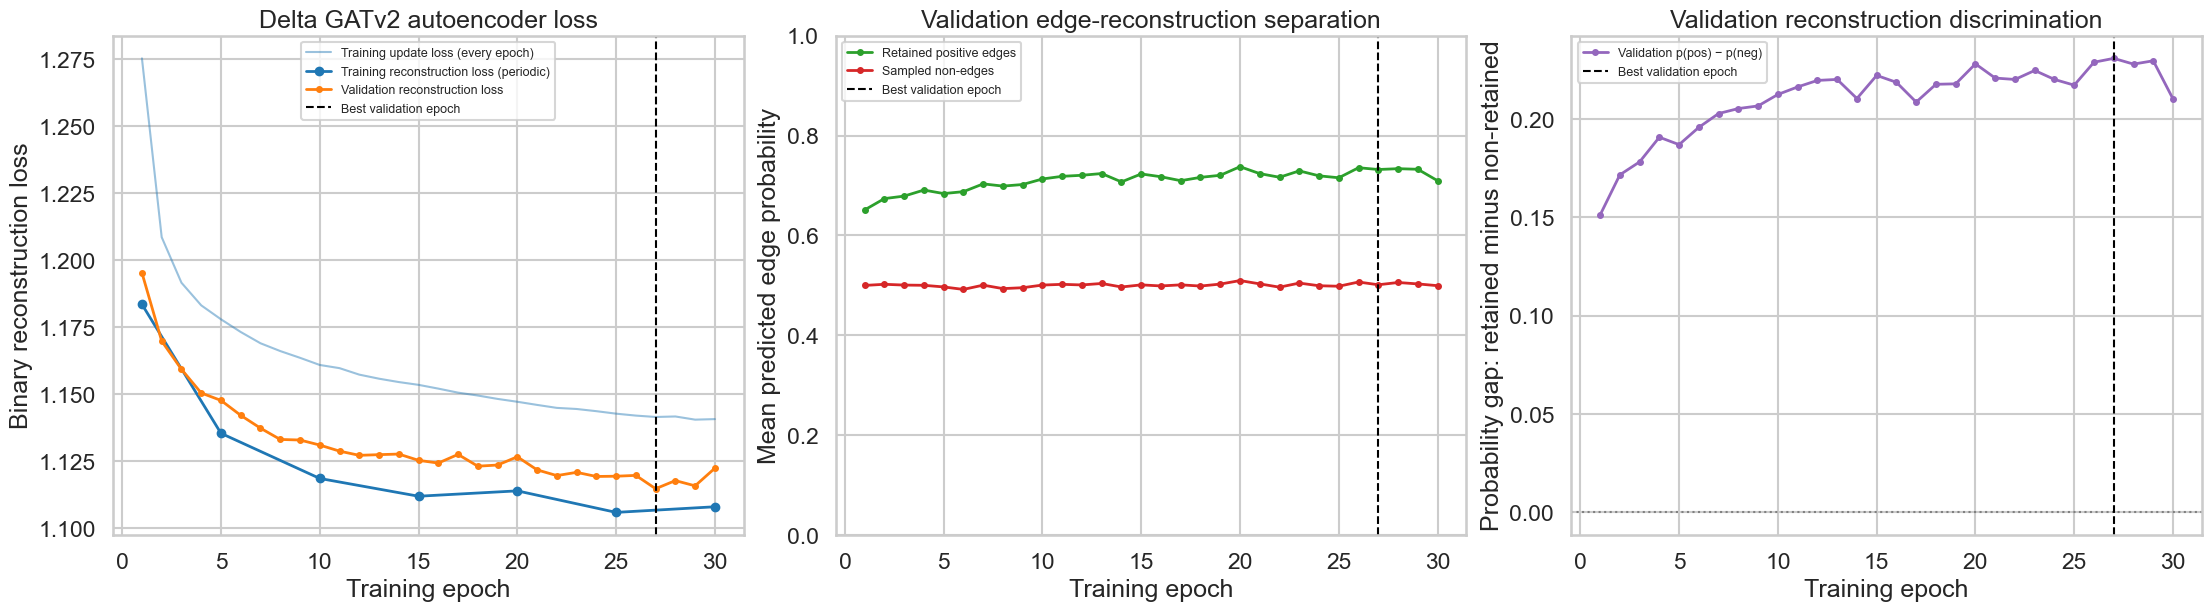


Saved training-history plot:
..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_autoencoder_training_history.png


In [48]:
# ------------------------------------------------------------------
# Cell 13 — plot fast-training history
#
# Important:
#
# `train_update_loss`:
# Available at every epoch because it is collected during training.
#
# `train_reconstruction_loss`:
# Available only at epochs where the entire training set was evaluated:
# epoch 1, then every TRAIN_EVALUATION_INTERVAL epochs.
#
# Missing values (NaN) in full training-evaluation columns are
# intentional. They mean the expensive extra train evaluation was
# skipped to save time.
# ------------------------------------------------------------------

required_history_columns = [
    "epoch",
    "train_update_loss",
    "train_reconstruction_loss",
    "train_positive_probability",
    "train_negative_probability",
    "validation_reconstruction_loss",
    "validation_positive_probability",
    "validation_negative_probability",
]

missing_history_columns = [
    column_name
    for column_name in required_history_columns
    if column_name not in history_df.columns
]

if missing_history_columns:
    raise RuntimeError(
        "history_df does not have the expected fast-training columns.\n"
        f"Missing: {missing_history_columns}\n\n"
        "Make sure you ran the faster Cell 12."
    )


# ------------------------------------------------------------------
# Select only epochs where the full training evaluation was performed.
#
# NaN means evaluation was deliberately skipped.
# ------------------------------------------------------------------

full_train_evaluation_df = history_df.dropna(
    subset=[
        "train_reconstruction_loss",
    ]
).copy()


# ------------------------------------------------------------------
# Print a quick summary of which epochs have full training metrics.
# ------------------------------------------------------------------

print("Total training epochs completed:", len(history_df))

print(
    "Epochs with full training evaluation:",
    full_train_evaluation_df["epoch"].tolist(),
)

print(
    "Best validation epoch:",
    best_epoch,
)

print(
    "Best validation reconstruction loss:",
    f"{best_validation_loss:.4f}",
)


# ------------------------------------------------------------------
# Create a three-panel training summary.
# ------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 6),
    constrained_layout=True,
)


# ------------------------------------------------------------------
# Panel 1 — reconstruction loss.
#
# The light line is training-update loss, which is available every
# epoch but includes dropout and parameter updates.
#
# Training evaluation points are no-gradient reconstruction-loss
# estimates and are directly comparable with validation loss.
# ------------------------------------------------------------------

axes[0].plot(
    history_df["epoch"],
    history_df["train_update_loss"],
    color="tab:blue",
    alpha=0.45,
    linewidth=1.5,
    label="Training update loss (every epoch)",
)

axes[0].plot(
    full_train_evaluation_df["epoch"],
    full_train_evaluation_df[
        "train_reconstruction_loss"
    ],
    color="tab:blue",
    marker="o",
    markersize=6,
    linewidth=2,
    label="Training reconstruction loss (periodic)",
)

axes[0].plot(
    history_df["epoch"],
    history_df[
        "validation_reconstruction_loss"
    ],
    color="tab:orange",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Validation reconstruction loss",
)

axes[0].axvline(
    best_epoch,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Best validation epoch",
)

axes[0].set_title(
    f"{BAND_TO_RUN.capitalize()} GATv2 autoencoder loss"
)

axes[0].set_xlabel("Training epoch")
axes[0].set_ylabel("Binary reconstruction loss")
axes[0].legend(
    fontsize=9,
)


# ------------------------------------------------------------------
# Panel 2 — validation positive/negative edge separation.
#
# A useful trained model should score retained positive edges higher
# than sampled non-retained pairs.
# ------------------------------------------------------------------

axes[1].plot(
    history_df["epoch"],
    history_df[
        "validation_positive_probability"
    ],
    color="tab:green",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Retained positive edges",
)

axes[1].plot(
    history_df["epoch"],
    history_df[
        "validation_negative_probability"
    ],
    color="tab:red",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Sampled non-edges",
)

axes[1].axvline(
    best_epoch,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Best validation epoch",
)

axes[1].set_title(
    "Validation edge-reconstruction separation"
)

axes[1].set_xlabel("Training epoch")
axes[1].set_ylabel("Mean predicted edge probability")
axes[1].set_ylim(0, 1)
axes[1].legend(
    fontsize=9,
)


# ------------------------------------------------------------------
# Panel 3 — probability separation.
#
# This quantity is:
#
# mean p(retained edges) - mean p(sampled non-edges)
#
# A value above zero means the model scores retained edges higher
# than sampled non-retained channel pairs on average.
# ------------------------------------------------------------------

history_df = history_df.copy()

history_df[
    "validation_probability_gap"
] = (
    history_df[
        "validation_positive_probability"
    ]
    - history_df[
        "validation_negative_probability"
    ]
)

axes[2].plot(
    history_df["epoch"],
    history_df[
        "validation_probability_gap"
    ],
    color="tab:purple",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Validation p(pos) − p(neg)",
)

axes[2].axhline(
    0,
    color="gray",
    linestyle=":",
    linewidth=1.5,
)

axes[2].axvline(
    best_epoch,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Best validation epoch",
)

axes[2].set_title(
    "Validation reconstruction discrimination"
)

axes[2].set_xlabel("Training epoch")
axes[2].set_ylabel(
    "Probability gap: retained minus non-retained"
)

axes[2].legend(
    fontsize=9,
)

plt.show()


# ------------------------------------------------------------------
# Save the figure for your report / project output.
# ------------------------------------------------------------------

training_plot_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_autoencoder_training_history.png"
)

fig.savefig(
    training_plot_path,
    dpi=300,
    bbox_inches="tight",
)

print("\nSaved training-history plot:")
print(training_plot_path)

In [49]:
# ------------------------------------------------------------------
# Cell 14 — evaluate the selected GATv2 autoencoder on held-out
# subjects.
#
# Held-out subjects:
# EPCTL01, EPCTL02, EPCTL03
#
# These participants were never used for:
# - fitting coordinate or node-strength scalers
# - updating model parameters
# - validation-loss monitoring
# - early stopping
# - selecting the best training epoch
#
# This is NOT a sleep-stage classification evaluation.
#
# The model task is binary graph-edge reconstruction:
#
# Positive edge:
# A directed edge retained in the epoch-specific top-20% wPLI graph.
#
# Negative edge:
# A sampled within-graph electrode pair that was not retained at the
# 20% threshold for that epoch.
#
# Important scientific language:
# "non-edge" means a below-threshold pair in the sparse graph model.
# It does NOT mean biologically absent connectivity.
# ------------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)


# ------------------------------------------------------------------
# 1. Confirm the required objects exist and have expected contents.
# ------------------------------------------------------------------

required_variables = [
    "model",
    "test_epoch_graphs",
    "test_loader",
    "reconstruction_loss_for_batch",
    "BAND_TO_RUN",
    "RETAINED_DENSITY",
    "BATCH_SIZE",
    "DEVICE",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run the previous Phase B cells first.\n"
        f"Missing variables: {missing_variables}"
    )

if len(test_epoch_graphs) == 0:
    raise RuntimeError(
        "test_epoch_graphs is empty."
    )

if len(test_loader) == 0:
    raise RuntimeError(
        "test_loader is empty."
    )


# ------------------------------------------------------------------
# 2. Re-create a deterministic held-out test DataLoader.
#
# shuffle=False preserves the input order and makes the test run
# reproducible apart from random negative-edge sampling.
# ------------------------------------------------------------------

test_loader = DataLoader(
    test_epoch_graphs,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


# ------------------------------------------------------------------
# 3. Helper for evaluating one graph batch.
#
# This extracts:
# - reconstruction loss
# - decoded probabilities for retained positive edges
# - decoded probabilities for sampled non-edges
# - binary labels and predictions at a 0.50 threshold
#
# It also records graph ID for subject-level summaries.
# ------------------------------------------------------------------

@torch.no_grad()
def collect_test_edge_predictions(
    model,
    graph_list,
    data_loader,
):
    """
    Evaluate edge reconstruction on held-out graphs.

    Parameters
    ----------
    model : GATv2GraphAutoencoder
        The restored best-validation-checkpoint model.

    graph_list : list[Data]
        Held-out PyG graph objects, in the same order used by
        data_loader with shuffle=False.

    data_loader : DataLoader
        Held-out graph batches.

    Returns
    -------
    test_results : dict
        Aggregate reconstruction metrics and arrays.

    per_graph_df : pd.DataFrame
        One row per held-out epoch graph.

    Notes
    -----
    Negative edges are freshly sampled during evaluation. Therefore,
    repeating this cell can cause small changes in reported metrics.
    The result should be interpreted as a sampled reconstruction
    evaluation, not a fixed deterministic benchmark.
    """
    model.eval()

    total_loss = 0.0
    total_graph_count = 0

    all_binary_targets = []
    all_predicted_probabilities = []
    all_binary_predictions = []

    per_graph_rows = []

    graph_offset = 0

    for batch in data_loader:

        batch = batch.to(DEVICE)

        # ----------------------------------------------------------
        # Encode all nodes in the graph batch.
        # ----------------------------------------------------------

        node_latent, graph_latent = model(
            x=batch.x,
            edge_index=batch.edge_index,
            edge_attr=batch.edge_attr,
            batch_vector=batch.batch,
        )

        # ----------------------------------------------------------
        # Positive edges are all retained directed wPLI edges.
        # ----------------------------------------------------------

        positive_edge_index = batch.edge_index

        # ----------------------------------------------------------
        # Sample an equal number of negative within-graph edges.
        #
        # Passing batch=batch.batch prevents edges between different
        # epoch graphs from appearing as negative examples.
        # ----------------------------------------------------------

        n_positive_edges = positive_edge_index.size(1)

        negative_edge_index = batched_negative_sampling(
            edge_index=positive_edge_index,
            batch=batch.batch,
            num_neg_samples=(n_positive_edges // batch.num_graphs),
            method="sparse",
            force_undirected=False,
        )

        # ----------------------------------------------------------
        # Decode candidate edge scores.
        # ----------------------------------------------------------

        positive_logits = model.decode(
            node_latent=node_latent,
            candidate_edge_index=positive_edge_index,
        )

        negative_logits = model.decode(
            node_latent=node_latent,
            candidate_edge_index=negative_edge_index,
        )

        positive_targets = torch.ones_like(
            positive_logits
        )

        negative_targets = torch.zeros_like(
            negative_logits
        )

        # Calculate the same binary reconstruction objective used
        # during training:
        # loss = positive BCE + negative BCE.
        positive_loss = F.binary_cross_entropy_with_logits(
            positive_logits,
            positive_targets,
        )

        negative_loss = F.binary_cross_entropy_with_logits(
            negative_logits,
            negative_targets,
        )

        batch_loss = positive_loss + negative_loss

        # ----------------------------------------------------------
        # Convert decoder logits into probabilities.
        # ----------------------------------------------------------

        positive_probabilities = torch.sigmoid(
            positive_logits
        )

        negative_probabilities = torch.sigmoid(
            negative_logits
        )

        # ----------------------------------------------------------
        # Aggregate arrays for overall test metrics.
        # ----------------------------------------------------------

        batch_targets = torch.cat(
            [
                torch.ones_like(positive_probabilities),
                torch.zeros_like(negative_probabilities),
            ]
        )

        batch_probabilities = torch.cat(
            [
                positive_probabilities,
                negative_probabilities,
            ]
        )

        batch_predictions = (
            batch_probabilities >= 0.50
        ).long()

        all_binary_targets.extend(
            batch_targets
            .detach()
            .cpu()
            .numpy()
            .astype(int)
            .tolist()
        )

        all_predicted_probabilities.extend(
            batch_probabilities
            .detach()
            .cpu()
            .numpy()
            .astype(float)
            .tolist()
        )

        all_binary_predictions.extend(
            batch_predictions
            .detach()
            .cpu()
            .numpy()
            .astype(int)
            .tolist()
        )

        total_loss += (
            batch_loss.item()
            * batch.num_graphs
        )

        total_graph_count += batch.num_graphs

        # ----------------------------------------------------------
        # Calculate graph-level metrics.
        #
        # Nodes in a PyG batch are grouped by graph. We use the
        # `batch.batch` vector to select the positive and negative
        # edges belonging to each individual graph.
        # ----------------------------------------------------------

        original_graphs_in_batch = graph_list[
            graph_offset:
            graph_offset + batch.num_graphs
        ]

        positive_source_nodes = positive_edge_index[0]
        negative_source_nodes = negative_edge_index[0]

        for local_graph_index, graph in enumerate(
            original_graphs_in_batch
        ):

            # Nodes assigned to this graph have batch value equal to
            # local_graph_index.
            positive_edge_mask = (
                batch.batch[positive_source_nodes]
                == local_graph_index
            )

            negative_edge_mask = (
                batch.batch[negative_source_nodes]
                == local_graph_index
            )

            graph_positive_probabilities = (
                positive_probabilities[
                    positive_edge_mask
                ]
                .detach()
                .cpu()
                .numpy()
            )

            graph_negative_probabilities = (
                negative_probabilities[
                    negative_edge_mask
                ]
                .detach()
                .cpu()
                .numpy()
            )

            # Per-graph probability gap:
            #
            # mean predicted p(retained edge)
            # minus
            # mean predicted p(sampled non-edge)
            #
            # Higher positive values indicate stronger edge
            # reconstruction discrimination.
            graph_probability_gap = (
                graph_positive_probabilities.mean()
                - graph_negative_probabilities.mean()
            )

            # Combine targets/probabilities for AUC and threshold
            # metrics within this graph.
            graph_targets = np.concatenate(
                [
                    np.ones(
                        len(graph_positive_probabilities),
                        dtype=int,
                    ),
                    np.zeros(
                        len(graph_negative_probabilities),
                        dtype=int,
                    ),
                ]
            )

            graph_probabilities = np.concatenate(
                [
                    graph_positive_probabilities,
                    graph_negative_probabilities,
                ]
            )

            graph_predictions = (
                graph_probabilities >= 0.50
            ).astype(int)

            # Both positive and negative examples should exist for
            # every graph. The safeguard prevents rare metric errors.
            if len(np.unique(graph_targets)) == 2:
                graph_auc = roc_auc_score(
                    graph_targets,
                    graph_probabilities,
                )

                graph_balanced_accuracy = (
                    balanced_accuracy_score(
                        graph_targets,
                        graph_predictions,
                    )
                )

            else:
                graph_auc = np.nan
                graph_balanced_accuracy = np.nan

            per_graph_rows.append(
                {
                    "subject_id": graph.subject_id,
                    "band": graph.band,
                    "stage": graph.stage,
                    "stored_epoch_position": (
                        graph.stored_epoch_position
                    ),
                    "original_epoch_index": (
                        graph.original_epoch_index
                    ),
                    "time_minutes": (
                        graph.original_epoch_index
                        * 30.0
                        / 60.0
                    ),
                    "n_positive_directed_edges": int(
                        len(graph_positive_probabilities)
                    ),
                    "n_negative_directed_edges": int(
                        len(graph_negative_probabilities)
                    ),
                    "mean_positive_probability": float(
                        graph_positive_probabilities.mean()
                    ),
                    "mean_negative_probability": float(
                        graph_negative_probabilities.mean()
                    ),
                    "probability_gap": float(
                        graph_probability_gap
                    ),
                    "edge_reconstruction_auc": float(
                        graph_auc
                    ),
                    "threshold_0_50_balanced_accuracy": float(
                        graph_balanced_accuracy
                    ),
                }
            )

        graph_offset += batch.num_graphs

    # ----------------------------------------------------------------
    # Aggregate all edge-level held-out metrics.
    # ----------------------------------------------------------------

    all_binary_targets = np.asarray(
        all_binary_targets,
        dtype=int,
    )

    all_predicted_probabilities = np.asarray(
        all_predicted_probabilities,
        dtype=float,
    )

    all_binary_predictions = np.asarray(
        all_binary_predictions,
        dtype=int,
    )

    aggregate_auc = roc_auc_score(
        all_binary_targets,
        all_predicted_probabilities,
    )

    aggregate_accuracy = accuracy_score(
        all_binary_targets,
        all_binary_predictions,
    )

    aggregate_balanced_accuracy = (
        balanced_accuracy_score(
            all_binary_targets,
            all_binary_predictions,
        )
    )

    test_results = {
        "reconstruction_loss": (
            total_loss / total_graph_count
        ),
        "n_test_graphs": int(total_graph_count),
        "n_test_edge_examples": int(
            len(all_binary_targets)
        ),
        "mean_positive_probability": float(
            all_predicted_probabilities[
                all_binary_targets == 1
            ].mean()
        ),
        "mean_negative_probability": float(
            all_predicted_probabilities[
                all_binary_targets == 0
            ].mean()
        ),
        "probability_gap": float(
            all_predicted_probabilities[
                all_binary_targets == 1
            ].mean()
            - all_predicted_probabilities[
                all_binary_targets == 0
            ].mean()
        ),
        "edge_reconstruction_auc": float(
            aggregate_auc
        ),
        "threshold_0_50_accuracy": float(
            aggregate_accuracy
        ),
        "threshold_0_50_balanced_accuracy": float(
            aggregate_balanced_accuracy
        ),
    }

    per_graph_df = pd.DataFrame(
        per_graph_rows
    )

    return test_results, per_graph_df


# ------------------------------------------------------------------
# 4. Run evaluation.
#
# `model` was restored at the end of Cell 12 to the state from the
# best validation-loss epoch, which was epoch 27 in your first run.
# ------------------------------------------------------------------

test_evaluation_start_time = time.perf_counter()

(
    held_out_test_results,
    held_out_per_graph_df,
) = collect_test_edge_predictions(
    model=model,
    graph_list=test_epoch_graphs,
    data_loader=test_loader,
)

test_evaluation_elapsed_seconds = (
    time.perf_counter()
    - test_evaluation_start_time
)


# ------------------------------------------------------------------
# 5. Print aggregate held-out evaluation.
# ------------------------------------------------------------------

print("=" * 70)
print("PHASE B HELD-OUT SUBJECT EDGE-RECONSTRUCTION RESULTS")
print("=" * 70)

print("Band:", BAND_TO_RUN)
print("Graph density:", RETAINED_DENSITY)
print("Held-out graphs:", held_out_test_results["n_test_graphs"])

print(
    "Held-out edge examples:",
    f"{held_out_test_results['n_test_edge_examples']:,}",
)

print(
    "\nHeld-out reconstruction loss:",
    f"{held_out_test_results['reconstruction_loss']:.4f}",
)

print(
    "\nMean predicted probability:"
)

print(
    "Retained positive edges:",
    f"{held_out_test_results['mean_positive_probability']:.3f}",
)

print(
    "Sampled non-edges:",
    f"{held_out_test_results['mean_negative_probability']:.3f}",
)

print(
    "Probability gap:",
    f"{held_out_test_results['probability_gap']:.3f}",
)

print(
    "\nEdge reconstruction metrics:"
)

print(
    "ROC-AUC:",
    f"{held_out_test_results['edge_reconstruction_auc']:.3f}",
)

print(
    "Accuracy at probability threshold 0.50:",
    f"{held_out_test_results['threshold_0_50_accuracy']:.3f}",
)

print(
    "Balanced accuracy at threshold 0.50:",
    f"{held_out_test_results['threshold_0_50_balanced_accuracy']:.3f}",
)

print(
    "\nEvaluation elapsed time:",
    f"{test_evaluation_elapsed_seconds:.1f} seconds "
    f"({test_evaluation_elapsed_seconds / 60:.2f} minutes)",
)


# ------------------------------------------------------------------
# 6. Subject-level summary.
#
# This is more useful scientifically than treating all hundreds of
# thousands of edge examples as independent observations.
#
# Each subject receives:
# - median graph-level reconstruction AUC
# - median probability gap
# - median threshold-based balanced accuracy
# - number of selected epoch graphs
# ------------------------------------------------------------------

held_out_subject_summary_df = (
    held_out_per_graph_df
    .groupby(
        "subject_id",
        as_index=False,
    )
    .agg(
        n_selected_epoch_graphs=(
            "stored_epoch_position",
            "count",
        ),
        median_probability_gap=(
            "probability_gap",
            "median",
        ),
        mean_probability_gap=(
            "probability_gap",
            "mean",
        ),
        median_edge_reconstruction_auc=(
            "edge_reconstruction_auc",
            "median",
        ),
        mean_edge_reconstruction_auc=(
            "edge_reconstruction_auc",
            "mean",
        ),
        median_threshold_balanced_accuracy=(
            "threshold_0_50_balanced_accuracy",
            "median",
        ),
        mean_threshold_balanced_accuracy=(
            "threshold_0_50_balanced_accuracy",
            "mean",
        ),
    )
)

print("\n" + "=" * 70)
print("HELD-OUT SUBJECT-LEVEL SUMMARY")
print("=" * 70)

display(
    held_out_subject_summary_df
)


# ------------------------------------------------------------------
# 7. Stage-level descriptive summary.
#
# This is not an inferential test. It simply shows whether
# reconstruction quality appears similar across Wake/N1/N2/N3/REM in
# the three held-out subjects.
# ------------------------------------------------------------------

held_out_stage_summary_df = (
    held_out_per_graph_df
    .groupby(
        "stage",
        as_index=False,
    )
    .agg(
        n_epoch_graphs=(
            "stored_epoch_position",
            "count",
        ),
        median_probability_gap=(
            "probability_gap",
            "median",
        ),
        median_edge_reconstruction_auc=(
            "edge_reconstruction_auc",
            "median",
        ),
        median_threshold_balanced_accuracy=(
            "threshold_0_50_balanced_accuracy",
            "median",
        ),
    )
)

# Preserve standard sleep-stage display order.
held_out_stage_summary_df["stage"] = pd.Categorical(
    held_out_stage_summary_df["stage"],
    categories=STAGE_ORDER,
    ordered=True,
)

held_out_stage_summary_df = (
    held_out_stage_summary_df
    .sort_values("stage")
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("HELD-OUT STAGE-LEVEL DESCRIPTIVE SUMMARY")
print("=" * 70)

display(
    held_out_stage_summary_df
)


# ------------------------------------------------------------------
# 8. Save test outputs.
# ------------------------------------------------------------------

test_graph_metrics_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_held_out_test_graph_metrics.csv"
)

test_subject_summary_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_held_out_test_subject_summary.csv"
)

test_stage_summary_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_held_out_test_stage_summary.csv"
)

test_aggregate_metrics_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_held_out_test_aggregate_metrics.json"
)

held_out_per_graph_df.to_csv(
    test_graph_metrics_path,
    index=False,
)

held_out_subject_summary_df.to_csv(
    test_subject_summary_path,
    index=False,
)

held_out_stage_summary_df.to_csv(
    test_stage_summary_path,
    index=False,
)

with open(
    test_aggregate_metrics_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        held_out_test_results,
        f,
        indent=2,
    )

print("\nSaved held-out outputs:")
print("-", test_graph_metrics_path)
print("-", test_subject_summary_path)
print("-", test_stage_summary_path)
print("-", test_aggregate_metrics_path)


# ------------------------------------------------------------------
# 9. Preserve short, clear aliases for later cells.
# ------------------------------------------------------------------

test_results = held_out_test_results
test_per_graph_df = held_out_per_graph_df
test_subject_summary_df = held_out_subject_summary_df
test_stage_summary_df = held_out_stage_summary_df

print("\nCell 14 completed successfully.")
print("Available objects:")
print("- test_results")
print("- test_per_graph_df")
print("- test_subject_summary_df")
print("- test_stage_summary_df")

PHASE B HELD-OUT SUBJECT EDGE-RECONSTRUCTION RESULTS
Band: delta
Graph density: 0.2
Held-out graphs: 743
Held-out edge examples: 2,023,932

Held-out reconstruction loss: 1.1013

Mean predicted probability:
Retained positive edges: 0.746
Sampled non-edges: 0.497
Probability gap: 0.250

Edge reconstruction metrics:
ROC-AUC: 0.845
Accuracy at probability threshold 0.50: 0.727
Balanced accuracy at threshold 0.50: 0.727

Evaluation elapsed time: 15.9 seconds (0.26 minutes)

HELD-OUT SUBJECT-LEVEL SUMMARY


,subject_id,n_selected_epoch_graphs,median_probability_gap,mean_probability_gap,median_edge_reconstruction_auc,mean_edge_reconstruction_auc,median_threshold_balanced_accuracy,mean_threshold_balanced_accuracy
0,EPCTL01,274,0.254374,0.261272,0.859786,0.857902,0.729626,0.729549
1,EPCTL02,244,0.243922,0.242198,0.855964,0.854819,0.723752,0.722708
2,EPCTL03,225,0.242398,0.243823,0.857157,0.852626,0.730543,0.728900



HELD-OUT STAGE-LEVEL DESCRIPTIVE SUMMARY


,stage,n_epoch_graphs,median_probability_gap,median_edge_reconstruction_auc,median_threshold_balanced_accuracy
0,Wake,98,0.201095,0.834722,0.708700
1,N1,155,0.214036,0.848469,0.722100
2,N2,297,0.279408,0.869994,0.738620
3,N3,103,0.254120,0.864023,0.732746
4,REM,90,0.225497,0.842864,0.723201



Saved held-out outputs:
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_held_out_test_graph_metrics.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_held_out_test_subject_summary.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_held_out_test_stage_summary.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_held_out_test_aggregate_metrics.json

Cell 14 completed successfully.
Available objects:
- test_results
- test_per_graph_df
- test_subject_summary_df
- test_stage_summary_df


In [50]:
# ------------------------------------------------------------------
# Cell 14B — audit negative sampling using the SAME rule as the
# corrected Cell 14 evaluation.
#
# Expected for a four-graph batch at 20% density:
#
# Positive directed edges:
# 4 graphs × 1,362 = 5,448
#
# Negative directed edges:
# 4 graphs × 1,362 = 5,448
#
# Ratio:
# approximately 1.0
# ------------------------------------------------------------------

audit_batch = next(
    iter(test_loader)
).to(DEVICE)

audit_positive_edge_index = audit_batch.edge_index

# Number of positive directed edges in the whole batch.
n_positive_edges_in_batch = (
    audit_positive_edge_index.size(1)
)

# In your installed PyG version, batched_negative_sampling interprets
# num_neg_samples per graph. Therefore request the number corresponding
# to ONE graph, not the whole batch.
n_negative_edges_per_graph = (
    n_positive_edges_in_batch
    // audit_batch.num_graphs
)

audit_negative_edge_index = batched_negative_sampling(
    edge_index=audit_positive_edge_index,
    batch=audit_batch.batch,
    num_neg_samples=n_negative_edges_per_graph,
    method="sparse",
    force_undirected=False,
)

print("Graphs in test batch:", audit_batch.num_graphs)

print(
    "Positive directed edges:",
    n_positive_edges_in_batch,
)

print(
    "Requested negative directed edges per graph:",
    n_negative_edges_per_graph,
)

print(
    "Sampled negative directed edges:",
    audit_negative_edge_index.size(1),
)

print(
    "Negative/positive ratio:",
    audit_negative_edge_index.size(1)
    / n_positive_edges_in_batch,
)

assert audit_negative_edge_index.size(1) == (
    n_positive_edges_in_batch
), (
    "Expected one sampled negative edge per positive directed edge."
)

print("\nNegative-sampling audit passed: 1:1 balance confirmed.")

Graphs in test batch: 4
Positive directed edges: 5448
Requested negative directed edges per graph: 1362
Sampled negative directed edges: 5448
Negative/positive ratio: 1.0

Negative-sampling audit passed: 1:1 balance confirmed.


In [ ]:
# ------------------------------------------------------------------
# Cell 14A — build all eligible 30-second graphs for frozen-encoder
# deployment
#
# Purpose:
# Create a SECOND graph list containing one sparse graph for EVERY
# stored 30-second epoch in the HDF5 files, using exactly the same:
#
# - already signal-downsampled input data;
# - band-specific wPLI matrices;
# - graph density / sparsification rule;
# - 83-channel coordinate alignment;
# - training-fitted coordinate and strength scalers;
# - train / validation / test participant split.
#
# This does NOT retrain the GAT. It creates inputs for deployment of
# the already frozen encoder across every eligible epoch.
#
# Keep the original `all_epoch_graphs` unchanged: despite its name,
# it is your original transition-aware selected graph list.
# ------------------------------------------------------------------

import time
from collections import Counter

import h5py
import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------------
# 1. Verify prerequisites from earlier graph-building / scaling cells.
# ------------------------------------------------------------------

required_variables = [
    "epoch_h5_paths",
    "BAND_TO_RUN",
    "N_NODES",
    "STAGE_ORDER",
    "RETAINED_DENSITY",
    "position_by_normalized_channel",
    "positions_for_h5_channel_order",
    "make_epoch_pyg_graph",
    "assign_scaled_node_features",
    "coordinate_scaler",
    "strength_scaler",
    "TRAIN_SUBJECTS",
    "VALIDATION_SUBJECTS",
    "TEST_SUBJECTS",
    "decode_value",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run the earlier graph-construction and feature-scaling "
        "cells before Cell 14A.\n"
        f"Missing variables: {missing_variables}"
    )

if len(epoch_h5_paths) == 0:
    raise RuntimeError(
        "epoch_h5_paths is empty."
    )

train_subject_set = set(TRAIN_SUBJECTS)
validation_subject_set = set(VALIDATION_SUBJECTS)
test_subject_set = set(TEST_SUBJECTS)

if train_subject_set & validation_subject_set:
    raise ValueError(
        "A participant is in both training and validation sets."
    )

if train_subject_set & test_subject_set:
    raise ValueError(
        "A participant is in both training and test sets."
    )

if validation_subject_set & test_subject_set:
    raise ValueError(
        "A participant is in both validation and test sets."
    )


# ------------------------------------------------------------------
# 2. Helper: obtain the HDF5 channel-name dataset.
#
# The original notebook supports potentially different HDF5 naming
# variants. We retain that flexibility here.
# ------------------------------------------------------------------

def get_channel_dataset_name(h5_file):
    """
    Return the HDF5 dataset key that contains channel labels.
    """

    candidate_names = [
        "channel_names",
        "channelnames",
    ]

    for candidate_name in candidate_names:
        if candidate_name in h5_file:
            return candidate_name

    raise KeyError(
        "No channel-name dataset found. Expected one of: "
        f"{candidate_names}. Available keys: {list(h5_file.keys())}"
    )


# ------------------------------------------------------------------
# 3. Helper: make split labels reproducible in the all-epoch table.
# ------------------------------------------------------------------

def subject_split_label(subject_id):
    """
    Return train / validation / test for a known participant.
    """

    if subject_id in train_subject_set:
        return "train"

    if subject_id in validation_subject_set:
        return "validation"

    if subject_id in test_subject_set:
        return "test"

    raise ValueError(
        f"Subject {subject_id!r} is not assigned to any split."
    )


# ------------------------------------------------------------------
# 4. Build every valid 30-second graph.
#
# Key change from the original graph-build cell:
#
# OLD:
# for stored_epoch_position in selected_positions:
#
# NEW:
# for stored_epoch_position in range(n_epochs):
#
# Each graph uses the same make_epoch_pyg_graph function and then
# receives node features through the SAME training-fitted scalers.
# ------------------------------------------------------------------

all_eligible_epoch_graphs = []
all_eligible_summary_rows = []

build_start_time = time.perf_counter()

for file_number, h5_path in enumerate(
    epoch_h5_paths,
    start=1,
):

    with h5py.File(h5_path, "r") as h5_file:

        subject_id = decode_value(
            h5_file.attrs.get(
                "subject_id",
                h5_path.stem,
            )
        )

        if BAND_TO_RUN not in h5_file:
            raise KeyError(
                f"{h5_path.name} does not contain band "
                f"{BAND_TO_RUN!r}."
            )

        if "stage" not in h5_file:
            raise KeyError(
                f"{h5_path.name} has no 'stage' dataset."
            )

        if "epoch_idx" not in h5_file:
            raise KeyError(
                f"{h5_path.name} has no 'epoch_idx' dataset."
            )

        channel_dataset_name = get_channel_dataset_name(
            h5_file
        )

        current_channel_names = [
            decode_value(channel_name)
            for channel_name in h5_file[
                channel_dataset_name
            ][:]
        ]

        if len(current_channel_names) != N_NODES:
            raise ValueError(
                f"{subject_id}: found "
                f"{len(current_channel_names)} channels; "
                f"expected {N_NODES}."
            )

        subject_positions_m = positions_for_h5_channel_order(
            current_channel_names=current_channel_names,
            position_lookup=position_by_normalized_channel,
        )

        stage_labels = np.asarray(
            [
                decode_value(stage_value)
                for stage_value in h5_file["stage"][:]
            ],
            dtype=str,
        )

        original_epoch_indices = np.asarray(
            h5_file["epoch_idx"][:],
            dtype=np.int64,
        )

        wpli_dataset = h5_file[BAND_TO_RUN]

        if wpli_dataset.ndim != 3:
            raise ValueError(
                f"{subject_id}: expected a 3D wPLI dataset for "
                f"{BAND_TO_RUN!r}, got shape "
                f"{wpli_dataset.shape}."
            )

        n_epochs = int(wpli_dataset.shape[0])

        if len(stage_labels) != n_epochs:
            raise ValueError(
                f"{subject_id}: stage-label count "
                f"({len(stage_labels)}) does not match graph "
                f"count ({n_epochs})."
            )

        if len(original_epoch_indices) != n_epochs:
            raise ValueError(
                f"{subject_id}: epoch_idx count "
                f"({len(original_epoch_indices)}) does not match "
                f"graph count ({n_epochs})."
            )

        subject_graph_count_before = len(
            all_eligible_epoch_graphs
        )

        invalid_epoch_records = []

        for stored_epoch_position in range(n_epochs):

            adjacency_matrix = np.asarray(
                wpli_dataset[stored_epoch_position],
                dtype=np.float32,
            )

            # The helper validates the matrix and applies the same
            # 20% proportional thresholding used in the model.
            #
            # If an epoch cannot produce a valid graph, it is not
            # included. This is valid: Cell 16 will avoid treating
            # epochs across a resulting time gap as adjacent.
            try:
                graph = make_epoch_pyg_graph(
                    adjacency_matrix=adjacency_matrix,
                    channel_names_for_graph=current_channel_names,
                    physical_positions_m=subject_positions_m,
                    subject_id=subject_id,
                    stored_epoch_position=stored_epoch_position,
                    original_epoch_index=int(
                        original_epoch_indices[
                            stored_epoch_position
                        ]
                    ),
                    stage_label=stage_labels[
                        stored_epoch_position
                    ],
                    band_name=BAND_TO_RUN,
                )

                # Critical:
                # Reuse scalers that were fitted previously only on
                # the original training-participant graph set.
                assign_scaled_node_features(
                    graph=graph,
                    coordinate_scaler=coordinate_scaler,
                    strength_scaler=strength_scaler,
                )

                # Add an explicit split attribute for Cell 15.
                graph.split = subject_split_label(
                    subject_id
                )

                # Add a direct all-epoch time mapping.
                # One stored/scored epoch is 30 seconds = 0.5 min.
                graph.time_minutes = (
                    0.5 * stored_epoch_position
                )

                # Validate the ready-to-encode graph.
                if graph.x.shape != (N_NODES, 4):
                    raise ValueError(
                        "Unexpected graph.x shape: "
                        f"{tuple(graph.x.shape)}"
                    )

                if not torch.isfinite(graph.x).all():
                    raise ValueError(
                        "graph.x contains NaN or infinite values."
                    )

                if graph.edge_index.shape[0] != 2:
                    raise ValueError(
                        "graph.edge_index must have shape "
                        "(2, n_edges)."
                    )

                if graph.edge_attr.ndim != 2:
                    raise ValueError(
                        "graph.edge_attr must have shape "
                        "(n_edges, 1)."
                    )

                all_eligible_epoch_graphs.append(graph)

            except Exception as exception:

                invalid_epoch_records.append(
                    {
                        "stored_epoch_position": int(
                            stored_epoch_position
                        ),
                        "original_epoch_index": int(
                            original_epoch_indices[
                                stored_epoch_position
                            ]
                        ),
                        "stage": str(
                            stage_labels[
                                stored_epoch_position
                            ]
                        ),
                        "error_type": type(
                            exception
                        ).__name__,
                        "error_message": str(exception),
                    }
                )

        subject_graph_count = (
            len(all_eligible_epoch_graphs)
            - subject_graph_count_before
        )

        all_eligible_summary_rows.append(
            {
                "subject_id": subject_id,
                "split": subject_split_label(subject_id),
                "n_stored_epochs": n_epochs,
                "n_all_eligible_graphs": subject_graph_count,
                "n_excluded_epochs": len(
                    invalid_epoch_records
                ),
                "all_eligible_stage_counts": dict(
                    Counter(
                        graph.stage
                        for graph in all_eligible_epoch_graphs[
                            subject_graph_count_before:
                        ]
                    )
                ),
            }
        )

        print(
            f"{file_number:02d}/{len(epoch_h5_paths):02d} "
            f"{subject_id}: "
            f"{n_epochs} stored epochs -> "
            f"{subject_graph_count} eligible graphs; "
            f"{len(invalid_epoch_records)} excluded."
        )

        # Store detailed invalid-epoch diagnostics on the summary row.
        if invalid_epoch_records:
            all_eligible_summary_rows[-1][
                "excluded_epoch_details"
            ] = invalid_epoch_records
        else:
            all_eligible_summary_rows[-1][
                "excluded_epoch_details"
            ] = []


all_eligible_summary_df = pd.DataFrame(
    all_eligible_summary_rows
)

build_elapsed_minutes = (
    time.perf_counter() - build_start_time
) / 60.0

if len(all_eligible_epoch_graphs) == 0:
    raise RuntimeError(
        "No all-eligible graphs were created."
    )


# ------------------------------------------------------------------
# 5. Validate all-eligible graph collection.
# ------------------------------------------------------------------

all_eligible_subject_ids = sorted(
    {
        graph.subject_id
        for graph in all_eligible_epoch_graphs
    }
)

expected_subject_ids = sorted(
    train_subject_set
    | validation_subject_set
    | test_subject_set
)

if all_eligible_subject_ids != expected_subject_ids:
    missing_subject_ids = sorted(
        set(expected_subject_ids)
        - set(all_eligible_subject_ids)
    )

    unexpected_subject_ids = sorted(
        set(all_eligible_subject_ids)
        - set(expected_subject_ids)
    )

    raise ValueError(
        "All-eligible graph dataset subject mismatch.\n"
        f"Missing: {missing_subject_ids}\n"
        f"Unexpected: {unexpected_subject_ids}"
    )

for graph_number, graph in enumerate(
    all_eligible_epoch_graphs
):

    if graph.band != BAND_TO_RUN:
        raise ValueError(
            f"Graph {graph_number} has wrong band: "
            f"{graph.band!r}."
        )

    if not hasattr(graph, "split"):
        raise ValueError(
            f"Graph {graph_number} is missing `.split`."
        )

    if not hasattr(graph, "time_minutes"):
        raise ValueError(
            f"Graph {graph_number} is missing `.time_minutes`."
        )

    if graph.x.shape != (N_NODES, 4):
        raise ValueError(
            f"Graph {graph_number} has invalid x shape: "
            f"{tuple(graph.x.shape)}."
        )


# ------------------------------------------------------------------
# 6. Summary and coverage checks.
# ------------------------------------------------------------------

print("\n" + "=" * 70)
print("ALL-ELIGIBLE GRAPH DATASET SUMMARY")
print("=" * 70)

print("Band:", BAND_TO_RUN)

print(
    "All-eligible epoch graphs:",
    len(all_eligible_epoch_graphs),
)

print(
    "Elapsed build time:",
    f"{build_elapsed_minutes:.2f} minutes",
)

print("\nGraphs by model split:")

all_eligible_split_counts = pd.Series(
    [
        graph.split
        for graph in all_eligible_epoch_graphs
    ]
).value_counts()

print(all_eligible_split_counts)

print("\nGraphs by sleep stage:")

all_eligible_stage_counts = (
    pd.Series(
        [
            graph.stage
            for graph in all_eligible_epoch_graphs
        ]
    )
    .value_counts()
    .reindex(STAGE_ORDER, fill_value=0)
)

print(all_eligible_stage_counts)

print("\nPer-subject all-eligible graph coverage:")
display(
    all_eligible_summary_df[
        [
            "subject_id",
            "split",
            "n_stored_epochs",
            "n_all_eligible_graphs",
            "n_excluded_epochs",
            "all_eligible_stage_counts",
        ]
    ]
)

print("\nExample all-eligible graph:")
print(all_eligible_epoch_graphs[0])

print("\nExample metadata:")
print(
    "Subject:",
    all_eligible_epoch_graphs[0].subject_id,
)
print(
    "Split:",
    all_eligible_epoch_graphs[0].split,
)
print(
    "Band:",
    all_eligible_epoch_graphs[0].band,
)
print(
    "Stage:",
    all_eligible_epoch_graphs[0].stage,
)
print(
    "Stored epoch position:",
    all_eligible_epoch_graphs[
        0
    ].stored_epoch_position,
)
print(
    "Original epoch index:",
    all_eligible_epoch_graphs[
        0
    ].original_epoch_index,
)
print(
    "Time in minutes:",
    all_eligible_epoch_graphs[
        0
    ].time_minutes,
)


# ------------------------------------------------------------------
# 7. Save coverage diagnostics.
# ------------------------------------------------------------------

all_eligible_coverage_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"all_eligible_epochs_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_graph_coverage_summary.csv"
)

all_eligible_summary_df.to_csv(
    all_eligible_coverage_path,
    index=False,
)

print("\nSaved all-eligible graph coverage summary:")
print("-", all_eligible_coverage_path)

print("\nAvailable objects:")
print("- all_eligible_epoch_graphs")
print("- all_eligible_summary_df")

01/28 EPCTL01: 952 stored epochs -> 952 eligible graphs; 0 excluded.
02/28 EPCTL02: 1017 stored epochs -> 1017 eligible graphs; 0 excluded.
03/28 EPCTL03: 761 stored epochs -> 761 eligible graphs; 0 excluded.
04/28 EPCTL04: 735 stored epochs -> 735 eligible graphs; 0 excluded.
05/28 EPCTL05: 729 stored epochs -> 729 eligible graphs; 0 excluded.
06/28 EPCTL06: 822 stored epochs -> 822 eligible graphs; 0 excluded.
07/28 EPCTL07: 891 stored epochs -> 891 eligible graphs; 0 excluded.
08/28 EPCTL09: 910 stored epochs -> 910 eligible graphs; 0 excluded.
09/28 EPCTL10: 881 stored epochs -> 881 eligible graphs; 0 excluded.
10/28 EPCTL11: 774 stored epochs -> 774 eligible graphs; 0 excluded.
11/28 EPCTL12: 748 stored epochs -> 748 eligible graphs; 0 excluded.
12/28 EPCTL13: 829 stored epochs -> 829 eligible graphs; 0 excluded.
13/28 EPCTL14: 728 stored epochs -> 728 eligible graphs; 0 excluded.
14/28 EPCTL15: 730 stored epochs -> 730 eligible graphs; 0 excluded.
15/28 EPCTL16: 820 stored epochs

,subject_id,split,n_stored_epochs,n_all_eligible_graphs,n_excluded_epochs,all_eligible_stage_counts
0,EPCTL01,test,952,952,0,"{'Wake': 46, 'N1': 74, 'N2': 471, 'N3': 185, '..."
1,EPCTL02,test,1017,1017,0,"{'Wake': 195, 'N1': 84, 'N2': 492, 'N3': 176, ..."
2,EPCTL03,test,761,761,0,"{'Wake': 56, 'N1': 66, 'N2': 305, 'N3': 207, '..."
3,EPCTL04,validation,735,735,0,"{'Wake': 228, 'N1': 95, 'N2': 214, 'N3': 124, ..."
4,EPCTL05,validation,729,729,0,"{'Wake': 47, 'N1': 71, 'N2': 309, 'N3': 170, '..."
5,EPCTL06,validation,822,822,0,"{'N1': 70, 'N2': 355, 'N3': 154, 'Wake': 109, ..."
6,EPCTL07,train,891,891,0,"{'Wake': 113, 'N1': 96, 'N2': 397, 'N3': 181, ..."
7,EPCTL09,train,910,910,0,"{'Wake': 159, 'N1': 97, 'N2': 414, 'N3': 103, ..."
8,EPCTL10,train,881,881,0,"{'Wake': 251, 'N1': 101, 'N2': 271, 'N3': 215,..."
9,EPCTL11,train,774,774,0,"{'Wake': 135, 'N1': 51, 'N2': 298, 'N3': 216, ..."



Example all-eligible graph:
Data(x=[83, 4], edge_index=[2, 1362], edge_attr=[1362, 1], subject_id='EPCTL01', band='delta', stage='Wake', stored_epoch_position=0, original_epoch_index=0, channel_names=[83], physical_positions_m=[83, 3], raw_weighted_strength=[83, 1], split='test', time_minutes=0.0)

Example metadata:
Subject: EPCTL01
Split: test
Band: delta
Stage: Wake
Stored epoch position: 0
Original epoch index: 0
Time in minutes: 0.0

Saved all-eligible graph coverage summary:
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_all_eligible_epochs_density_20_graph_coverage_summary.csv

Available objects:
- all_eligible_epoch_graphs
- all_eligible_summary_df


In [54]:
# ------------------------------------------------------------------
# Cell 15 — extract graph-summary embeddings for all eligible epochs
#
# Input:
# - The selected GATv2 autoencoder model from Cell 12.
# - all_eligible_epoch_graphs, created after model selection.
#
# Important:
# - The model is set to evaluation mode.
# - No gradients are calculated.
# - No parameters are updated.
# - This cell does NOT retrain, tune, or rescale the model.
# - EEG signal downsampling and epoch-level wPLI estimation happened
#   earlier; this cell only embeds existing graph objects.
#
# For every eligible 30-second graph:
#
# 83 nodes × 4 input features
# → GATv2 encoder
# → 83 nodes × 8 latent values
# → global mean pooling
# → one graph-summary embedding with 8 values
#
# Output:
# One DataFrame row per eligible epoch graph:
#
# subject_id
# split
# band
# stage
# stored_epoch_position
# original_epoch_index
# time_minutes
# embedding_1 ... embedding_8
#
# The 8 embedding coordinates are used jointly for temporal distances.
# Do not interpret an individual coordinate biologically by itself.
# ------------------------------------------------------------------

import time

import numpy as np
import pandas as pd
import torch

from torch_geometric.loader import DataLoader


# ------------------------------------------------------------------
# 1. Identify the trained model and validate prerequisites.
# ------------------------------------------------------------------

if "gatv2_autoencoder_model" in globals():
    embedding_model = gatv2_autoencoder_model

elif "model" in globals():
    embedding_model = model

else:
    raise RuntimeError(
        "No trained GATv2 autoencoder model was found.\n"
        "Run Cell 12 before running Cell 15."
    )

required_variables = [
    "all_eligible_epoch_graphs",
    "TRAIN_SUBJECTS",
    "VALIDATION_SUBJECTS",
    "TEST_SUBJECTS",
    "BAND_TO_RUN",
    "BATCH_SIZE",
    "GRAPH_EMBEDDING_DIM",
    "PHASE_B_OUTPUT_DIR",
    "DEVICE",
    "STAGE_ORDER",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run the original training cells and the all-eligible "
        "deployment graph-building cell before Cell 15.\n"
        f"Missing variables: {missing_variables}"
    )

if len(all_eligible_epoch_graphs) == 0:
    raise RuntimeError(
        "all_eligible_epoch_graphs is empty."
    )

if GRAPH_EMBEDDING_DIM < 1:
    raise ValueError(
        "GRAPH_EMBEDDING_DIM must be at least 1."
    )

embedding_model = embedding_model.to(DEVICE)
embedding_model.eval()


# ------------------------------------------------------------------
# 2. Validate participant splits and define split lookup.
#
# These labels are metadata only; they do not affect embeddings.
# ------------------------------------------------------------------

train_subject_set = set(TRAIN_SUBJECTS)
validation_subject_set = set(VALIDATION_SUBJECTS)
test_subject_set = set(TEST_SUBJECTS)

if train_subject_set & validation_subject_set:
    raise RuntimeError(
        "Training and validation subject sets overlap."
    )

if train_subject_set & test_subject_set:
    raise RuntimeError(
        "Training and test subject sets overlap."
    )

if validation_subject_set & test_subject_set:
    raise RuntimeError(
        "Validation and test subject sets overlap."
    )


def subject_split_name(subject_id):
    """Return a participant's original subject-disjoint split."""

    if subject_id in train_subject_set:
        return "train"

    if subject_id in validation_subject_set:
        return "validation"

    if subject_id in test_subject_set:
        return "test"

    raise ValueError(
        f"Subject {subject_id!r} is not assigned to a split."
    )


# ------------------------------------------------------------------
# 3. Validate graph metadata before embedding.
#
# The graph builder must have used the original attribute names below.
# `split` and `time_minutes` are optional graph attributes because this
# cell can reconstruct both safely from subject ID and epoch index.
# ------------------------------------------------------------------

required_graph_attributes = [
    "subject_id",
    "band",
    "stage",
    "stored_epoch_position",
    "original_epoch_index",
    "x",
    "edge_index",
    "edge_attr",
]

for graph_number, graph in enumerate(all_eligible_epoch_graphs):

    missing_graph_attributes = [
        attribute_name
        for attribute_name in required_graph_attributes
        if not hasattr(graph, attribute_name)
    ]

    if missing_graph_attributes:
        raise AttributeError(
            f"Graph {graph_number} is missing required attributes: "
            f"{missing_graph_attributes}"
        )

    if graph.band != BAND_TO_RUN:
        raise ValueError(
            f"Graph {graph_number} has band={graph.band!r}; "
            f"expected BAND_TO_RUN={BAND_TO_RUN!r}."
        )

    if graph.x.ndim != 2:
        raise ValueError(
            f"Graph {graph_number} has invalid x shape: "
            f"{tuple(graph.x.shape)}."
        )

    if not torch.isfinite(graph.x).all():
        raise ValueError(
            f"Graph {graph_number} has NaN or infinite node features."
        )


# ------------------------------------------------------------------
# 4. Build deterministic DataLoader.
#
# `shuffle=False` is required because each output graph embedding must
# be paired with the metadata from the same source graph.
# ------------------------------------------------------------------

embedding_loader = DataLoader(
    all_eligible_epoch_graphs,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


# ------------------------------------------------------------------
# 5. Extract graph-summary embeddings.
#
# The model forward method returns:
#
# node_latent:  (total_nodes_in_batch, GRAPH_EMBEDDING_DIM)
# graph_latent: (number_of_graphs_in_batch, GRAPH_EMBEDDING_DIM)
#
# Save graph_latent: one 8D embedding per full epoch graph.
# ------------------------------------------------------------------

embedding_rows = []

graph_offset = 0
embedding_start_time = time.perf_counter()

with torch.no_grad():

    for batch_number, batch in enumerate(
        embedding_loader,
        start=1,
    ):

        batch = batch.to(DEVICE)

        node_latent, graph_latent = embedding_model(
            x=batch.x,
            edge_index=batch.edge_index,
            edge_attr=batch.edge_attr,
            batch_vector=batch.batch,
        )

        graph_latent_np = (
            graph_latent
            .detach()
            .cpu()
            .numpy()
        )

        batch_graph_count = int(batch.num_graphs)

        source_graphs = all_eligible_epoch_graphs[
            graph_offset:
            graph_offset + batch_graph_count
        ]

        if len(source_graphs) != batch_graph_count:
            raise RuntimeError(
                "Graph metadata and DataLoader output are misaligned."
            )

        if graph_latent_np.shape != (
            batch_graph_count,
            GRAPH_EMBEDDING_DIM,
        ):
            raise ValueError(
                "Unexpected batched graph-embedding shape: "
                f"{graph_latent_np.shape}; expected "
                f"({batch_graph_count}, {GRAPH_EMBEDDING_DIM})."
            )

        for graph, graph_embedding in zip(
            source_graphs,
            graph_latent_np,
        ):

            if not np.all(np.isfinite(graph_embedding)):
                raise ValueError(
                    "A non-finite graph embedding was produced for "
                    f"subject={graph.subject_id!r}, "
                    f"epoch={graph.original_epoch_index!r}."
                )

            original_epoch_index = int(
                graph.original_epoch_index
            )

            row = {
                "subject_id": graph.subject_id,
                "split": subject_split_name(
                    graph.subject_id
                ),
                "band": graph.band,
                "stage": graph.stage,
                "stored_epoch_position": int(
                    graph.stored_epoch_position
                ),
                "original_epoch_index": original_epoch_index,
                "time_minutes": float(
                    original_epoch_index * 30.0 / 60.0
                ),
            }

            for embedding_number, embedding_value in enumerate(
                graph_embedding,
                start=1,
            ):
                row[
                    f"embedding_{embedding_number}"
                ] = float(embedding_value)

            embedding_rows.append(row)

        graph_offset += batch_graph_count

        if (
            batch_number == 1
            or batch_number % 500 == 0
            or graph_offset == len(all_eligible_epoch_graphs)
        ):
            print(
                f"Processed {graph_offset:,} / "
                f"{len(all_eligible_epoch_graphs):,} "
                "eligible epoch graphs"
            )


# ------------------------------------------------------------------
# 6. Build and validate the embedding table.
# ------------------------------------------------------------------

embeddings_df = pd.DataFrame(
    embedding_rows
)

embedding_columns = [
    f"embedding_{embedding_number}"
    for embedding_number in range(
        1,
        GRAPH_EMBEDDING_DIM + 1,
    )
]

expected_columns = [
    "subject_id",
    "split",
    "band",
    "stage",
    "stored_epoch_position",
    "original_epoch_index",
    "time_minutes",
] + embedding_columns

missing_columns = [
    column_name
    for column_name in expected_columns
    if column_name not in embeddings_df.columns
]

if missing_columns:
    raise RuntimeError(
        "Embedding table is missing expected columns:\n"
        f"{missing_columns}"
    )

if len(embeddings_df) != len(all_eligible_epoch_graphs):
    raise RuntimeError(
        f"Expected {len(all_eligible_epoch_graphs):,} embedding rows, "
        f"but created {len(embeddings_df):,}."
    )

if not np.all(
    np.isfinite(
        embeddings_df[
            embedding_columns
        ].to_numpy(
            dtype=float
        )
    )
):
    raise ValueError(
        "Embedding table contains NaN or infinite values."
    )

if not (
    embeddings_df["band"] == BAND_TO_RUN
).all():
    raise ValueError(
        "The embedding table contains an unexpected frequency band."
    )

duplicate_rows_df = embeddings_df[
    embeddings_df.duplicated(
        subset=[
            "subject_id",
            "original_epoch_index",
        ],
        keep=False,
    )
].sort_values(
    [
        "subject_id",
        "original_epoch_index",
    ]
)

if len(duplicate_rows_df) > 0:
    display(
        duplicate_rows_df.head(20)
    )

    raise ValueError(
        "Duplicate embedding rows were found for one or more "
        "(subject_id, original_epoch_index) combinations."
    )


# ------------------------------------------------------------------
# 7. Sort by original recording time and add temporal diagnostics.
#
# Cell 16 will independently rebuild pairs and enforce:
#
# original_epoch_gap == 1
# time_gap_minutes == 0.5
#
# before treating two embeddings as true adjacent 30-second epochs.
# ------------------------------------------------------------------

embeddings_df = (
    embeddings_df
    .sort_values(
        [
            "subject_id",
            "original_epoch_index",
            "time_minutes",
        ]
    )
    .reset_index(drop=True)
)

embeddings_df["previous_stage"] = (
    embeddings_df
    .groupby("subject_id")["stage"]
    .shift(1)
)

embeddings_df["previous_original_epoch_index"] = (
    embeddings_df
    .groupby("subject_id")[
        "original_epoch_index"
    ]
    .shift(1)
)

embeddings_df["previous_time_minutes"] = (
    embeddings_df
    .groupby("subject_id")[
        "time_minutes"
    ]
    .shift(1)
)

embeddings_df["original_epoch_gap"] = (
    embeddings_df["original_epoch_index"]
    - embeddings_df[
        "previous_original_epoch_index"
    ]
)

embeddings_df["time_gap_minutes"] = (
    embeddings_df["time_minutes"]
    - embeddings_df[
        "previous_time_minutes"
    ]
)

embeddings_df["is_pair_transition"] = (
    embeddings_df["previous_stage"].notna()
    & (
        embeddings_df["stage"]
        != embeddings_df["previous_stage"]
    )
)

embeddings_df["is_transition_start"] = (
    embeddings_df["is_pair_transition"]
    & (
        embeddings_df["original_epoch_gap"] == 1
    )
    & np.isclose(
        embeddings_df["time_gap_minutes"],
        0.5,
    )
)

embeddings_df["next_stage"] = (
    embeddings_df
    .groupby("subject_id")["stage"]
    .shift(-1)
)

embeddings_df["next_original_epoch_index"] = (
    embeddings_df
    .groupby("subject_id")[
        "original_epoch_index"
    ]
    .shift(-1)
)

embeddings_df["next_original_epoch_gap"] = (
    embeddings_df[
        "next_original_epoch_index"
    ]
    - embeddings_df["original_epoch_index"]
)

embeddings_df["is_transition_end"] = (
    embeddings_df["next_stage"].notna()
    & (
        embeddings_df["stage"]
        != embeddings_df["next_stage"]
    )
    & (
        embeddings_df[
            "next_original_epoch_gap"
        ] == 1
    )
)


# ------------------------------------------------------------------
# 8. Final quality-control summary.
# ------------------------------------------------------------------

embedding_elapsed_seconds = (
    time.perf_counter()
    - embedding_start_time
)

print("\n" + "=" * 70)
print("ALL-ELIGIBLE EPOCH GRAPH-EMBEDDING EXTRACTION COMPLETE")
print("=" * 70)

print("Band:", BAND_TO_RUN)
print(
    "Eligible epoch embedding rows:",
    len(embeddings_df),
)
print(
    "Embedding dimensions:",
    len(embedding_columns),
)

print("\nEmbedding rows by split:")
print(
    embeddings_df["split"]
    .value_counts()
    .reindex(
        [
            "train",
            "validation",
            "test",
        ],
        fill_value=0,
    )
)

print("\nEmbedding rows by stage:")
print(
    embeddings_df["stage"]
    .value_counts()
    .reindex(
        STAGE_ORDER,
        fill_value=0,
    )
)

print(
    "\nTrue adjacent transition-start rows:",
    int(
        embeddings_df[
            "is_transition_start"
        ].sum()
    ),
)

print(
    "True adjacent transition-end rows:",
    int(
        embeddings_df[
            "is_transition_end"
        ].sum()
    ),
)

print(
    "\nExtraction elapsed time:",
    f"{embedding_elapsed_seconds:.1f} seconds "
    f"({embedding_elapsed_seconds / 60.0:.2f} minutes)",
)

print("\nFirst five rows:")
display(
    embeddings_df.head()
)


# ------------------------------------------------------------------
# 9. Save the all-eligible embedding table.
#
# The filenames do not overwrite your original selected-epoch
# embedding outputs.
# ------------------------------------------------------------------

embedding_csv_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"all_eligible_epochs_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_all_subject_graph_embeddings.csv"
)

embeddings_df.to_csv(
    embedding_csv_path,
    index=False,
)

test_embeddings_df = (
    embeddings_df[
        embeddings_df["split"] == "test"
    ]
    .copy()
)

test_embedding_csv_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"all_eligible_epochs_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_held_out_test_graph_embeddings.csv"
)

test_embeddings_df.to_csv(
    test_embedding_csv_path,
    index=False,
)

all_embeddings_df = embeddings_df

print("\nSaved all-eligible graph-embedding table:")
print("-", embedding_csv_path)

print("\nSaved held-out all-eligible graph embeddings:")
print("-", test_embedding_csv_path)

print("\nCell 15 completed successfully.")
print("\nAvailable objects:")
print("- embeddings_df")
print("- embedding_columns")
print("- all_embeddings_df")
print("- test_embeddings_df")

Processed 4 / 23,343 eligible epoch graphs
Processed 2,000 / 23,343 eligible epoch graphs
Processed 4,000 / 23,343 eligible epoch graphs
Processed 6,000 / 23,343 eligible epoch graphs
Processed 8,000 / 23,343 eligible epoch graphs
Processed 10,000 / 23,343 eligible epoch graphs
Processed 12,000 / 23,343 eligible epoch graphs
Processed 14,000 / 23,343 eligible epoch graphs
Processed 16,000 / 23,343 eligible epoch graphs
Processed 18,000 / 23,343 eligible epoch graphs
Processed 20,000 / 23,343 eligible epoch graphs
Processed 22,000 / 23,343 eligible epoch graphs
Processed 23,343 / 23,343 eligible epoch graphs

ALL-ELIGIBLE EPOCH GRAPH-EMBEDDING EXTRACTION COMPLETE
Band: delta
Eligible epoch embedding rows: 23343
Embedding dimensions: 8

Embedding rows by split:
split
train         18327
validation     2286
test           2730
Name: count, dtype: int64

Embedding rows by stage:
stage
Wake    4275
N1      2316
N2      9521
N3      4285
REM     2946
Name: count, dtype: int64

True adjacent 

,subject_id,split,band,stage,stored_epoch_position,original_epoch_index,time_minutes,embedding_1,embedding_2,embedding_3,...,previous_original_epoch_index,previous_time_minutes,original_epoch_gap,time_gap_minutes,is_pair_transition,is_transition_start,next_stage,next_original_epoch_index,next_original_epoch_gap,is_transition_end
0,EPCTL01,test,delta,Wake,0,0,0.0,0.106255,-0.003083,0.174364,...,NaN,NaN,NaN,NaN,False,False,Wake,1.0,1.0,False
1,EPCTL01,test,delta,Wake,1,1,0.5,0.139638,0.064576,-0.082546,...,0.0,0.0,1.0,0.5,False,False,N1,2.0,1.0,True
2,EPCTL01,test,delta,N1,2,2,1.0,0.056612,0.083324,0.131895,...,1.0,0.5,1.0,0.5,True,True,N1,3.0,1.0,False
3,EPCTL01,test,delta,N1,3,3,1.5,0.124400,-0.212081,-0.153072,...,2.0,1.0,1.0,0.5,False,False,N1,4.0,1.0,False
4,EPCTL01,test,delta,N1,4,4,2.0,0.022596,0.038772,-0.172872,...,3.0,1.5,1.0,0.5,False,False,N1,5.0,1.0,False



Saved all-eligible graph-embedding table:
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_all_eligible_epochs_density_20_all_subject_graph_embeddings.csv

Saved held-out all-eligible graph embeddings:
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_all_eligible_epochs_density_20_held_out_test_graph_embeddings.csv

Cell 15 completed successfully.

Available objects:
- embeddings_df
- embedding_columns
- all_embeddings_df
- test_embeddings_df


In [ ]:
#Cell 16: where the GAT proof of concept produces the main output: 
#computes how much the learned 8D graph embedding changes between consecutive selected epoch graphs within each subject
#(how much the learned delta-band functional-network representation changes across time, particularly at scored sleep-stage boundaries)

# ------------------------------------------------------------------
# Cell 16 — calculate all-eligible-epoch graph-embedding distances
#
# Goal:
# Quantify how much the learned 8D delta-band graph representation
# changes between chronologically consecutive ELIGIBLE 30-second
# epoch graphs within each participant.
#
# Input:
# `embeddings_df` created by Cell 15.
#
# Important:
# - Cell 15 applies the frozen trained encoder to all eligible
#   quality-controlled graphs.
# - This cell never retrains the model.
# - This cell does not alter EEG downsampling, connectivity
#   estimation, or graph construction.
# - We use ORIGINAL epoch indexing to define true temporal adjacency.
#
# Primary outcome:
#
# embedding_distance = || z_t - z_(t-1) ||_2
#
# where z_t is the 8D graph-level GAT embedding for one 30-s epoch.
#
# Interpretation:
# - Smaller distance: more similar learned graph representation
#   across two consecutive epochs.
# - Larger distance: greater change in learned graph representation.
#
# Pair classification:
# - stable:     same stage across the two epochs
# - transition: different stage across the two epochs
#
# Cell 17 uses only stable pairs for the chosen within-stage analysis.
# ------------------------------------------------------------------

import numpy as np
import pandas as pd


# ------------------------------------------------------------------
# 1. Verify inputs.
# ------------------------------------------------------------------

required_variables = [
    "embeddings_df",
    "embedding_columns",
    "PHASE_B_OUTPUT_DIR",
    "BAND_TO_RUN",
    "RETAINED_DENSITY",
    "STAGE_ORDER",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run the all-eligible embedding extraction cell before "
        "Cell 16.\n"
        f"Missing variables: {missing_variables}"
    )

required_columns = [
    "subject_id",
    "split",
    "band",
    "stage",
    "stored_epoch_position",
    "original_epoch_index",
    "time_minutes",
]

missing_columns = [
    column_name
    for column_name in required_columns
    if column_name not in embeddings_df.columns
]

if missing_columns:
    raise KeyError(
        "embeddings_df is missing required metadata columns:\n"
        f"{missing_columns}"
    )

missing_embedding_columns = [
    column_name
    for column_name in embedding_columns
    if column_name not in embeddings_df.columns
]

if missing_embedding_columns:
    raise KeyError(
        "embeddings_df is missing embedding columns:\n"
        f"{missing_embedding_columns}"
    )

if len(embedding_columns) != 8:
    print(
        "Warning: expected 8 embedding dimensions, found "
        f"{len(embedding_columns)}."
    )


# ------------------------------------------------------------------
# 2. Clean and validate the all-eligible embedding table.
#
# The expected unit is:
#
# one row = one graph embedding from one valid original 30-s epoch.
#
# We use `original_epoch_index` for chronological ordering because
# Cell 15 includes all eligible epochs. This remains valid even if
# `stored_epoch_position` was inherited from an older selected list.
# ------------------------------------------------------------------

embedding_distance_input_df = (
    embeddings_df
    .copy()
)

embedding_distance_input_df["original_epoch_index"] = pd.to_numeric(
    embedding_distance_input_df["original_epoch_index"],
    errors="coerce",
)

embedding_distance_input_df["time_minutes"] = pd.to_numeric(
    embedding_distance_input_df["time_minutes"],
    errors="coerce",
)

embedding_distance_input_df["stored_epoch_position"] = pd.to_numeric(
    embedding_distance_input_df["stored_epoch_position"],
    errors="coerce",
)

embedding_distance_input_df = (
    embedding_distance_input_df
    .dropna(
        subset=[
            "subject_id",
            "split",
            "band",
            "stage",
            "original_epoch_index",
            "time_minutes",
        ]
    )
    .copy()
)

if len(embedding_distance_input_df) == 0:
    raise RuntimeError(
        "No valid embedding rows remain after checking required "
        "metadata."
    )

# Keep only the chosen band as a safety check.
embedding_distance_input_df = (
    embedding_distance_input_df[
        embedding_distance_input_df["band"] == BAND_TO_RUN
    ]
    .copy()
)

if len(embedding_distance_input_df) == 0:
    raise RuntimeError(
        f"No embedding rows were found for BAND_TO_RUN={BAND_TO_RUN!r}."
    )

# Detect accidental duplicate graphs for the same subject and original
# epoch. Duplicates would invalidate pair construction.
duplicate_epoch_rows_df = (
    embedding_distance_input_df[
        embedding_distance_input_df.duplicated(
            subset=[
                "subject_id",
                "original_epoch_index",
            ],
            keep=False,
        )
    ]
    .sort_values(
        [
            "subject_id",
            "original_epoch_index",
        ]
    )
)

if len(duplicate_epoch_rows_df) > 0:
    display(
        duplicate_epoch_rows_df.head(20)
    )

    raise ValueError(
        "Duplicate embeddings were found for at least one "
        "(subject_id, original_epoch_index) combination. Resolve "
        "duplicates before constructing temporal pairs."
    )

embedding_values = embedding_distance_input_df[
    embedding_columns
].to_numpy(
    dtype=float
)

if not np.all(np.isfinite(embedding_values)):
    raise ValueError(
        "At least one graph embedding contains NaN or infinite "
        "values."
    )

embedding_distance_input_df = (
    embedding_distance_input_df
    .sort_values(
        [
            "subject_id",
            "original_epoch_index",
            "time_minutes",
        ]
    )
    .reset_index(drop=True)
)


print("=" * 70)
print("ALL-ELIGIBLE GRAPH EMBEDDING TABLE VALIDATED")
print("=" * 70)

print(
    "Total valid graph embeddings:",
    len(embedding_distance_input_df),
)

print(
    "Participants:",
    embedding_distance_input_df[
        "subject_id"
    ].nunique(),
)

print("\nGraph embeddings by split:")
print(
    embedding_distance_input_df[
        "split"
    ].value_counts()
)

print("\nGraph embeddings by stage:")
print(
    embedding_distance_input_df[
        "stage"
    ]
    .value_counts()
    .reindex(STAGE_ORDER)
)


# ------------------------------------------------------------------
# 3. Build consecutive eligible-graph pair records.
#
# This creates one record for every pair of consecutive AVAILABLE
# graph embeddings within a participant.
#
# Some pairs can still have gaps larger than 30 seconds if an epoch
# was excluded by quality control / unavailable preprocessing.
# We retain those records in `consecutive_pairs_df` for diagnostics,
# but only retain truly adjacent original epochs in
# `adjacent_pairs_df` below.
# ------------------------------------------------------------------

consecutive_pair_rows = []

for subject_id, subject_embeddings_df in (
    embedding_distance_input_df.groupby(
        "subject_id",
        sort=False,
    )
):

    subject_embeddings_df = (
        subject_embeddings_df
        .sort_values(
            [
                "original_epoch_index",
                "time_minutes",
            ]
        )
        .reset_index(drop=True)
    )

    if len(subject_embeddings_df) < 2:
        print(
            f"Warning: {subject_id} has fewer than two eligible "
            "graph embeddings and was skipped."
        )
        continue

    for current_row_number in range(
        1,
        len(subject_embeddings_df),
    ):

        previous_row = subject_embeddings_df.iloc[
            current_row_number - 1
        ]

        current_row = subject_embeddings_df.iloc[
            current_row_number
        ]

        previous_embedding = previous_row[
            embedding_columns
        ].to_numpy(
            dtype=float
        )

        current_embedding = current_row[
            embedding_columns
        ].to_numpy(
            dtype=float
        )

        embedding_distance = float(
            np.linalg.norm(
                current_embedding - previous_embedding
            )
        )

        original_epoch_gap = int(
            current_row["original_epoch_index"]
            - previous_row["original_epoch_index"]
        )

        time_gap_minutes = float(
            current_row["time_minutes"]
            - previous_row["time_minutes"]
        )

        # This field is retained for diagnostics only.
        #
        # It may be useful if Cell 15 preserves a true original
        # stored-position index, but it is NOT used to define
        # adjacency in the expanded all-eligible analysis.
        if (
            pd.notna(
                current_row["stored_epoch_position"]
            )
            and pd.notna(
                previous_row["stored_epoch_position"]
            )
        ):
            stored_epoch_gap = int(
                current_row["stored_epoch_position"]
                - previous_row["stored_epoch_position"]
            )
        else:
            stored_epoch_gap = np.nan

        previous_stage = str(
            previous_row["stage"]
        )

        current_stage = str(
            current_row["stage"]
        )

        is_stage_transition = (
            previous_stage != current_stage
        )

        pair_type = (
            "transition"
            if is_stage_transition
            else "stable"
        )

        stage_pair = (
            f"{previous_stage}->{current_stage}"
        )

        consecutive_pair_rows.append(
            {
                "subject_id": subject_id,
                "split": current_row["split"],
                "band": current_row["band"],

                "previous_stored_epoch_position": (
                    previous_row["stored_epoch_position"]
                ),
                "previous_original_epoch_index": int(
                    previous_row[
                        "original_epoch_index"
                    ]
                ),
                "previous_time_minutes": float(
                    previous_row[
                        "time_minutes"
                    ]
                ),
                "previous_stage": previous_stage,

                "current_stored_epoch_position": (
                    current_row[
                        "stored_epoch_position"
                    ]
                ),
                "current_original_epoch_index": int(
                    current_row[
                        "original_epoch_index"
                    ]
                ),
                "current_time_minutes": float(
                    current_row[
                        "time_minutes"
                    ]
                ),
                "current_stage": current_stage,

                "stage_pair": stage_pair,
                "pair_type": pair_type,
                "is_stage_transition": bool(
                    is_stage_transition
                ),

                "stored_epoch_gap": stored_epoch_gap,
                "original_epoch_gap": original_epoch_gap,
                "time_gap_minutes": time_gap_minutes,

                "embedding_distance": embedding_distance,
            }
        )


consecutive_pairs_df = pd.DataFrame(
    consecutive_pair_rows
)

if len(consecutive_pairs_df) == 0:
    raise RuntimeError(
        "No consecutive eligible graph pairs were created."
    )

if not np.all(
    np.isfinite(
        consecutive_pairs_df[
            "embedding_distance"
        ].to_numpy(
            dtype=float
        )
    )
):
    raise ValueError(
        "At least one calculated embedding distance is NaN or "
        "infinite."
    )


print("\n" + "=" * 70)
print("CONSECUTIVE ELIGIBLE GRAPH-EMBEDDING PAIRS")
print("=" * 70)

print(
    "Total consecutive eligible-graph pairs:",
    len(consecutive_pairs_df),
)

print("\nPairs by split:")
print(
    consecutive_pairs_df[
        "split"
    ].value_counts()
)

print("\nPairs by type:")
print(
    consecutive_pairs_df[
        "pair_type"
    ].value_counts()
)

print("\nOriginal epoch-gap distribution:")
print(
    consecutive_pairs_df[
        "original_epoch_gap"
    ]
    .value_counts()
    .sort_index()
    .head(20)
)

print("\nTime-gap distribution in minutes:")
print(
    consecutive_pairs_df[
        "time_gap_minutes"
    ].describe()
)

display(
    consecutive_pairs_df.head()
)


# ------------------------------------------------------------------
# 4. Keep only genuinely adjacent original 30-second epoch pairs.
#
# This is the primary temporal-pair table for the within-stage
# stability analysis.
#
# Requirement:
#
# - original_epoch_gap == 1
# - time_gap_minutes == 0.5
#
# `original_epoch_gap` is decisive. The time check makes the
# expected 30-second mapping explicit and flags any metadata issue.
# ------------------------------------------------------------------

ADJACENT_ORIGINAL_EPOCH_GAP = 1
ADJACENT_TIME_GAP_MINUTES = 0.5

adjacent_pairs_df = (
    consecutive_pairs_df[
        (
            consecutive_pairs_df[
                "original_epoch_gap"
            ] == ADJACENT_ORIGINAL_EPOCH_GAP
        )
        & (
            np.isclose(
                consecutive_pairs_df[
                    "time_gap_minutes"
                ],
                ADJACENT_TIME_GAP_MINUTES,
            )
        )
    ]
    .copy()
    .reset_index(drop=True)
)

if len(adjacent_pairs_df) == 0:
    raise RuntimeError(
        "No genuine adjacent 30-second pairs were found. "
        "Check original_epoch_index, time_minutes, and whether "
        "Cell 15 used all eligible graphs."
    )

if not np.all(
    adjacent_pairs_df[
        "original_epoch_gap"
    ].to_numpy() == 1
):
    raise AssertionError(
        "adjacent_pairs_df contains a non-adjacent original epoch "
        "pair."
    )

if not np.all(
    np.isclose(
        adjacent_pairs_df[
            "time_gap_minutes"
        ].to_numpy(
            dtype=float
        ),
        0.5,
    )
):
    raise AssertionError(
        "adjacent_pairs_df contains a pair whose time gap is not "
        "30 seconds."
    )


print("\n" + "=" * 70)
print("TRUE ADJACENT 30-SECOND PAIRS")
print("=" * 70)

print(
    "Total true adjacent 30-second pairs:",
    len(adjacent_pairs_df),
)

print("\nPairs by split:")
print(
    adjacent_pairs_df[
        "split"
    ].value_counts()
)

print("\nPairs by type:")
print(
    adjacent_pairs_df[
        "pair_type"
    ].value_counts()
)

print("\nStable pairs by stage:")
print(
    adjacent_pairs_df.loc[
        adjacent_pairs_df["pair_type"] == "stable",
        "stage_pair",
    ]
    .value_counts()
    .reindex(
        [
            f"{stage_name}->{stage_name}"
            for stage_name in STAGE_ORDER
        ],
        fill_value=0,
    )
)

print("\nTop transition types:")
print(
    adjacent_pairs_df.loc[
        adjacent_pairs_df["pair_type"] == "transition",
        "stage_pair",
    ]
    .value_counts()
    .head(20)
)

print("\nTrue adjacent-pair counts by participant:")
print(
    adjacent_pairs_df
    .groupby(
        "subject_id",
        sort=False,
    )
    .size()
    .sort_values()
)

display(
    adjacent_pairs_df.head()
)


# ------------------------------------------------------------------
# 5. Create participant-level stable-versus-transition summaries.
#
# These remain descriptive diagnostics only. They are retained so
# your previous outputs still exist, but your current main analysis
# is Cell 17's stable within-stage profile.
#
# The independent unit is participant, not individual pairs.
# ------------------------------------------------------------------

subject_pair_summary_rows = []

for subject_id, subject_pairs_df in (
    adjacent_pairs_df.groupby(
        "subject_id",
        sort=False,
    )
):

    stable_distances = (
        subject_pairs_df.loc[
            subject_pairs_df["pair_type"] == "stable",
            "embedding_distance",
        ]
        .dropna()
        .to_numpy(
            dtype=float
        )
    )

    transition_distances = (
        subject_pairs_df.loc[
            subject_pairs_df["pair_type"] == "transition",
            "embedding_distance",
        ]
        .dropna()
        .to_numpy(
            dtype=float
        )
    )

    subject_split = (
        subject_pairs_df["split"].iloc[0]
    )

    has_both_pair_types = (
        len(stable_distances) > 0
        and len(transition_distances) > 0
    )

    subject_pair_summary_rows.append(
        {
            "subject_id": subject_id,
            "split": subject_split,
            "n_adjacent_pairs": int(
                len(subject_pairs_df)
            ),
            "n_stable_pairs": int(
                len(stable_distances)
            ),
            "n_transition_pairs": int(
                len(transition_distances)
            ),
            "has_both_pair_types": bool(
                has_both_pair_types
            ),

            "median_stable_embedding_distance": (
                float(np.median(stable_distances))
                if len(stable_distances) > 0
                else np.nan
            ),
            "mean_stable_embedding_distance": (
                float(np.mean(stable_distances))
                if len(stable_distances) > 0
                else np.nan
            ),

            "median_transition_embedding_distance": (
                float(np.median(transition_distances))
                if len(transition_distances) > 0
                else np.nan
            ),
            "mean_transition_embedding_distance": (
                float(np.mean(transition_distances))
                if len(transition_distances) > 0
                else np.nan
            ),

            "median_transition_minus_stable": (
                float(
                    np.median(transition_distances)
                    - np.median(stable_distances)
                )
                if has_both_pair_types
                else np.nan
            ),
            "mean_transition_minus_stable": (
                float(
                    np.mean(transition_distances)
                    - np.mean(stable_distances)
                )
                if has_both_pair_types
                else np.nan
            ),
        }
    )

subject_pair_summary_df = pd.DataFrame(
    subject_pair_summary_rows
)

print("\n" + "=" * 70)
print("PARTICIPANT-LEVEL ADJACENT-PAIR DIAGNOSTIC SUMMARY")
print("=" * 70)

print(
    "Participants with both stable and transition pairs:",
    int(
        subject_pair_summary_df[
            "has_both_pair_types"
        ].sum()
    ),
    "/",
    len(subject_pair_summary_df),
)

display(
    subject_pair_summary_df.head()
)


# ------------------------------------------------------------------
# 6. Create held-out-test-only diagnostic tables.
#
# These tables are retained for descriptive checking only.
# Do not use their transition-minus-stable contrast as your primary
# conclusion, since you have replaced that hypothesis.
# ------------------------------------------------------------------

test_adjacent_pairs_df = (
    adjacent_pairs_df[
        adjacent_pairs_df["split"] == "test"
    ]
    .copy()
)

test_subject_pair_summary_df = (
    subject_pair_summary_df[
        subject_pair_summary_df["split"] == "test"
    ]
    .copy()
)

print("\n" + "=" * 70)
print("HELD-OUT TEST-SUBJECT ADJACENT-PAIR DIAGNOSTICS")
print("=" * 70)

print(
    "Held-out participants:",
    test_subject_pair_summary_df[
        "subject_id"
    ].nunique(),
)

print(
    "Held-out true adjacent 30-second pairs:",
    len(test_adjacent_pairs_df),
)

print("\nHeld-out pairs by type:")
print(
    test_adjacent_pairs_df[
        "pair_type"
    ].value_counts()
)

print("\nHeld-out stable pairs by stage:")
print(
    test_adjacent_pairs_df.loc[
        test_adjacent_pairs_df["pair_type"] == "stable",
        "stage_pair",
    ]
    .value_counts()
    .reindex(
        [
            f"{stage_name}->{stage_name}"
            for stage_name in STAGE_ORDER
        ],
        fill_value=0,
    )
)

display(
    test_subject_pair_summary_df
)


# ------------------------------------------------------------------
# 7. Save outputs.
#
# The file names explicitly say `all_eligible_epochs`, so these do
# not overwrite prior selected-epoch / stride-10 output files.
# ------------------------------------------------------------------

all_pairs_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"all_eligible_epochs_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_all_consecutive_embedding_pairs.csv"
)

adjacent_pairs_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"all_eligible_epochs_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_true_adjacent_30_second_embedding_pairs.csv"
)

subject_summary_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"all_eligible_epochs_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_subject_level_pair_diagnostic_summary.csv"
)

test_adjacent_pairs_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"all_eligible_epochs_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_held_out_test_true_adjacent_30_second_pairs.csv"
)

test_subject_summary_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"all_eligible_epochs_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_held_out_test_subject_pair_diagnostic_summary.csv"
)

consecutive_pairs_df.to_csv(
    all_pairs_path,
    index=False,
)

adjacent_pairs_df.to_csv(
    adjacent_pairs_path,
    index=False,
)

subject_pair_summary_df.to_csv(
    subject_summary_path,
    index=False,
)

test_adjacent_pairs_df.to_csv(
    test_adjacent_pairs_path,
    index=False,
)

test_subject_pair_summary_df.to_csv(
    test_subject_summary_path,
    index=False,
)


# ------------------------------------------------------------------
# 8. Create convenient aliases for Cells 17 and 20.
# ------------------------------------------------------------------

all_consecutive_pairs_df = consecutive_pairs_df
all_adjacent_pairs_df = adjacent_pairs_df


print("\n" + "=" * 70)
print("CELL 16 COMPLETE")
print("=" * 70)

print("\nSaved outputs:")
print("-", all_pairs_path)
print("-", adjacent_pairs_path)
print("-", subject_summary_path)
print("-", test_adjacent_pairs_path)
print("-", test_subject_summary_path)

print("\nAvailable objects:")
print("- consecutive_pairs_df")
print("- adjacent_pairs_df")
print("- subject_pair_summary_df")
print("- test_adjacent_pairs_df")
print("- test_subject_pair_summary_df")
print("- all_consecutive_pairs_df")
print("- all_adjacent_pairs_df")

print("\nNext:")
print("Run the replacement Cell 17 for within-stage stability.")


ALL-ELIGIBLE GRAPH EMBEDDING TABLE VALIDATED
Total valid graph embeddings: 23343
Participants: 28

Graph embeddings by split:
split
train         18327
test           2730
validation     2286
Name: count, dtype: int64

Graph embeddings by stage:
stage
Wake    4275
N1      2316
N2      9521
N3      4285
REM     2946
Name: count, dtype: int64

CONSECUTIVE ELIGIBLE GRAPH-EMBEDDING PAIRS
Total consecutive eligible-graph pairs: 23315

Pairs by split:
split
train         18305
test           2727
validation     2283
Name: count, dtype: int64

Pairs by type:
pair_type
stable        20074
transition     3241
Name: count, dtype: int64

Original epoch-gap distribution:
original_epoch_gap
1    23315
Name: count, dtype: int64

Time-gap distribution in minutes:
count    23315.0
mean         0.5
std          0.0
min          0.5
25%          0.5
50%          0.5
75%          0.5
max          0.5
Name: time_gap_minutes, dtype: float64


,subject_id,split,band,previous_stored_epoch_position,previous_original_epoch_index,previous_time_minutes,previous_stage,current_stored_epoch_position,current_original_epoch_index,current_time_minutes,current_stage,stage_pair,pair_type,is_stage_transition,stored_epoch_gap,original_epoch_gap,time_gap_minutes,embedding_distance
0,EPCTL01,test,delta,0,0,0.0,Wake,1,1,0.5,Wake,Wake->Wake,stable,False,1,1,0.5,0.393108
1,EPCTL01,test,delta,1,1,0.5,Wake,2,2,1.0,N1,Wake->N1,transition,True,1,1,0.5,0.363371
2,EPCTL01,test,delta,2,2,1.0,N1,3,3,1.5,N1,N1->N1,stable,False,1,1,0.5,0.629123
3,EPCTL01,test,delta,3,3,1.5,N1,4,4,2.0,N1,N1->N1,stable,False,1,1,0.5,0.284006
4,EPCTL01,test,delta,4,4,2.0,N1,5,5,2.5,N1,N1->N1,stable,False,1,1,0.5,0.351073



TRUE ADJACENT 30-SECOND PAIRS
Total true adjacent 30-second pairs: 23315

Pairs by split:
split
train         18305
test           2727
validation     2283
Name: count, dtype: int64

Pairs by type:
pair_type
stable        20074
transition     3241
Name: count, dtype: int64

Stable pairs by stage:
stage_pair
Wake->Wake    3657
N1->N1        1245
N2->N2        8525
N3->N3        3998
REM->REM      2649
Name: count, dtype: int64

Top transition types:
stage_pair
N1->N2       678
Wake->N1     549
N2->N1       345
N2->N3       286
N2->Wake     249
N3->N2       226
N1->Wake     215
N1->REM      177
REM->N1      170
N2->REM      112
REM->Wake     79
Wake->N2      50
N3->Wake      48
REM->N2       42
N3->N1         6
N3->REM        5
Wake->REM      3
N1->N3         1
Name: count, dtype: int64

True adjacent-pair counts by participant:
subject_id
EPCTL18     585
EPCTL28     707
EPCTL14     727
EPCTL05     728
EPCTL15     729
EPCTL04     734
EPCTL12     747
EPCTL03     760
EPCTL11     773
EPCTL

,subject_id,split,band,previous_stored_epoch_position,previous_original_epoch_index,previous_time_minutes,previous_stage,current_stored_epoch_position,current_original_epoch_index,current_time_minutes,current_stage,stage_pair,pair_type,is_stage_transition,stored_epoch_gap,original_epoch_gap,time_gap_minutes,embedding_distance
0,EPCTL01,test,delta,0,0,0.0,Wake,1,1,0.5,Wake,Wake->Wake,stable,False,1,1,0.5,0.393108
1,EPCTL01,test,delta,1,1,0.5,Wake,2,2,1.0,N1,Wake->N1,transition,True,1,1,0.5,0.363371
2,EPCTL01,test,delta,2,2,1.0,N1,3,3,1.5,N1,N1->N1,stable,False,1,1,0.5,0.629123
3,EPCTL01,test,delta,3,3,1.5,N1,4,4,2.0,N1,N1->N1,stable,False,1,1,0.5,0.284006
4,EPCTL01,test,delta,4,4,2.0,N1,5,5,2.5,N1,N1->N1,stable,False,1,1,0.5,0.351073



PARTICIPANT-LEVEL ADJACENT-PAIR DIAGNOSTIC SUMMARY
Participants with both stable and transition pairs: 28 / 28


,subject_id,split,n_adjacent_pairs,n_stable_pairs,n_transition_pairs,has_both_pair_types,median_stable_embedding_distance,mean_stable_embedding_distance,median_transition_embedding_distance,mean_transition_embedding_distance,median_transition_minus_stable,mean_transition_minus_stable
0,EPCTL01,test,951,835,116,True,0.278604,0.290264,0.265296,0.269856,-0.013308,-0.020407
1,EPCTL02,test,1016,917,99,True,0.261207,0.270678,0.276891,0.280658,0.015684,0.009980
2,EPCTL03,test,760,663,97,True,0.304264,0.308370,0.331094,0.330540,0.026830,0.022170
3,EPCTL04,validation,734,628,106,True,0.242619,0.253580,0.217067,0.236106,-0.025552,-0.017474
4,EPCTL05,validation,728,639,89,True,0.271204,0.283495,0.284764,0.293413,0.013560,0.009918



HELD-OUT TEST-SUBJECT ADJACENT-PAIR DIAGNOSTICS
Held-out participants: 3
Held-out true adjacent 30-second pairs: 2727

Held-out pairs by type:
pair_type
stable        2415
transition     312
Name: count, dtype: int64

Held-out stable pairs by stage:
stage_pair
Wake->Wake     243
N1->N1         132
N2->N2        1164
N3->N3         535
REM->REM       341
Name: count, dtype: int64


,subject_id,split,n_adjacent_pairs,n_stable_pairs,n_transition_pairs,has_both_pair_types,median_stable_embedding_distance,mean_stable_embedding_distance,median_transition_embedding_distance,mean_transition_embedding_distance,median_transition_minus_stable,mean_transition_minus_stable
0,EPCTL01,test,951,835,116,True,0.278604,0.290264,0.265296,0.269856,-0.013308,-0.020407
1,EPCTL02,test,1016,917,99,True,0.261207,0.270678,0.276891,0.280658,0.015684,0.009980
2,EPCTL03,test,760,663,97,True,0.304264,0.308370,0.331094,0.330540,0.026830,0.022170



CELL 16 COMPLETE

Saved outputs:
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_all_eligible_epochs_density_20_all_consecutive_embedding_pairs.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_all_eligible_epochs_density_20_true_adjacent_30_second_embedding_pairs.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_all_eligible_epochs_density_20_subject_level_pair_diagnostic_summary.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_all_eligible_epochs_density_20_held_out_test_true_adjacent_30_second_pairs.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_all_eligible_epochs_density_20_held_out_test_subject_pair_diagnostic_summary.csv

Available objects:
- consecutive_pairs_df
- adjacent_pairs_df
- subject_pair_summary_df
- test_adjacent_pairs_df
- test_subject_pair_summary_df
- all_consecutive_pairs_df
- all_adjacent_pairs_df

Next:
Run the replacement Cell 17 for within-stage stability.


STABLE 30-SECOND PAIRS FOR WITHIN-STAGE DYNAMICS
Total stable adjacent pairs: 20074

Stable pairs by stage:
stable_stage
Wake    3657
N1      1245
N2      8525
N3      3998
REM     2649
Name: count, dtype: int64

Stable pairs by original model split:
split
train         15662
test           2415
validation     1997
Name: count, dtype: int64

Stable pairs by held-out test subject:
subject_id
EPCTL01    835
EPCTL02    917
EPCTL03    663
dtype: int64

PARTICIPANT-LEVEL STABLE-STAGE SUMMARY
Participant × stage rows: 140

Number of participants represented per stage:
stable_stage
Wake    28
N1      28
N2      28
N3      28
REM     28
Name: subject_id, dtype: int64

First 10 participant-stage rows:


,subject_id,split,band,stable_stage,n_stable_30s_pairs,median_embedding_distance,mean_embedding_distance,sd_embedding_distance
0,EPCTL01,test,delta,Wake,31,0.242571,0.272039,0.107774
1,EPCTL01,test,delta,N1,44,0.276937,0.288051,0.116952
2,EPCTL01,test,delta,N2,430,0.270405,0.280172,0.112914
3,EPCTL01,test,delta,N3,164,0.294398,0.306366,0.106980
4,EPCTL01,test,delta,REM,166,0.295936,0.304486,0.111797
5,EPCTL02,test,delta,Wake,174,0.231602,0.240285,0.090466
6,EPCTL02,test,delta,N1,53,0.259884,0.273722,0.102033
7,EPCTL02,test,delta,N2,460,0.275099,0.279324,0.102114
8,EPCTL02,test,delta,N3,169,0.262445,0.270958,0.096508
9,EPCTL02,test,delta,REM,61,0.287228,0.288758,0.101219



Participant-by-stage stability matrix:


stable_stage,Wake,N1,N2,N3,REM,split
subject_id,,,,,,
EPCTL07,0.243481,0.245407,0.256502,0.256918,0.321992,train
EPCTL09,0.288766,0.278556,0.285758,0.283916,0.302218,train
EPCTL15,0.219950,0.256519,0.257720,0.214997,0.249059,train
EPCTL14,0.239600,0.298904,0.251337,0.269020,0.283822,train
EPCTL13,0.300035,0.309194,0.275139,0.274313,0.245071,train



FULL-COHORT STABLE-STAGE DESCRIPTIVE SUMMARY


,stable_stage,n_subjects,total_stable_pairs,median_of_subject_medians,mean_of_subject_medians,sd_of_subject_medians,minimum_subject_median,maximum_subject_median
0,Wake,28,3657,0.258383,0.256971,0.026384,0.210627,0.300035
1,N1,28,1245,0.280679,0.283971,0.029739,0.229640,0.356410
2,N2,28,8525,0.276143,0.277237,0.018727,0.241958,0.328297
3,N3,28,3998,0.269885,0.270868,0.025570,0.214997,0.335457
4,REM,28,2649,0.285525,0.283048,0.029830,0.232103,0.348478



EXPLORATORY PARTICIPANT-LEVEL BOOTSTRAP SUMMARY


,stable_stage,n_subjects,mean_of_subject_medians,mean_ci_95_low,mean_ci_95_high,median_of_subject_medians,median_ci_95_low,median_ci_95_high
0,Wake,28,0.256971,0.247281,0.266532,0.258383,0.238896,0.273513
1,N1,28,0.283971,0.273410,0.295190,0.280679,0.269960,0.297664
2,N2,28,0.277237,0.270664,0.284442,0.276143,0.269922,0.283542
3,N3,28,0.270868,0.261629,0.280425,0.269885,0.258262,0.278574
4,REM,28,0.283048,0.272122,0.293908,0.285525,0.270338,0.297697


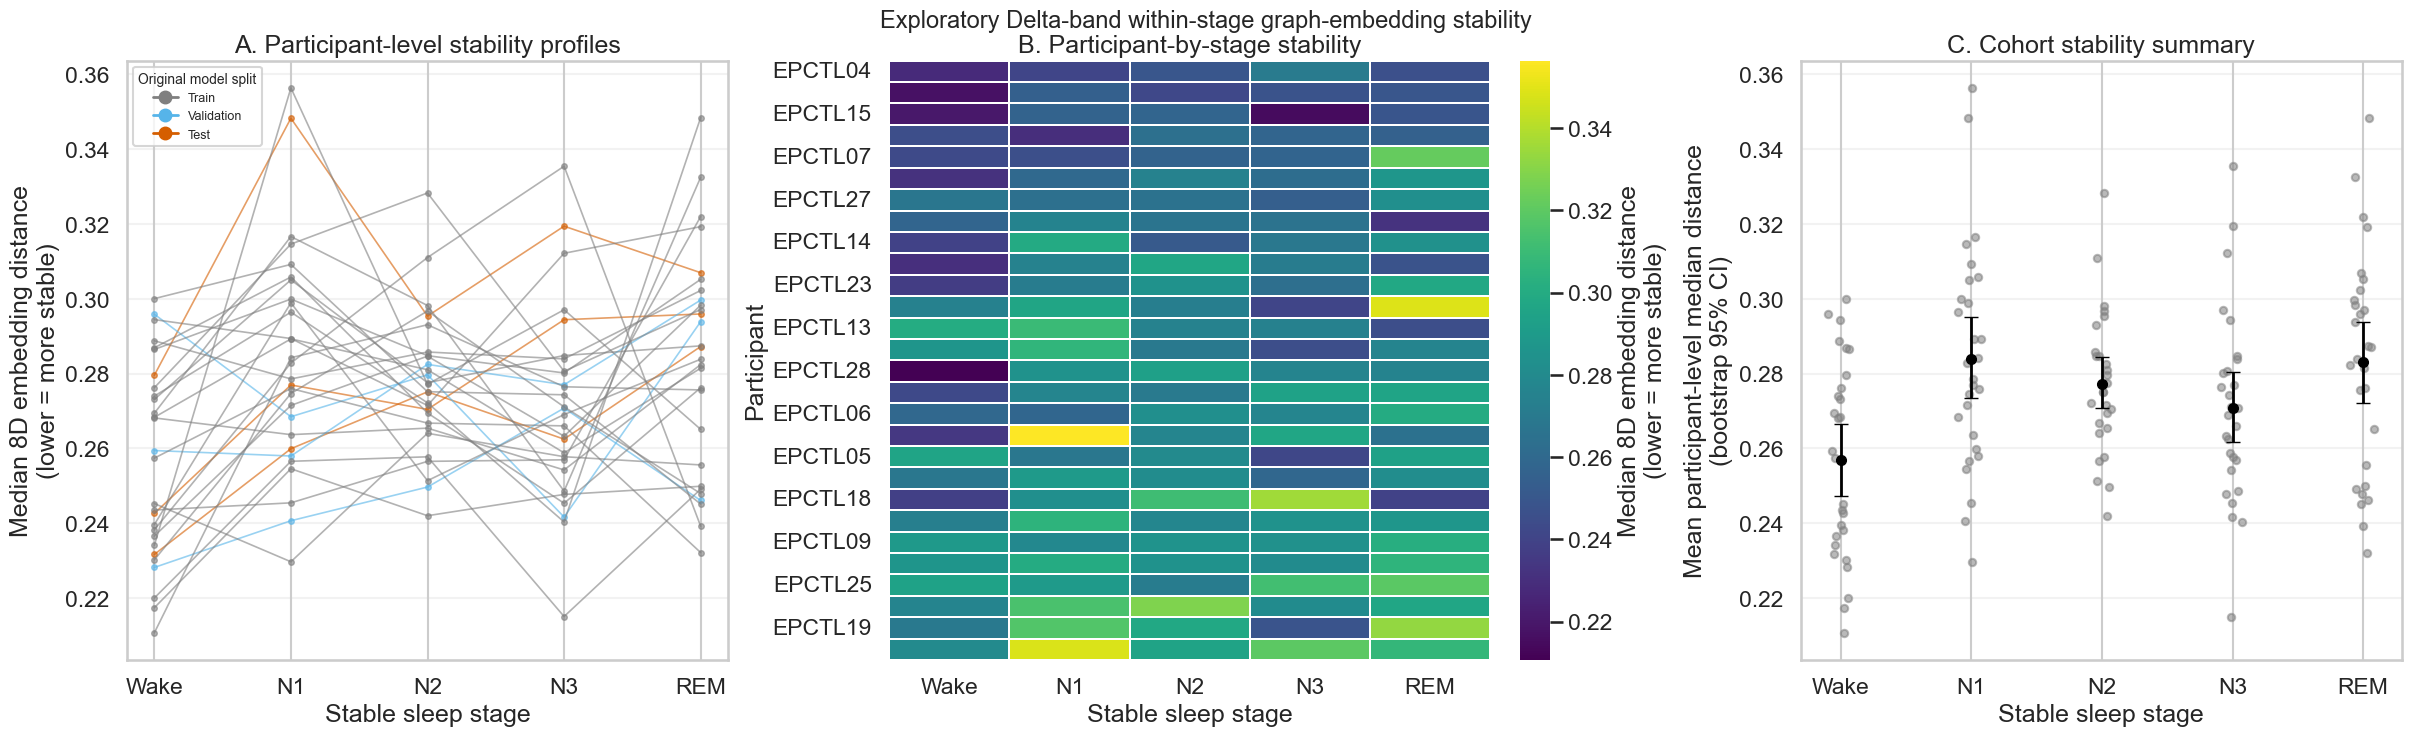


HELD-OUT TEST-SUBJECT STABLE-STAGE SUMMARY


,stable_stage,n_subjects,total_stable_pairs,median_of_subject_medians,mean_of_subject_medians
0,Wake,3,243,0.242571,0.251239
1,N1,3,132,0.276937,0.295040
2,N2,3,1164,0.275099,0.280289
3,N3,3,535,0.294398,0.292088
4,REM,3,341,0.295936,0.296712



WITHIN-STAGE STABILITY ANALYSIS COMPLETE

Saved outputs:
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_stable_adjacent_30_second_embedding_pairs.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_subject_level_within_stage_stability.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_participant_by_stage_stability_matrix.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_within_stage_stability_descriptive_summary.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_within_stage_stability_bootstrap_summary.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_held_out_test_within_stage_stability_summary.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_within_stage_stability_combined.png

Interpretation reminder:
Lower median embedding distance means greater temporal stability of the learned graph representation withi

In [69]:
# ------------------------------------------------------------------
# Cell 17 — exploratory within-stage stability profile
#
#The exploratory question: Does within-stage temporal stability of the learned delta-band functional-network 
# representation differ across Wake, N1, N2, N3, and REM?

#The analysis uses only stable 30-second pairs: Wake → Wake, N1 → N1, N2 → N2, N3 → N3, REM → REM
# and gives each participant one median value per stage. It does not use transitions as an outcome. 
# This matches the stated GAT proof-of-concept aim of examining embeddings in relation to stability and stage 
# while respecting that repeated epochs are nested within participant.


# Main question:
#
# Does temporal stability of the learned delta-band functional-network
# representation differ across Wake, N1, N2, N3, and REM?
#
# Outcome:
#
# For each adjacent 30-second pair of graphs with the SAME scored
# sleep-stage label:
#
# embedding_distance = || graph_embedding_t - graph_embedding_(t-1) ||
#
# Smaller embedding distance:
# The learned graph representation is more stable from one 30-second
# epoch to the next.
#
# Larger embedding distance:
# The learned graph representation changes more from one 30-second
# epoch to the next.
#
# Important design decision:
#
# - Use only pair_type == "stable".
# - Use only exact adjacent 30-second pairs.
# - Summarize first within each participant and stage using medians.
# - Treat participant-level median values as the units for cohort
#   description and exploratory statistics.
#
# This replaces the earlier broad hypothesis that all transitions
# should show greater displacement than stable pairs.
# ------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------------
# 1. Verify that Cell 16 has created the required pair-level table.
# ------------------------------------------------------------------

required_variables = [
    "adjacent_pairs_df",
    "PHASE_B_OUTPUT_DIR",
    "BAND_TO_RUN",
    "EPOCH_STRIDE",
    "RETAINED_DENSITY",
    "STAGE_ORDER",
    "SEED",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run Cell 16 before this cell.\n"
        f"Missing variables: {missing_variables}"
    )

required_columns = [
    "subject_id",
    "split",
    "band",
    "previous_stage",
    "current_stage",
    "stage_pair",
    "pair_type",
    "stored_epoch_gap",
    "time_gap_minutes",
    "embedding_distance",
]

missing_columns = [
    column_name
    for column_name in required_columns
    if column_name not in adjacent_pairs_df.columns
]

if missing_columns:
    raise RuntimeError(
        "adjacent_pairs_df is missing required columns:\n"
        f"{missing_columns}"
    )


# ------------------------------------------------------------------
# 2. Restrict to stable, adjacent 30-second pairs.
#
# `adjacent_pairs_df` was already constructed from pairs separated by
# exactly one stored 30-second epoch. The checks below make this
# requirement explicit and protect against accidental misuse if the
# table changes later.
# ------------------------------------------------------------------

stable_pairs_df = adjacent_pairs_df[
    (
        adjacent_pairs_df["pair_type"]
        == "stable"
    )
    & (
        adjacent_pairs_df["previous_stage"]
        == adjacent_pairs_df["current_stage"]
    )
    & (
        adjacent_pairs_df["stored_epoch_gap"]
        == 1
    )
    & np.isclose(
        adjacent_pairs_df["time_gap_minutes"],
        0.5,
    )
].copy()

if len(stable_pairs_df) == 0:
    raise RuntimeError(
        "No stable adjacent 30-second pairs were found."
    )

# The pair label is now simply the stable stage name:
# Wake->Wake becomes Wake, N1->N1 becomes N1, etc.
stable_pairs_df["stable_stage"] = (
    stable_pairs_df["current_stage"]
)

stable_pairs_df["stable_stage"] = pd.Categorical(
    stable_pairs_df["stable_stage"],
    categories=STAGE_ORDER,
    ordered=True,
)

stable_pairs_df = (
    stable_pairs_df
    .sort_values(
        [
            "subject_id",
            "stable_stage",
        ]
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("STABLE 30-SECOND PAIRS FOR WITHIN-STAGE DYNAMICS")
print("=" * 70)

print("Total stable adjacent pairs:", len(stable_pairs_df))

print("\nStable pairs by stage:")
print(
    stable_pairs_df[
        "stable_stage"
    ]
    .value_counts()
    .reindex(STAGE_ORDER)
)

print("\nStable pairs by original model split:")
print(
    stable_pairs_df[
        "split"
    ].value_counts()
)

print("\nStable pairs by held-out test subject:")
print(
    stable_pairs_df[
        stable_pairs_df["split"] == "test"
    ]
    .groupby("subject_id")
    .size()
)


# ------------------------------------------------------------------
# 3. Create one participant-level median embedding distance per stage.
#
# This is the main table for the stability analysis.
#
# Every row is:
#
# participant × stage
#
# not:
#
# one individual 30-second epoch pair.
#
# The median is robust to occasional large graph changes.
# ------------------------------------------------------------------

subject_stage_stability_df = (
    stable_pairs_df
    .groupby(
        [
            "subject_id",
            "split",
            "band",
            "stable_stage",
        ],
        observed=False,
        as_index=False,
    )
    .agg(
        n_stable_30s_pairs=(
            "embedding_distance",
            "count",
        ),
        median_embedding_distance=(
            "embedding_distance",
            "median",
        ),
        mean_embedding_distance=(
            "embedding_distance",
            "mean",
        ),
        sd_embedding_distance=(
            "embedding_distance",
            "std",
        ),
    )
)

subject_stage_stability_df = (
    subject_stage_stability_df
    .sort_values(
        [
            "subject_id",
            "stable_stage",
        ]
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("PARTICIPANT-LEVEL STABLE-STAGE SUMMARY")
print("=" * 70)

print(
    "Participant × stage rows:",
    len(subject_stage_stability_df)
)

print("\nNumber of participants represented per stage:")
print(
    subject_stage_stability_df
    .groupby(
        "stable_stage",
        observed=False,
    )["subject_id"]
    .nunique()
    .reindex(STAGE_ORDER)
)

print("\nFirst 10 participant-stage rows:")
display(
    subject_stage_stability_df.head(10)
)


# ------------------------------------------------------------------
# 4. Build a complete participant-by-stage matrix.
#
# Rows:
# one participant
#
# Columns:
# Wake, N1, N2, N3, REM
#
# Values:
# median embedding distance during stable adjacent 30-second pairs.
#
# Missing value:
# this participant had no sampled stable adjacent pair for that stage.
# ------------------------------------------------------------------

stability_matrix_df = (
    subject_stage_stability_df
    .pivot(
        index="subject_id",
        columns="stable_stage",
        values="median_embedding_distance",
    )
    .reindex(columns=STAGE_ORDER)
)

subject_split_lookup = (
    subject_stage_stability_df
    .drop_duplicates("subject_id")
    .set_index("subject_id")["split"]
)

stability_matrix_df["split"] = (
    subject_split_lookup
)

stability_matrix_df = (
    stability_matrix_df
    .sort_values(
        "split",
        key=lambda x: x.map(
            {
                "train": 0,
                "validation": 1,
                "test": 2,
            }
        ),
    )
)

print("\nParticipant-by-stage stability matrix:")
display(
    stability_matrix_df.head()
)


# ------------------------------------------------------------------
# 5. Cohort-level descriptive summaries.
#
# These values give each participant equal weight within a stage.
# Do not pool all raw 30-second pairs across subjects.
# ------------------------------------------------------------------

stage_stability_summary_df = (
    subject_stage_stability_df
    .groupby(
        "stable_stage",
        observed=False,
        as_index=False,
    )
    .agg(
        n_subjects=(
            "subject_id",
            "nunique",
        ),
        total_stable_pairs=(
            "n_stable_30s_pairs",
            "sum",
        ),
        median_of_subject_medians=(
            "median_embedding_distance",
            "median",
        ),
        mean_of_subject_medians=(
            "median_embedding_distance",
            "mean",
        ),
        sd_of_subject_medians=(
            "median_embedding_distance",
            "std",
        ),
        minimum_subject_median=(
            "median_embedding_distance",
            "min",
        ),
        maximum_subject_median=(
            "median_embedding_distance",
            "max",
        ),
    )
)

stage_stability_summary_df["stable_stage"] = pd.Categorical(
    stage_stability_summary_df["stable_stage"],
    categories=STAGE_ORDER,
    ordered=True,
)

stage_stability_summary_df = (
    stage_stability_summary_df
    .sort_values("stable_stage")
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("FULL-COHORT STABLE-STAGE DESCRIPTIVE SUMMARY")
print("=" * 70)

display(
    stage_stability_summary_df
)


# ------------------------------------------------------------------
# 6. Bootstrap 95% confidence interval for each stage.
#
# We resample participants WITHIN EACH STAGE.
#
# This is exploratory and descriptive. It shows uncertainty around
# the mean and median participant-level stability estimate for each
# stage without treating individual epoch pairs as independent.
# ------------------------------------------------------------------

BOOTSTRAP_ITERATIONS = 10_000

bootstrap_rng = np.random.default_rng(SEED)

bootstrap_rows = []

for stage_name in STAGE_ORDER:

    stage_values = (
        subject_stage_stability_df.loc[
            subject_stage_stability_df[
                "stable_stage"
            ] == stage_name,
            "median_embedding_distance",
        ]
        .dropna()
        .to_numpy(dtype=float)
    )

    if len(stage_values) == 0:
        bootstrap_rows.append(
            {
                "stable_stage": stage_name,
                "n_subjects": 0,
                "mean_of_subject_medians": np.nan,
                "mean_ci_95_low": np.nan,
                "mean_ci_95_high": np.nan,
                "median_of_subject_medians": np.nan,
                "median_ci_95_low": np.nan,
                "median_ci_95_high": np.nan,
            }
        )
        continue

    bootstrap_means = np.empty(
        BOOTSTRAP_ITERATIONS,
        dtype=float,
    )

    bootstrap_medians = np.empty(
        BOOTSTRAP_ITERATIONS,
        dtype=float,
    )

    for bootstrap_index in range(
        BOOTSTRAP_ITERATIONS
    ):

        bootstrap_sample = bootstrap_rng.choice(
            stage_values,
            size=len(stage_values),
            replace=True,
        )

        bootstrap_means[bootstrap_index] = np.mean(
            bootstrap_sample
        )

        bootstrap_medians[
            bootstrap_index
        ] = np.median(
            bootstrap_sample
        )

    mean_ci_low, mean_ci_high = np.percentile(
        bootstrap_means,
        [2.5, 97.5],
    )

    median_ci_low, median_ci_high = np.percentile(
        bootstrap_medians,
        [2.5, 97.5],
    )

    bootstrap_rows.append(
        {
            "stable_stage": stage_name,
            "n_subjects": int(len(stage_values)),
            "mean_of_subject_medians": float(
                np.mean(stage_values)
            ),
            "mean_ci_95_low": float(mean_ci_low),
            "mean_ci_95_high": float(mean_ci_high),
            "median_of_subject_medians": float(
                np.median(stage_values)
            ),
            "median_ci_95_low": float(
                median_ci_low
            ),
            "median_ci_95_high": float(
                median_ci_high
            ),
        }
    )

stage_bootstrap_summary_df = pd.DataFrame(
    bootstrap_rows
)

stage_bootstrap_summary_df["stable_stage"] = pd.Categorical(
    stage_bootstrap_summary_df["stable_stage"],
    categories=STAGE_ORDER,
    ordered=True,
)

stage_bootstrap_summary_df = (
    stage_bootstrap_summary_df
    .sort_values("stable_stage")
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("EXPLORATORY PARTICIPANT-LEVEL BOOTSTRAP SUMMARY")
print("=" * 70)

display(
    stage_bootstrap_summary_df
)


# ------------------------------------------------------------------
# 7. Create a combined three-panel figure.
#
# Panel A:
# Participant-level stable-stage medians, connected within person.
#
# Panel B:
# Participant-by-stage heatmap of median stability values.
#
# Panel C:
# Cohort summary with bootstrap 95% CI around the mean of
# participant-level medians.
#
# All plots are descriptive/exploratory.
# ------------------------------------------------------------------

split_palette = {
    "train": "#7F7F7F",       # gray
    "validation": "#56B4E9",  # light blue
    "test": "#D55E00",        # orange-red
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 7),
    constrained_layout=True,
)

ax_lines = axes[0]
ax_heatmap = axes[1]
ax_summary = axes[2]


# ------------------------------------------------------------------
# Panel A — participant-level stage profiles.
#
# Each line is one participant.
# Colour shows the original model partition only, not a biological
# category:
#
# gray = training participant
# blue = validation participant
# orange = held-out test participant
# ------------------------------------------------------------------

for subject_id, subject_df in (
    subject_stage_stability_df.groupby(
        "subject_id",
        sort=False,
    )
):

    subject_df = (
        subject_df
        .sort_values("stable_stage")
        .dropna(
            subset=[
                "median_embedding_distance",
            ]
        )
    )

    if len(subject_df) == 0:
        continue

    subject_split = subject_df["split"].iloc[0]

    ax_lines.plot(
        subject_df["stable_stage"],
        subject_df[
            "median_embedding_distance"
        ],
        color=split_palette[
            subject_split
        ],
        marker="o",
        markersize=4,
        linewidth=1.2,
        alpha=0.60,
    )

ax_lines.set_title(
    "A. Participant-level stability profiles"
)

ax_lines.set_xlabel(
    "Stable sleep stage"
)

ax_lines.set_ylabel(
    "Median 8D embedding distance\n"
    "(lower = more stable)"
)

ax_lines.grid(
    axis="y",
    alpha=0.25,
)

split_legend_handles = [
    plt.Line2D(
        [0],
        [0],
        color=split_palette[split_name],
        marker="o",
        linewidth=2,
        label=split_name.capitalize(),
    )
    for split_name in [
        "train",
        "validation",
        "test",
    ]
]

ax_lines.legend(
    handles=split_legend_handles,
    title="Original model split",
    fontsize=9,
    title_fontsize=10,
    loc="best",
)


# ------------------------------------------------------------------
# Panel B — participant-by-stage heatmap.
#
# Rows:
# participants
#
# Columns:
# stable stages
#
# Colour:
# participant-level median 8D embedding distance.
#
# Missing values remain blank if a participant had no stable adjacent
# pair for a stage in the transition-aware selected sample.
# ------------------------------------------------------------------

heatmap_values_df = stability_matrix_df[
    STAGE_ORDER
].copy()

# Order rows by median available stability value for visual clarity.
row_order = heatmap_values_df.median(
    axis=1,
    skipna=True,
).sort_values().index

heatmap_values_df = heatmap_values_df.loc[
    row_order
]

sns.heatmap(
    heatmap_values_df,
    cmap="viridis",
    linewidths=0.25,
    linecolor="white",
    cbar_kws={
        "label": (
            "Median 8D embedding distance\n"
            "(lower = more stable)"
        )
    },
    ax=ax_heatmap,
)

ax_heatmap.set_title(
    "B. Participant-by-stage stability"
)

ax_heatmap.set_xlabel("Stable sleep stage")
ax_heatmap.set_ylabel("Participant")


# ------------------------------------------------------------------
# Panel C — cohort summary of participant-level medians.
#
# The point is the mean of subject medians.
# The vertical error bar is the bootstrap 95% confidence interval.
#
# The dots are the individual participant-level values.
# They are shown faintly only to make individual variability visible.
# ------------------------------------------------------------------

for stage_position, stage_name in enumerate(
    STAGE_ORDER
):

    stage_values = subject_stage_stability_df.loc[
        subject_stage_stability_df[
            "stable_stage"
        ] == stage_name,
        "median_embedding_distance",
    ].dropna().to_numpy(dtype=float)

    if len(stage_values) == 0:
        continue

    # Small reproducible jitter for display only.
    jitter_rng = np.random.default_rng(
        SEED + stage_position
    )

    x_jitter = jitter_rng.normal(
        loc=stage_position,
        scale=0.05,
        size=len(stage_values),
    )

    ax_summary.scatter(
        x_jitter,
        stage_values,
        color="gray",
        alpha=0.55,
        s=28,
        zorder=1,
    )

    stage_summary_row = stage_bootstrap_summary_df[
        stage_bootstrap_summary_df[
            "stable_stage"
        ] == stage_name
    ].iloc[0]

    mean_value = stage_summary_row[
        "mean_of_subject_medians"
    ]

    ci_low = stage_summary_row[
        "mean_ci_95_low"
    ]

    ci_high = stage_summary_row[
        "mean_ci_95_high"
    ]

    ax_summary.errorbar(
        stage_position,
        mean_value,
        yerr=[
            [mean_value - ci_low],
            [ci_high - mean_value],
        ],
        fmt="o",
        color="black",
        capsize=5,
        markersize=7,
        linewidth=2,
        zorder=2,
    )

ax_summary.set_xticks(
    range(len(STAGE_ORDER))
)

ax_summary.set_xticklabels(
    STAGE_ORDER
)

ax_summary.set_title(
    "C. Cohort stability summary"
)

ax_summary.set_xlabel("Stable sleep stage")

ax_summary.set_ylabel(
    "Mean participant-level median distance\n"
    "(bootstrap 95% CI)"
)

ax_summary.grid(
    axis="y",
    alpha=0.25,
)

fig.suptitle(
    f"Exploratory {BAND_TO_RUN.capitalize()}-band "
    "within-stage graph-embedding stability",
    fontsize=17,
    y=1.03,
)

plt.show()


# ------------------------------------------------------------------
# 8. Optional descriptive table restricted to held-out test subjects.
#
# These three subjects did not participate in fitting, validation, or
# model selection. This table is useful as a small independent visual
# check, but it is not large enough for meaningful formal inference.
# ------------------------------------------------------------------

test_subject_stage_stability_df = (
    subject_stage_stability_df[
        subject_stage_stability_df["split"] == "test"
    ]
    .copy()
    .sort_values(
        [
            "subject_id",
            "stable_stage",
        ]
    )
    .reset_index(drop=True)
)

test_stage_stability_summary_df = (
    test_subject_stage_stability_df
    .groupby(
        "stable_stage",
        observed=False,
        as_index=False,
    )
    .agg(
        n_subjects=(
            "subject_id",
            "nunique",
        ),
        total_stable_pairs=(
            "n_stable_30s_pairs",
            "sum",
        ),
        median_of_subject_medians=(
            "median_embedding_distance",
            "median",
        ),
        mean_of_subject_medians=(
            "median_embedding_distance",
            "mean",
        ),
    )
)

test_stage_stability_summary_df["stable_stage"] = (
    pd.Categorical(
        test_stage_stability_summary_df[
            "stable_stage"
        ],
        categories=STAGE_ORDER,
        ordered=True,
    )
)

test_stage_stability_summary_df = (
    test_stage_stability_summary_df
    .sort_values("stable_stage")
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("HELD-OUT TEST-SUBJECT STABLE-STAGE SUMMARY")
print("=" * 70)

display(
    test_stage_stability_summary_df
)


# ------------------------------------------------------------------
# 9. Save tables and the combined figure.
# ------------------------------------------------------------------

stable_pairs_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_stable_adjacent_30_second_embedding_pairs.csv"
)

subject_stage_stability_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_subject_level_within_stage_stability.csv"
)

stability_matrix_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_participant_by_stage_stability_matrix.csv"
)

stage_summary_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_within_stage_stability_descriptive_summary.csv"
)

stage_bootstrap_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_within_stage_stability_bootstrap_summary.csv"
)

test_stage_summary_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_held_out_test_within_stage_stability_summary.csv"
)

stability_figure_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_within_stage_stability_combined.png"
)

stable_pairs_df.to_csv(
    stable_pairs_path,
    index=False,
)

subject_stage_stability_df.to_csv(
    subject_stage_stability_path,
    index=False,
)

stability_matrix_df.to_csv(
    stability_matrix_path,
    index=True,
)

stage_stability_summary_df.to_csv(
    stage_summary_path,
    index=False,
)

stage_bootstrap_summary_df.to_csv(
    stage_bootstrap_path,
    index=False,
)

test_stage_stability_summary_df.to_csv(
    test_stage_summary_path,
    index=False,
)

fig.savefig(
    stability_figure_path,
    dpi=300,
    bbox_inches="tight",
)


# ------------------------------------------------------------------
# 10. Store useful names for any later optional analysis.
# ------------------------------------------------------------------

all_stable_pairs_df = stable_pairs_df
within_stage_subject_summary_df = (
    subject_stage_stability_df
)
within_stage_cohort_summary_df = (
    stage_stability_summary_df
)
within_stage_bootstrap_summary_df = (
    stage_bootstrap_summary_df
)

print("\n" + "=" * 70)
print("WITHIN-STAGE STABILITY ANALYSIS COMPLETE")
print("=" * 70)

print("\nSaved outputs:")
print("-", stable_pairs_path)
print("-", subject_stage_stability_path)
print("-", stability_matrix_path)
print("-", stage_summary_path)
print("-", stage_bootstrap_path)
print("-", test_stage_summary_path)
print("-", stability_figure_path)

print("\nInterpretation reminder:")
print(
    "Lower median embedding distance means greater temporal "
    "stability of the learned graph representation within that stage."
)

print(
    "This is exploratory and participant-level. Do not interpret "
    "raw stable-pair counts as independent observations."
)



The key pattern is that the mean participant-level median embedding distance is very similar across stages, with overlapping bootstrap intervals, while individual stability profiles vary substantially across participants.

Conclusion: the delta-band GAT embedding demonstrates participant-specific within-stage network dynamics, but this first analysis does not provide clear evidence for a strong, uniform stage-specific stability ordering across the whole cohort. The model behaves as a useful descriptive representation-learning tool, not as proof that one sleep stage is definitively more stable than another.

Remembering: Lower median embedding distance = greater temporal stability. Higher median embedding distance = greater within-stage change. So, descriptively:

- Wake has the lowest mean participant-level median distance.
- REM has the highest mean participant-level median distance.
- N1, N2, and N3 sit between them.
- However, the differences are small relative to individual variation.
- Every bootstrap interval overlaps substantially with the others.

In the transition-aware sampled data, within-stage delta-band GAT embedding displacement was broadly similar across Wake, N1, N2, N3, and REM at the cohort level. REM showed the highest descriptive point estimate and Wake the lowest, but bootstrap confidence intervals overlapped substantially.

PLOT A:

- There is meaningful individual variability in learned delta-network stability.
- No one stage is uniformly lowest or highest for all participants.
- The highlighted held-out test subjects have different profiles, which is consistent with your earlier held-out transition result.
- A few high values, such as N2 around 0.56 and REM around 0.50, demonstrate outlying within-stage graph shifts rather than a consistent stage effect.

PLOT B:

The heatmap reinforces the same conclusion:

- No stage column has a uniform colour across people.
- There are no obvious whole-cohort vertical bands indicating one stage always has low or high displacement.
- Within-person variation across stages and between-person variation are both present.
- Missing values are expected where no stable adjacent pair was retained under the transition-aware sampling rule.

PLOT C: cohort summary

Panel C makes the uncertainty clear:

- The black points are mean participant-level medians.
- Error bars are bootstrap 95% confidence intervals.
- Gray dots are individual participant-level medians.
- The stage means are close together.
- The intervals overlap substantially.

The 8D graph embeddings were used to characterize within-stage delta-band network stability from adjacent 30-s epoch pairs. Participant-level median embedding displacement was broadly comparable across Wake, N1, N2, N3, and REM, with descriptive mean values ranging from 0.262 to 0.286. Bootstrap 95% confidence intervals overlapped across stages, and individual stability profiles varied substantially. Thus, in this transition-aware sample, the learned delta-band network representation did not exhibit a robust cohort-wide stage-specific stability ordering.

Participants lacking a sampled stable adjacent pair for a given stage contributed no stability estimate for that stage.

PCA FIT AND TRANSFORMATION COMPLETE
PCA fitted on training-subject embeddings: 18327
Held-out test embeddings projected: 2730

Variance explained by PCA component 1: 0.336
Variance explained by PCA component 2: 0.232
Total variance explained by two PCA dimensions: 0.568


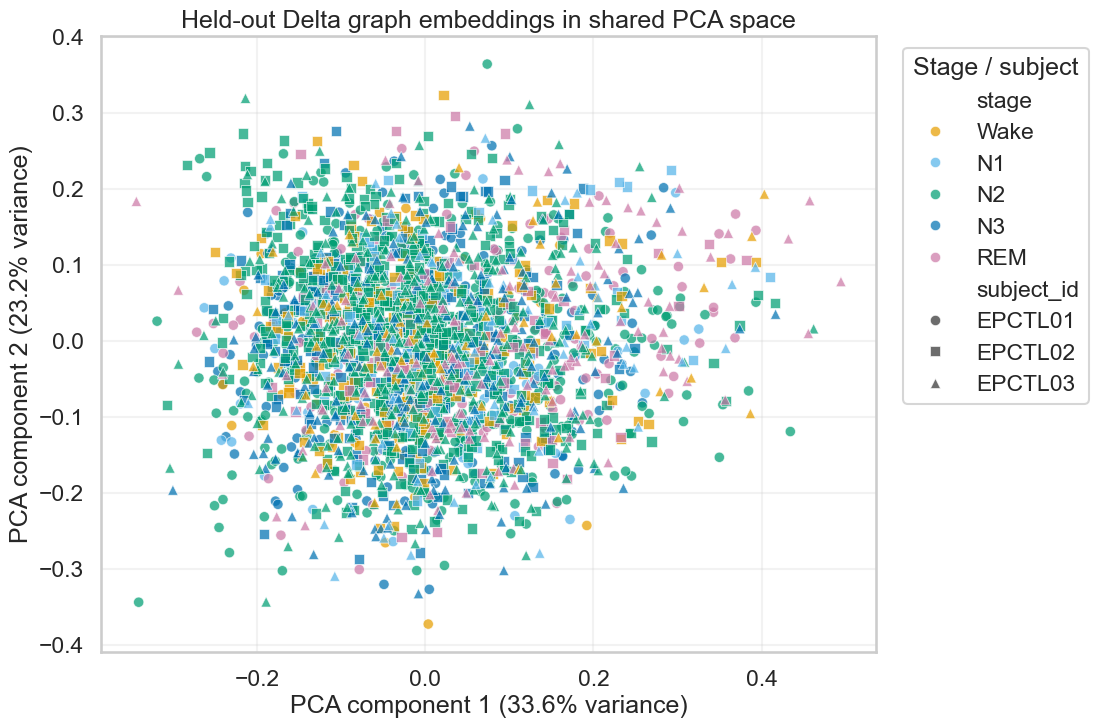

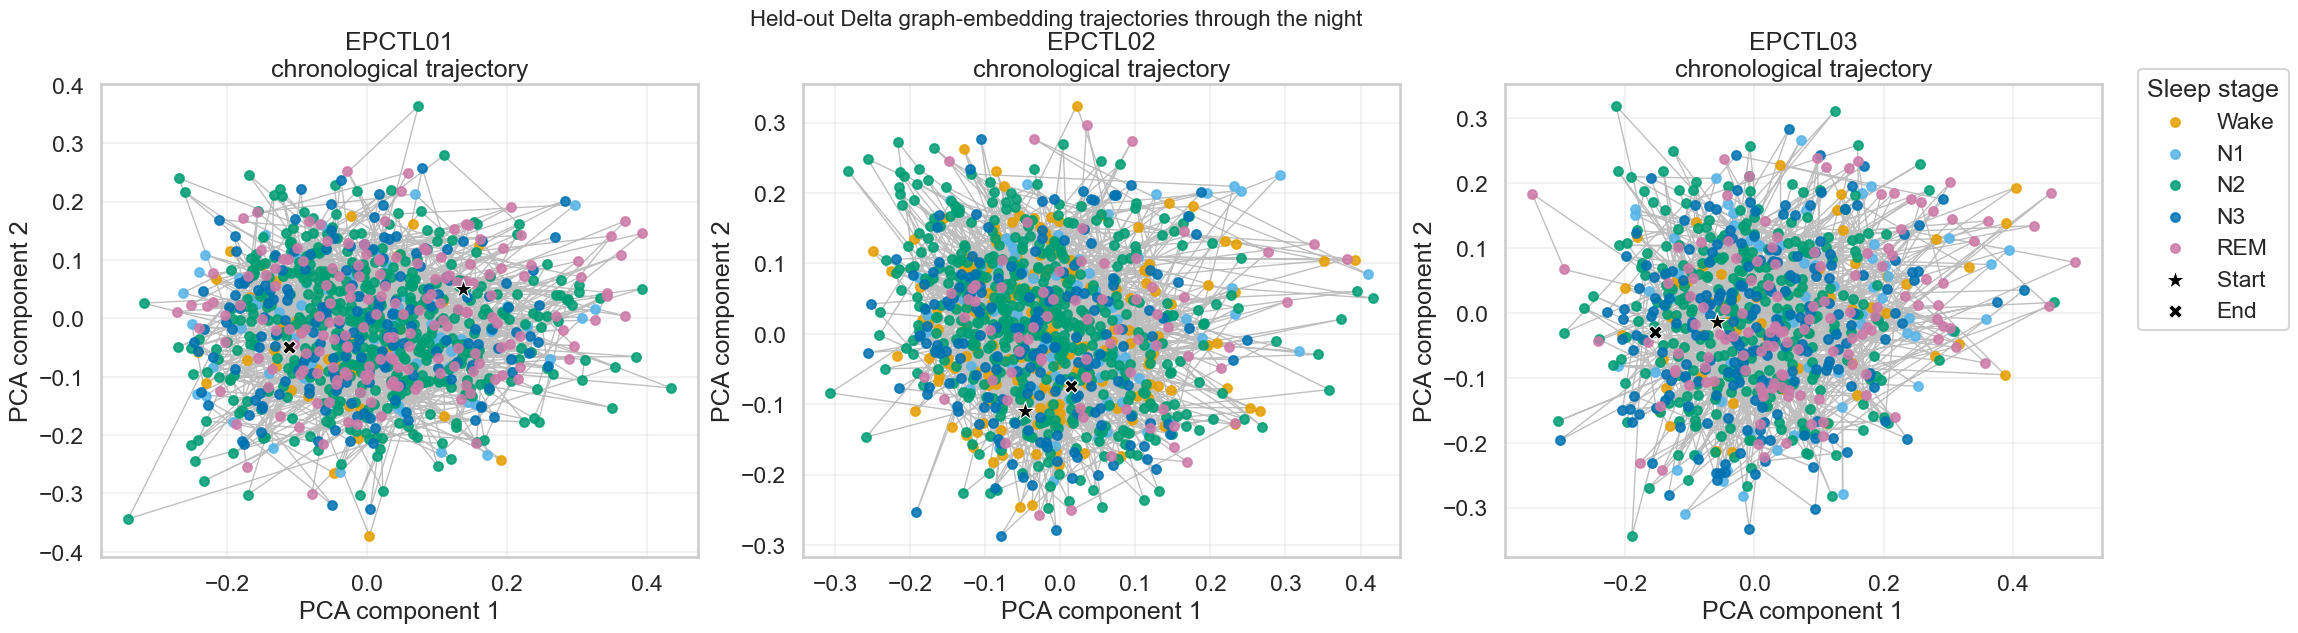

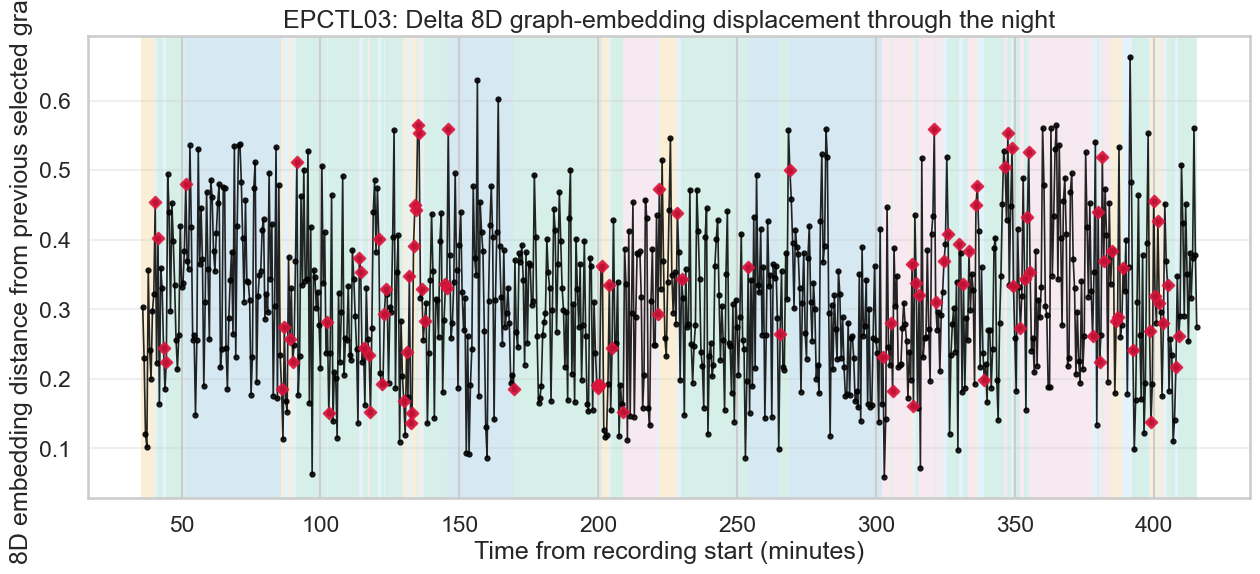


CELL 18 COMPLETE
PCA total explained variance: 0.568

Saved tables:
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_all_graph_embeddings_pca_coordinates.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_held_out_test_graph_embeddings_pca_coordinates.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_all_graph_embedding_displacements.csv

Saved figures:
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_held_out_shared_pca_embedding_space.png
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_held_out_pca_trajectories.png
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_EPCTL03_embedding_displacement_trajectory.png

Available objects:
- pca_embeddings_df
- test_pca_embeddings_df
- embedding_displacement_df
- all_pca_embeddings_df
- held_out_pca_embeddings_df
- all_embedding_displacement_df


In [70]:
# ------------------------------------------------------------------
# Cell 18 — visualise dynamic graph-embedding trajectories with PCA.
#
# Purpose:
# Convert the learned 8D graph-summary embeddings into two dimensions
# for visualisation only.
#
# Important:
# PCA is a display tool here.
#
# Do NOT repeat the statistical stable-vs-transition analysis in PCA
# coordinates. The quantitative analysis remains in the original 8D
# embedding space, using Euclidean embedding distances calculated in
# Cell 16.
#
# This cell shows:
#
# 1. Held-out test-subject embeddings in shared PCA space.
# 2. Separate chronological trajectories for EPCTL01, EPCTL02, and
#    EPCTL03.
# 3. A time-series plot of 8D embedding displacement for one selected
#    held-out subject, with sleep-stage background shading.
#
# Stage labels are used only for post-training interpretation.
# They were NOT given to the autoencoder training objective.
# ------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA


# ------------------------------------------------------------------
# 1. Check required variables.
# ------------------------------------------------------------------

required_variables = [
    "embeddings_df",
    "test_embeddings_df",
    "embedding_columns",
    "test_adjacent_pairs_df",
    "PHASE_B_OUTPUT_DIR",
    "BAND_TO_RUN",
    "EPOCH_STRIDE",
    "RETAINED_DENSITY",
    "STAGE_ORDER",
    "SEED",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run Cells 15 and 16 before Cell 18.\n"
        f"Missing variables: {missing_variables}"
    )

if len(test_embeddings_df) == 0:
    raise RuntimeError(
        "test_embeddings_df is empty."
    )

if len(embedding_columns) != 8:
    raise ValueError(
        "Expected eight graph-embedding columns, but found "
        f"{len(embedding_columns)}."
    )

if not np.all(
    np.isfinite(
        embeddings_df[
            embedding_columns
        ].to_numpy()
    )
):
    raise ValueError(
        "embeddings_df contains NaN or infinite embedding values."
    )


# ------------------------------------------------------------------
# 2. Create a consistent sleep-stage colour palette.
#
# The same colours will be used in all trajectory plots.
# ------------------------------------------------------------------

stage_palette = {
    "Wake": "#E69F00",  # orange
    "N1": "#56B4E9",    # light blue
    "N2": "#009E73",    # green
    "N3": "#0072B2",    # dark blue
    "REM": "#CC79A7",   # purple
}

missing_palette_stages = [
    stage_name
    for stage_name in STAGE_ORDER
    if stage_name not in stage_palette
]

if missing_palette_stages:
    raise RuntimeError(
        "Missing colours for stages:\n"
        f"{missing_palette_stages}"
    )


# ------------------------------------------------------------------
# 3. Fit PCA using training-subject embeddings only.
#
# Why:
# The PCA display axes are learned from training data, preserving the
# distinction between:
#
# - training embeddings used to define the visual coordinate system;
# - validation/test embeddings projected into that fixed space.
#
# This is not required for unsupervised visualisation, but it is a
# cleaner practice for showing held-out trajectories.
# ------------------------------------------------------------------

train_embeddings_for_pca = embeddings_df[
    embeddings_df["split"] == "train"
].copy()

if len(train_embeddings_for_pca) == 0:
    raise RuntimeError(
        "No training-subject embeddings found for PCA fitting."
    )

pca = PCA(
    n_components=2,
    random_state=SEED,
)

pca.fit(
    train_embeddings_for_pca[
        embedding_columns
    ].to_numpy()
)

# Transform all graphs using the PCA axes fitted on training subjects.
all_pca_coordinates = pca.transform(
    embeddings_df[
        embedding_columns
    ].to_numpy()
)

pca_embeddings_df = embeddings_df.copy()

pca_embeddings_df["pca_1"] = (
    all_pca_coordinates[:, 0]
)

pca_embeddings_df["pca_2"] = (
    all_pca_coordinates[:, 1]
)

# Preserve chronological order within subject.
pca_embeddings_df = (
    pca_embeddings_df
    .sort_values(
        [
            "subject_id",
            "stored_epoch_position",
        ]
    )
    .reset_index(drop=True)
)

test_pca_embeddings_df = pca_embeddings_df[
    pca_embeddings_df["split"] == "test"
].copy()

if len(test_pca_embeddings_df) != len(
    test_embeddings_df
):
    raise RuntimeError(
        "Unexpected mismatch between test embedding rows and "
        "test PCA embedding rows."
    )

print("=" * 70)
print("PCA FIT AND TRANSFORMATION COMPLETE")
print("=" * 70)

print(
    "PCA fitted on training-subject embeddings:",
    len(train_embeddings_for_pca),
)

print(
    "Held-out test embeddings projected:",
    len(test_pca_embeddings_df),
)

print(
    "\nVariance explained by PCA component 1:",
    f"{pca.explained_variance_ratio_[0]:.3f}",
)

print(
    "Variance explained by PCA component 2:",
    f"{pca.explained_variance_ratio_[1]:.3f}",
)

print(
    "Total variance explained by two PCA dimensions:",
    f"{pca.explained_variance_ratio_.sum():.3f}",
)


# ------------------------------------------------------------------
# 4. Combined held-out PCA scatter plot.
#
# This shows all held-out epoch graphs in the SAME PCA coordinate
# system. Points are coloured by independently scored sleep stage and
# shaped by subject.
#
# Do not interpret visual clustering alone as proof of stage
# separation. This plot is descriptive.
# ------------------------------------------------------------------

test_subject_ids = sorted(
    test_pca_embeddings_df["subject_id"].unique()
)

subject_markers = {
    "EPCTL01": "o",
    "EPCTL02": "s",
    "EPCTL03": "^",
}

fallback_markers = [
    "o",
    "s",
    "^",
    "D",
    "P",
    "X",
]

for index, subject_id in enumerate(test_subject_ids):
    if subject_id not in subject_markers:
        subject_markers[subject_id] = fallback_markers[
            index % len(fallback_markers)
        ]

fig, ax = plt.subplots(
    figsize=(10, 8),
)

sns.scatterplot(
    data=test_pca_embeddings_df,
    x="pca_1",
    y="pca_2",
    hue="stage",
    hue_order=STAGE_ORDER,
    palette=stage_palette,
    style="subject_id",
    markers=subject_markers,
    s=55,
    alpha=0.72,
    ax=ax,
)

ax.set_title(
    f"Held-out {BAND_TO_RUN.capitalize()} graph embeddings "
    "in shared PCA space"
)

ax.set_xlabel(
    "PCA component 1 "
    f"({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

ax.set_ylabel(
    "PCA component 2 "
    f"({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Stage / subject",
)

ax.grid(alpha=0.25)

plt.show()


# ------------------------------------------------------------------
# 5. One chronological PCA trajectory plot per held-out participant.
#
# The gray line connects embeddings in chronological order.
# The coloured points indicate independent manual sleep-stage labels.
#
# This visualises the path each participant's delta-band network takes
# through the learned graph-representation space.
# ------------------------------------------------------------------

n_test_subjects = len(test_subject_ids)

fig, axes = plt.subplots(
    1,
    n_test_subjects,
    figsize=(7 * n_test_subjects, 6),
    constrained_layout=True,
)

# If there is only one held-out subject, Matplotlib returns one Axes
# object rather than a list. This keeps the loop safe.
if n_test_subjects == 1:
    axes = [axes]

for ax, subject_id in zip(
    axes,
    test_subject_ids,
):

    subject_pca_df = test_pca_embeddings_df[
        test_pca_embeddings_df["subject_id"]
        == subject_id
    ].sort_values(
        "stored_epoch_position"
    )

    # Connect selected points by chronological sequence.
    ax.plot(
        subject_pca_df["pca_1"],
        subject_pca_df["pca_2"],
        color="gray",
        linewidth=1.0,
        alpha=0.50,
        zorder=1,
    )

    # Overlay points coloured by scored sleep stage.
    for stage_name in STAGE_ORDER:

        stage_rows = subject_pca_df[
            subject_pca_df["stage"]
            == stage_name
        ]

        if len(stage_rows) == 0:
            continue

        ax.scatter(
            stage_rows["pca_1"],
            stage_rows["pca_2"],
            color=stage_palette[stage_name],
            label=stage_name,
            s=40,
            alpha=0.85,
            zorder=2,
        )

    # Mark the first and final selected graph.
    first_row = subject_pca_df.iloc[0]
    last_row = subject_pca_df.iloc[-1]

    ax.scatter(
        first_row["pca_1"],
        first_row["pca_2"],
        marker="*",
        s=200,
        color="black",
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
        label="Start",
    )

    ax.scatter(
        last_row["pca_1"],
        last_row["pca_2"],
        marker="X",
        s=100,
        color="black",
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
        label="End",
    )

    ax.set_title(
        f"{subject_id}\nchronological trajectory"
    )

    ax.set_xlabel("PCA component 1")
    ax.set_ylabel("PCA component 2")

    ax.grid(alpha=0.25)

# Put one shared legend outside the final panel.
legend_handles, legend_labels = axes[-1].get_legend_handles_labels()

unique_legend = dict(
    zip(
        legend_labels,
        legend_handles,
    )
)

fig.legend(
    unique_legend.values(),
    unique_legend.keys(),
    title="Sleep stage",
    bbox_to_anchor=(1.01, 0.95),
    loc="upper left",
)

fig.suptitle(
    f"Held-out {BAND_TO_RUN.capitalize()} graph-embedding "
    "trajectories through the night",
    fontsize=16,
    y=1.03,
)

plt.show()


# ------------------------------------------------------------------
# 6. Build a time-series table of graph-embedding displacement.
#
# For each selected graph:
#
# displacement_t = ||g_t - g_(t-1)||_2
#
# This is calculated in ORIGINAL 8D embedding space, not PCA space.
#
# The first graph per subject has no preceding graph, so its
# displacement is NaN.
# ------------------------------------------------------------------

embedding_displacement_df = pca_embeddings_df.copy()

embedding_displacement_df = (
    embedding_displacement_df
    .sort_values(
        [
            "subject_id",
            "stored_epoch_position",
        ]
    )
    .reset_index(drop=True)
)

embedding_matrix = embedding_displacement_df[
    embedding_columns
].to_numpy(
    dtype=float
)

# Prepare an empty displacement column.
embedding_displacement_df[
    "embedding_displacement_from_previous"
] = np.nan

for subject_id, subject_rows in embedding_displacement_df.groupby(
    "subject_id",
    sort=False,
):

    subject_indices = subject_rows.index.to_numpy()

    subject_embedding_matrix = embedding_displacement_df.loc[
        subject_indices,
        embedding_columns,
    ].to_numpy(
        dtype=float
    )

    # Difference between consecutive selected graph embeddings.
    subject_embedding_differences = np.diff(
        subject_embedding_matrix,
        axis=0,
    )

    subject_displacements = np.linalg.norm(
        subject_embedding_differences,
        axis=1,
    )

    # The first graph gets NaN because it has no previous graph.
    embedding_displacement_df.loc[
        subject_indices[1:],
        "embedding_displacement_from_previous",
    ] = subject_displacements


# ------------------------------------------------------------------
# 7. Helper: draw background sleep-stage segments.
#
# This shades each selected-epoch interval using its scored stage.
# It is only an approximate visual guide because graphs are selected
# with stride-10 plus transition-boundary sampling.
# ------------------------------------------------------------------

def shade_stage_segments(
    ax,
    subject_df,
    stage_palette,
    alpha=0.16,
):
    """
    Shade the time axis according to selected-epoch stage labels.

    Each selected point is extended halfway toward its neighbouring
    selected points, creating a readable stage-coloured background.
    """
    subject_df = (
        subject_df
        .sort_values("time_minutes")
        .reset_index(drop=True)
    )

    time_values = subject_df[
        "time_minutes"
    ].to_numpy(
        dtype=float
    )

    stage_values = subject_df[
        "stage"
    ].to_numpy(
        dtype=str
    )

    if len(time_values) < 1:
        return

    # Create interval boundaries halfway between adjacent selected
    # time points.
    boundaries = np.empty(
        len(time_values) + 1,
        dtype=float,
    )

    if len(time_values) == 1:
        boundaries[0] = time_values[0] - 0.25
        boundaries[1] = time_values[0] + 0.25

    else:
        midpoints = (
            time_values[:-1]
            + time_values[1:]
        ) / 2.0

        boundaries[1:-1] = midpoints

        first_half_gap = (
            time_values[1]
            - time_values[0]
        ) / 2.0

        last_half_gap = (
            time_values[-1]
            - time_values[-2]
        ) / 2.0

        boundaries[0] = time_values[0] - first_half_gap
        boundaries[-1] = time_values[-1] + last_half_gap

    for row_index, stage_name in enumerate(
        stage_values
    ):

        ax.axvspan(
            boundaries[row_index],
            boundaries[row_index + 1],
            color=stage_palette.get(
                stage_name,
                "lightgray",
            ),
            alpha=alpha,
            linewidth=0,
            zorder=0,
        )


# ------------------------------------------------------------------
# 8. Plot one subject's graph-embedding displacement over time.
#
# This is useful because it directly shows when the learned delta-band
# graph representation changes more or less across the night.
#
# It is a descriptive individual trajectory, not a group test.
# ------------------------------------------------------------------

SUBJECT_TO_PLOT = "EPCTL03"

if SUBJECT_TO_PLOT not in test_subject_ids:
    raise ValueError(
        f"{SUBJECT_TO_PLOT} is not among held-out test subjects:\n"
        f"{test_subject_ids}"
    )

subject_displacement_df = embedding_displacement_df[
    embedding_displacement_df["subject_id"]
    == SUBJECT_TO_PLOT
].copy()

subject_displacement_df = (
    subject_displacement_df
    .sort_values("stored_epoch_position")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(
    figsize=(15, 6),
)

shade_stage_segments(
    ax=ax,
    subject_df=subject_displacement_df,
    stage_palette=stage_palette,
    alpha=0.16,
)

ax.plot(
    subject_displacement_df["time_minutes"],
    subject_displacement_df[
        "embedding_displacement_from_previous"
    ],
    color="black",
    marker="o",
    markersize=3.5,
    linewidth=1.2,
    alpha=0.85,
    zorder=2,
)

# Highlight rows that begin a true adjacent 30-second stage transition.
transition_start_rows = subject_displacement_df[
    subject_displacement_df[
        "is_transition_start"
    ]
].copy()

ax.scatter(
    transition_start_rows["time_minutes"],
    transition_start_rows[
        "embedding_displacement_from_previous"
    ],
    color="crimson",
    marker="D",
    s=35,
    alpha=0.85,
    zorder=3,
    label="Transition-start epoch",
)

ax.set_title(
    f"{SUBJECT_TO_PLOT}: "
    f"{BAND_TO_RUN.capitalize()} 8D graph-embedding displacement "
    "through the night"
)

ax.set_xlabel("Time from recording start (minutes)")
ax.set_ylabel(
    "8D embedding distance from previous selected graph"
)

ax.grid(
    axis="y",
    alpha=0.30,
)

ax.legend(
    loc="upper right",
)

# Create a compact sleep-stage colour legend.
stage_legend_handles = [
    plt.Line2D(
        [0],
        [0],
        color=stage_palette[stage_name],
        linewidth=8,
        alpha=0.35,
        label=stage_name,
    )
    for stage_name in STAGE_ORDER
]

stage_legend = ax.legend(
    handles=stage_legend_handles,
    title="Selected-epoch stage",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
)

ax.add_artist(
    stage_legend
)

plt.show()


# ------------------------------------------------------------------
# 9. Save PCA coordinates and figure outputs.
# ------------------------------------------------------------------

pca_coordinates_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_all_graph_embeddings_pca_coordinates.csv"
)

test_pca_coordinates_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_held_out_test_graph_embeddings_pca_coordinates.csv"
)

displacement_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_all_graph_embedding_displacements.csv"
)

combined_pca_plot_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_held_out_shared_pca_embedding_space.png"
)

subject_trajectory_plot_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_held_out_pca_trajectories.png"
)

displacement_plot_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    f"_{SUBJECT_TO_PLOT}_embedding_displacement_trajectory.png"
)

# Save tables.
pca_embeddings_df.to_csv(
    pca_coordinates_path,
    index=False,
)

test_pca_embeddings_df.to_csv(
    test_pca_coordinates_path,
    index=False,
)

embedding_displacement_df.to_csv(
    displacement_path,
    index=False,
)


# ------------------------------------------------------------------
# Recreate and save combined held-out PCA scatter plot.
# ------------------------------------------------------------------

fig_combined, ax_combined = plt.subplots(
    figsize=(10, 8),
)

sns.scatterplot(
    data=test_pca_embeddings_df,
    x="pca_1",
    y="pca_2",
    hue="stage",
    hue_order=STAGE_ORDER,
    palette=stage_palette,
    style="subject_id",
    markers=subject_markers,
    s=55,
    alpha=0.72,
    ax=ax_combined,
)

ax_combined.set_title(
    f"Held-out {BAND_TO_RUN.capitalize()} graph embeddings "
    "in shared PCA space"
)

ax_combined.set_xlabel(
    "PCA component 1 "
    f"({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

ax_combined.set_ylabel(
    "PCA component 2 "
    f"({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

ax_combined.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Stage / subject",
)

ax_combined.grid(alpha=0.25)

fig_combined.savefig(
    combined_pca_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.close(fig_combined)


# ------------------------------------------------------------------
# Recreate and save per-subject chronological PCA trajectories.
# ------------------------------------------------------------------

fig_trajectories, trajectory_axes = plt.subplots(
    1,
    n_test_subjects,
    figsize=(7 * n_test_subjects, 6),
    constrained_layout=True,
)

if n_test_subjects == 1:
    trajectory_axes = [trajectory_axes]

for ax, subject_id in zip(
    trajectory_axes,
    test_subject_ids,
):

    subject_pca_df = test_pca_embeddings_df[
        test_pca_embeddings_df["subject_id"]
        == subject_id
    ].sort_values(
        "stored_epoch_position"
    )

    ax.plot(
        subject_pca_df["pca_1"],
        subject_pca_df["pca_2"],
        color="gray",
        linewidth=1.0,
        alpha=0.50,
        zorder=1,
    )

    for stage_name in STAGE_ORDER:

        stage_rows = subject_pca_df[
            subject_pca_df["stage"]
            == stage_name
        ]

        if len(stage_rows) == 0:
            continue

        ax.scatter(
            stage_rows["pca_1"],
            stage_rows["pca_2"],
            color=stage_palette[stage_name],
            label=stage_name,
            s=40,
            alpha=0.85,
            zorder=2,
        )

    first_row = subject_pca_df.iloc[0]
    last_row = subject_pca_df.iloc[-1]

    ax.scatter(
        first_row["pca_1"],
        first_row["pca_2"],
        marker="*",
        s=200,
        color="black",
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
        label="Start",
    )

    ax.scatter(
        last_row["pca_1"],
        last_row["pca_2"],
        marker="X",
        s=100,
        color="black",
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
        label="End",
    )

    ax.set_title(
        f"{subject_id}\nchronological trajectory"
    )

    ax.set_xlabel("PCA component 1")
    ax.set_ylabel("PCA component 2")
    ax.grid(alpha=0.25)

legend_handles, legend_labels = (
    trajectory_axes[-1]
    .get_legend_handles_labels()
)

unique_legend = dict(
    zip(
        legend_labels,
        legend_handles,
    )
)

fig_trajectories.legend(
    unique_legend.values(),
    unique_legend.keys(),
    title="Sleep stage",
    bbox_to_anchor=(1.01, 0.95),
    loc="upper left",
)

fig_trajectories.suptitle(
    f"Held-out {BAND_TO_RUN.capitalize()} graph-embedding "
    "trajectories through the night",
    fontsize=16,
    y=1.03,
)

fig_trajectories.savefig(
    subject_trajectory_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.close(fig_trajectories)


# ------------------------------------------------------------------
# Recreate and save the individual displacement-through-time plot.
# ------------------------------------------------------------------

fig_displacement, ax_displacement = plt.subplots(
    figsize=(15, 6),
)

shade_stage_segments(
    ax=ax_displacement,
    subject_df=subject_displacement_df,
    stage_palette=stage_palette,
    alpha=0.16,
)

ax_displacement.plot(
    subject_displacement_df["time_minutes"],
    subject_displacement_df[
        "embedding_displacement_from_previous"
    ],
    color="black",
    marker="o",
    markersize=3.5,
    linewidth=1.2,
    alpha=0.85,
    zorder=2,
)

ax_displacement.scatter(
    transition_start_rows["time_minutes"],
    transition_start_rows[
        "embedding_displacement_from_previous"
    ],
    color="crimson",
    marker="D",
    s=35,
    alpha=0.85,
    zorder=3,
    label="Transition-start epoch",
)

ax_displacement.set_title(
    f"{SUBJECT_TO_PLOT}: "
    f"{BAND_TO_RUN.capitalize()} 8D graph-embedding displacement "
    "through the night"
)

ax_displacement.set_xlabel(
    "Time from recording start (minutes)"
)

ax_displacement.set_ylabel(
    "8D embedding distance from previous selected graph"
)

ax_displacement.grid(
    axis="y",
    alpha=0.30,
)

stage_legend_handles = [
    plt.Line2D(
        [0],
        [0],
        color=stage_palette[stage_name],
        linewidth=8,
        alpha=0.35,
        label=stage_name,
    )
    for stage_name in STAGE_ORDER
]

transition_legend = ax_displacement.legend(
    loc="upper right",
)

stage_legend = ax_displacement.legend(
    handles=stage_legend_handles,
    title="Selected-epoch stage",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
)

ax_displacement.add_artist(
    transition_legend
)

fig_displacement.savefig(
    displacement_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.close(fig_displacement)


# ------------------------------------------------------------------
# 10. Store convenient aliases and print final summary.
# ------------------------------------------------------------------

all_pca_embeddings_df = pca_embeddings_df
held_out_pca_embeddings_df = test_pca_embeddings_df
all_embedding_displacement_df = embedding_displacement_df

print("\n" + "=" * 70)
print("CELL 18 COMPLETE")
print("=" * 70)

print(
    "PCA total explained variance:",
    f"{pca.explained_variance_ratio_.sum():.3f}",
)

print("\nSaved tables:")
print("-", pca_coordinates_path)
print("-", test_pca_coordinates_path)
print("-", displacement_path)

print("\nSaved figures:")
print("-", combined_pca_plot_path)
print("-", subject_trajectory_plot_path)
print("-", displacement_plot_path)

print("\nAvailable objects:")
print("- pca_embeddings_df")
print("- test_pca_embeddings_df")
print("- embedding_displacement_df")
print("- all_pca_embeddings_df")
print("- held_out_pca_embeddings_df")
print("- all_embedding_displacement_df")

In [42]:
# ------------------------------------------------------------------
# Cell 19 — save trained model, preprocessing objects, configuration,
# and concise Phase B run summary.
#
# This cell does NOT train or modify the model.
#
# It saves the exact ingredients needed to reproduce the trained
# delta-band GATv2 graph-autoencoder run:
#
# - selected best-validation model weights
# - coordinate scaler
# - weighted-node-strength scaler
# - training history
# - run configuration
# - held-out reconstruction metrics
# - embedding-analysis summary
#
# The embeddings and distance tables were already saved in Cells
# 15–18. This cell collects key metadata in one reproducible record.
# ------------------------------------------------------------------

import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------------
# 1. Confirm all required objects exist.
# ------------------------------------------------------------------

required_variables = [
    "model",
    "coordinate_scaler",
    "strength_scaler",
    "history_df",
    "best_epoch",
    "best_validation_loss",
    "held_out_test_results",
    "held_out_subject_summary_df",
    "held_out_stage_summary_df",
    "embeddings_df",
    "embedding_columns",
    "consecutive_pairs_df",
    "adjacent_pairs_df",
    "subject_pair_summary_df",
    "test_adjacent_pairs_df",
    "test_subject_pair_summary_df",
    "pca",
    "pca_embeddings_df",
    "embedding_displacement_df",
    "PHASE_B_OUTPUT_DIR",
    "BAND_TO_RUN",
    "EPOCH_STRIDE",
    "RETAINED_DENSITY",
    "KEEP_TRANSITION_NEIGHBOURS",
    "N_NODES",
    "N_NODE_FEATURES",
    "HIDDEN_CHANNELS",
    "ATTENTION_HEADS",
    "GRAPH_EMBEDDING_DIM",
    "DROPOUT",
    "LEARNING_RATE",
    "WEIGHT_DECAY",
    "BATCH_SIZE",
    "MAX_EPOCHS",
    "PATIENCE",
    "NEGATIVE_SAMPLING_RATIO",
    "TRAIN_SUBJECTS",
    "VALIDATION_SUBJECTS",
    "TEST_SUBJECTS",
    "SEED",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Some required variables are missing.\n"
        "Run the relevant earlier Phase B cells before Cell 19.\n\n"
        f"Missing: {missing_variables}"
    )


# ------------------------------------------------------------------
# 2. Choose the trained model object.
#
# Cell 12 creates `model` and restores it to the best validation-loss
# checkpoint. It also stores an alias named `gatv2_autoencoder_model`.
# Here we prefer the alias if it exists.
# ------------------------------------------------------------------

if "gatv2_autoencoder_model" in globals():
    final_model = gatv2_autoencoder_model
else:
    final_model = model

final_model.eval()


# ------------------------------------------------------------------
# 3. Create a standard output-file name prefix.
# ------------------------------------------------------------------

run_prefix = (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
)

PHASE_B_OUTPUT_DIR = Path(
    PHASE_B_OUTPUT_DIR
)

PHASE_B_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------------
# 4. Save the model checkpoint.
#
# The checkpoint includes:
# - learned model parameter tensors;
# - architecture details;
# - threshold/sampling configuration;
# - split assignments;
# - selected validation checkpoint details.
#
# The model state is saved rather than a full pickled model object,
# which is the safer and more portable PyTorch convention.
# ------------------------------------------------------------------

model_checkpoint_path = PHASE_B_OUTPUT_DIR / (
    f"{run_prefix}_gatv2_autoencoder_checkpoint.pt"
)

model_checkpoint = {
    # Model parameters.
    "model_state_dict": final_model.state_dict(),

    # Architecture.
    "model_class": "GATv2GraphAutoencoder",
    "n_node_features": int(N_NODE_FEATURES),
    "hidden_channels": int(HIDDEN_CHANNELS),
    "attention_heads": int(ATTENTION_HEADS),
    "graph_embedding_dim": int(
        GRAPH_EMBEDDING_DIM
    ),
    "dropout": float(DROPOUT),

    # Graph construction.
    "band": BAND_TO_RUN,
    "n_nodes": int(N_NODES),
    "retained_density": float(
        RETAINED_DENSITY
    ),
    "epoch_stride": int(EPOCH_STRIDE),
    "keep_transition_neighbours": bool(
        KEEP_TRANSITION_NEIGHBOURS
    ),
    "negative_sampling_ratio": float(
        NEGATIVE_SAMPLING_RATIO
    ),

    # Training choices.
    "learning_rate": float(LEARNING_RATE),
    "weight_decay": float(WEIGHT_DECAY),
    "batch_size": int(BATCH_SIZE),
    "max_epochs": int(MAX_EPOCHS),
    "early_stopping_patience": int(PATIENCE),
    "seed": int(SEED),

    # Selected model checkpoint.
    "best_epoch": int(best_epoch),
    "best_validation_reconstruction_loss": float(
        best_validation_loss
    ),

    # Subject split.
    "train_subjects": list(TRAIN_SUBJECTS),
    "validation_subjects": list(
        VALIDATION_SUBJECTS
    ),
    "test_subjects": list(TEST_SUBJECTS),

    # Node feature order.
    "node_feature_names": [
        "x_coordinate_scaled",
        "y_coordinate_scaled",
        "z_coordinate_scaled",
        "weighted_node_strength_scaled",
    ],

    # Edge representation.
    "edge_attribute": (
        "Retained top-density weighted wPLI value"
    ),
    "decoder": (
        "Dot-product decoder with binary positive-edge versus "
        "sampled-below-threshold-pair reconstruction loss"
    ),
}

torch.save(
    model_checkpoint,
    model_checkpoint_path,
)

if not model_checkpoint_path.exists():
    raise RuntimeError(
        "Model checkpoint was not saved successfully."
    )

if model_checkpoint_path.stat().st_size == 0:
    raise RuntimeError(
        "Saved model checkpoint is empty."
    )


# ------------------------------------------------------------------
# 5. Save preprocessing scalers.
#
# These are essential if you later reload the model and encode new
# graphs. New node coordinates and strengths must be transformed using
# the same fitted training-subject scalers.
# ------------------------------------------------------------------

coordinate_scaler_path = PHASE_B_OUTPUT_DIR / (
    f"{run_prefix}_coordinate_scaler.pkl"
)

strength_scaler_path = PHASE_B_OUTPUT_DIR / (
    f"{run_prefix}_strength_scaler.pkl"
)

with open(
    coordinate_scaler_path,
    "wb",
) as f:
    pickle.dump(
        coordinate_scaler,
        f,
    )

with open(
    strength_scaler_path,
    "wb",
) as f:
    pickle.dump(
        strength_scaler,
        f,
    )

for scaler_path in [
    coordinate_scaler_path,
    strength_scaler_path,
]:
    if not scaler_path.exists():
        raise RuntimeError(
            f"Scaler was not saved: {scaler_path}"
        )

    if scaler_path.stat().st_size == 0:
        raise RuntimeError(
            f"Saved scaler file is empty: {scaler_path}"
        )


# ------------------------------------------------------------------
# 6. Save training history.
#
# This includes:
# - update training loss every epoch;
# - validation reconstruction loss every epoch;
# - periodic full training reconstruction metrics;
# - positive/non-edge reconstruction probabilities.
# ------------------------------------------------------------------

training_history_path = PHASE_B_OUTPUT_DIR / (
    f"{run_prefix}_training_history.csv"
)

history_df.to_csv(
    training_history_path,
    index=False,
)

if not training_history_path.exists():
    raise RuntimeError(
        "Training-history CSV was not saved."
    )


# ------------------------------------------------------------------
# 7. Create a compact participant-level transition summary.
#
# These values are descriptive and preserve participant-level
# weighting rather than treating all epoch pairs as independent.
# ------------------------------------------------------------------

test_subject_transition_summary = (
    test_subject_pair_summary_df[
        test_subject_pair_summary_df[
            "has_both_pair_types"
        ]
    ]
    .copy()
)

transition_minus_stable_values = (
    test_subject_transition_summary[
        "median_transition_minus_stable"
    ]
    .dropna()
    .to_numpy(
        dtype=float
    )
)

if len(transition_minus_stable_values) > 0:

    transition_summary = {
        "n_held_out_subjects_with_both_pair_types": int(
            len(transition_minus_stable_values)
        ),
        "median_transition_minus_stable": float(
            np.median(
                transition_minus_stable_values
            )
        ),
        "mean_transition_minus_stable": float(
            np.mean(
                transition_minus_stable_values
            )
        ),
        "n_subjects_positive_transition_minus_stable": int(
            (
                transition_minus_stable_values
                > 0
            ).sum()
        ),
        "n_subjects_negative_transition_minus_stable": int(
            (
                transition_minus_stable_values
                < 0
            ).sum()
        ),
    }

else:

    transition_summary = {
        "n_held_out_subjects_with_both_pair_types": 0,
        "median_transition_minus_stable": None,
        "mean_transition_minus_stable": None,
        "n_subjects_positive_transition_minus_stable": 0,
        "n_subjects_negative_transition_minus_stable": 0,
    }


# ------------------------------------------------------------------
# 8. Compile a complete run configuration and result summary.
#
# This JSON file gives you a readable record of:
# - what the model did;
# - how it was trained;
# - the held-out reconstruction result;
# - the basic transition-analysis result;
# - PCA display information.
# ------------------------------------------------------------------

run_summary = {
    "analysis": {
        "name": (
            "Phase B dynamic delta-band GATv2 graph "
            "autoencoder"
        ),
        "goal": (
            "Self-supervised reconstruction of the sparse "
            "epoch-level wPLI graph and extraction of "
            "longitudinal graph-summary embeddings"
        ),
        "supervision": (
            "Self-supervised edge reconstruction; scored sleep "
            "stages were not model-training targets"
        ),
        "band": BAND_TO_RUN,
    },

    "dataset": {
        "n_subjects_total": int(
            len(
                set(
                    embeddings_df["subject_id"]
                )
            )
        ),
        "n_epoch_graphs_total": int(
            len(embeddings_df)
        ),
        "n_epoch_graphs_train": int(
            (
                embeddings_df["split"]
                == "train"
            ).sum()
        ),
        "n_epoch_graphs_validation": int(
            (
                embeddings_df["split"]
                == "validation"
            ).sum()
        ),
        "n_epoch_graphs_test": int(
            (
                embeddings_df["split"]
                == "test"
            ).sum()
        ),
        "n_nodes_per_graph": int(N_NODES),
        "epoch_duration_seconds": 30,
        "regular_sampling_stride_epochs": int(
            EPOCH_STRIDE
        ),
        "regular_sampling_interval_minutes": float(
            EPOCH_STRIDE
            * 30
            / 60
        ),
        "transition_sampling_rule": (
            "Regular stride samples plus the last old-stage "
            "epoch (t-1) and first new-stage epoch (t) for "
            "every adjacent scored stage transition"
        ),
        "graph_density": float(RETAINED_DENSITY),
        "n_undirected_edges_per_graph": int(
            np.ceil(
                RETAINED_DENSITY
                * (N_NODES * (N_NODES - 1) / 2)
            )
        ),
        "n_directed_edges_per_graph": int(
            2
            * np.ceil(
                RETAINED_DENSITY
                * (N_NODES * (N_NODES - 1) / 2)
            )
        ),
    },

    "node_features": {
        "feature_names": [
            "standardized_x_coordinate",
            "standardized_y_coordinate",
            "standardized_z_coordinate",
            "training_scaled_weighted_node_strength",
        ],
        "n_features": int(N_NODE_FEATURES),
        "coordinate_scaler_fit": (
            "Physical montage coordinates from training-partition "
            "graphs"
        ),
        "strength_scaler_fit": (
            "All node-strength values from training-subject graphs "
            "only"
        ),
    },

    "model": {
        "encoder": (
            "Two-layer edge-aware GATv2 graph autoencoder"
        ),
        "first_layer": {
            "in_channels": int(N_NODE_FEATURES),
            "out_channels_per_head": int(
                HIDDEN_CHANNELS
            ),
            "attention_heads": int(
                ATTENTION_HEADS
            ),
            "concatenated_output_channels": int(
                HIDDEN_CHANNELS
                * ATTENTION_HEADS
            ),
        },
        "second_layer": {
            "in_channels": int(
                HIDDEN_CHANNELS
                * ATTENTION_HEADS
            ),
            "out_channels": int(
                GRAPH_EMBEDDING_DIM
            ),
            "attention_heads": 1,
        },
        "node_latent_dimension": int(
            GRAPH_EMBEDDING_DIM
        ),
        "graph_embedding_dimension": int(
            GRAPH_EMBEDDING_DIM
        ),
        "pooling": "global mean pooling over 83 nodes",
        "edge_attribute": (
            "Threshold-retained wPLI value; edge_dim=1"
        ),
        "decoder": "dot product of node latent embeddings",
    },

    "training": {
        "optimizer": "AdamW",
        "learning_rate": float(LEARNING_RATE),
        "weight_decay": float(WEIGHT_DECAY),
        "dropout": float(DROPOUT),
        "batch_size": int(BATCH_SIZE),
        "maximum_training_epochs": int(
            MAX_EPOCHS
        ),
        "early_stopping_patience": int(
            PATIENCE
        ),
        "best_epoch": int(best_epoch),
        "best_validation_reconstruction_loss": float(
            best_validation_loss
        ),
        "negative_sampling": {
            "ratio_positive_to_negative": "1:1",
            "positive_definition": (
                "Directed edge retained in the epoch-specific "
                "top-20% wPLI graph"
            ),
            "negative_definition": (
                "Sampled within-graph electrode pair outside the "
                "retained top-20% wPLI graph"
            ),
        },
        "random_seed": int(SEED),
    },

    "subject_split": {
        "n_train_subjects": int(
            len(TRAIN_SUBJECTS)
        ),
        "n_validation_subjects": int(
            len(VALIDATION_SUBJECTS)
        ),
        "n_test_subjects": int(
            len(TEST_SUBJECTS)
        ),
        "train_subjects": list(TRAIN_SUBJECTS),
        "validation_subjects": list(
            VALIDATION_SUBJECTS
        ),
        "test_subjects": list(TEST_SUBJECTS),
        "split_rule": (
            "Strict subject-disjoint split: every selected epoch "
            "from a participant appears in exactly one partition"
        ),
    },

    "held_out_reconstruction": {
        key: (
            int(value)
            if isinstance(value, np.integer)
            else float(value)
            if isinstance(
                value,
                (
                    np.floating,
                    float,
                ),
            )
            else value
        )
        for key, value in held_out_test_results.items()
    },

    "held_out_transition_analysis": transition_summary,

    "embedding_outputs": {
        "n_total_graph_embeddings": int(
            len(embeddings_df)
        ),
        "embedding_columns": list(
            embedding_columns
        ),
        "n_all_consecutive_pairs": int(
            len(consecutive_pairs_df)
        ),
        "n_adjacent_30_second_pairs": int(
            len(adjacent_pairs_df)
        ),
        "n_held_out_adjacent_30_second_pairs": int(
            len(test_adjacent_pairs_df)
        ),
        "pca_component_1_variance_explained": float(
            pca.explained_variance_ratio_[0]
        ),
        "pca_component_2_variance_explained": float(
            pca.explained_variance_ratio_[1]
        ),
        "pca_two_component_variance_explained": float(
            pca.explained_variance_ratio_.sum()
        ),
    },

    "interpretation_limits": [
        (
            "This was a self-supervised graph-reconstruction model, "
            "not a sleep-stage classifier."
        ),
        (
            "A sampled non-edge was a pair outside the retained "
            "top-20% wPLI graph, not proof of biologically absent "
            "functional connectivity."
        ),
        (
            "Epoch graphs and epoch pairs are repeated measurements "
            "within subjects and must not be treated as independent "
            "participants."
        ),
        (
            "The three held-out subjects provide exploratory "
            "subject-disjoint evidence, not a full nested-LOSO "
            "generalization estimate."
        ),
        (
            "PCA visualizations are descriptive projections of 8D "
            "embeddings; quantitative transition analyses used "
            "distances in the original 8D embedding space."
        ),
        (
            "Latent embedding dimensions and attention values are "
            "model-derived quantities and should not be interpreted "
            "as direct causal neural mechanisms."
        ),
    ],
}

run_summary_path = PHASE_B_OUTPUT_DIR / (
    f"{run_prefix}_complete_run_summary.json"
)

with open(
    run_summary_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        run_summary,
        f,
        indent=2,
    )

if not run_summary_path.exists():
    raise RuntimeError(
        "Run-summary JSON was not saved."
    )


# ------------------------------------------------------------------
# 9. Save a compact human-readable text summary.
#
# This is useful for your own project record and makes it easier to
# remember exact results later without reopening a notebook.
# ------------------------------------------------------------------

text_summary_path = PHASE_B_OUTPUT_DIR / (
    f"{run_prefix}_results_summary.txt"
)

held_out_reconstruction = run_summary[
    "held_out_reconstruction"
]

with open(
    text_summary_path,
    "w",
    encoding="utf-8",
) as f:

    f.write(
        "PHASE B GATv2 GRAPH AUTOENCODER — RESULTS SUMMARY\n"
    )

    f.write("=" * 65 + "\n\n")

    f.write(
        f"Band: {BAND_TO_RUN}\n"
    )

    f.write(
        f"Epoch stride: {EPOCH_STRIDE} "
        f"({EPOCH_STRIDE * 30 / 60:.1f} minutes)\n"
    )

    f.write(
        f"Graph density: {RETAINED_DENSITY:.0%}\n"
    )

    f.write(
        f"Subjects: {len(TRAIN_SUBJECTS)} train, "
        f"{len(VALIDATION_SUBJECTS)} validation, "
        f"{len(TEST_SUBJECTS)} held-out test\n"
    )

    f.write(
        f"Selected graph embeddings: "
        f"{len(embeddings_df)} total\n\n"
    )

    f.write("MODEL\n")
    f.write("-" * 65 + "\n")

    f.write(
        "Architecture: two-layer edge-aware GATv2 "
        "graph autoencoder\n"
    )

    f.write(
        f"Node features: {N_NODE_FEATURES} "
        "(x/y/z coordinates plus weighted node strength)\n"
    )

    f.write(
        f"Node/graph latent dimension: "
        f"{GRAPH_EMBEDDING_DIM}\n"
    )

    f.write(
        f"Best validation epoch: {best_epoch}\n"
    )

    f.write(
        "Best validation reconstruction loss: "
        f"{best_validation_loss:.4f}\n\n"
    )

    f.write("HELD-OUT EDGE RECONSTRUCTION\n")
    f.write("-" * 65 + "\n")

    f.write(
        f"Test reconstruction loss: "
        f"{held_out_reconstruction['reconstruction_loss']:.4f}\n"
    )

    f.write(
        "Mean probability, retained positive edges: "
        f"{held_out_reconstruction['mean_positive_probability']:.3f}\n"
    )

    f.write(
        "Mean probability, sampled non-edges: "
        f"{held_out_reconstruction['mean_negative_probability']:.3f}\n"
    )

    f.write(
        "Probability gap: "
        f"{held_out_reconstruction['probability_gap']:.3f}\n"
    )

    f.write(
        "ROC-AUC: "
        f"{held_out_reconstruction['edge_reconstruction_auc']:.3f}\n"
    )

    f.write(
        "Balanced accuracy at 0.50 threshold: "
        f"{held_out_reconstruction['threshold_0_50_balanced_accuracy']:.3f}\n\n"
    )

    f.write("HELD-OUT TRANSITION ANALYSIS\n")
    f.write("-" * 65 + "\n")

    f.write(
        "Held-out subjects with both adjacent stable and transition "
        "pairs: "
        f"{transition_summary['n_held_out_subjects_with_both_pair_types']}\n"
    )

    if (
        transition_summary[
            "median_transition_minus_stable"
        ]
        is not None
    ):
        f.write(
            "Median subject-level transition minus stable distance: "
            f"{transition_summary['median_transition_minus_stable']:.4f}\n"
        )

        f.write(
            "Mean subject-level transition minus stable distance: "
            f"{transition_summary['mean_transition_minus_stable']:.4f}\n"
        )

        f.write(
            "Subjects with positive transition-minus-stable "
            "difference: "
            f"{transition_summary['n_subjects_positive_transition_minus_stable']}\n"
        )

        f.write(
            "Subjects with negative transition-minus-stable "
            "difference: "
            f"{transition_summary['n_subjects_negative_transition_minus_stable']}\n\n"
        )

    f.write("PCA DISPLAY\n")
    f.write("-" * 65 + "\n")

    f.write(
        "PCA component 1 variance explained: "
        f"{pca.explained_variance_ratio_[0]:.3f}\n"
    )

    f.write(
        "PCA component 2 variance explained: "
        f"{pca.explained_variance_ratio_[1]:.3f}\n"
    )

    f.write(
        "Two-component total variance explained: "
        f"{pca.explained_variance_ratio_.sum():.3f}\n\n"
    )

    f.write("INTERPRETATION\n")
    f.write("-" * 65 + "\n")

    f.write(
        "This is an exploratory self-supervised graph "
        "representation-learning analysis. It demonstrates that "
        "a compact edge-aware GATv2 encoder can reconstruct sparse "
        "delta-band wPLI graph structure in held-out participants. "
        "It is not a sleep-stage classification result.\n"
    )

if not text_summary_path.exists():
    raise RuntimeError(
        "Text summary was not saved."
    )


# ------------------------------------------------------------------
# 10. Final verification and file list.
# ------------------------------------------------------------------

saved_paths = [
    model_checkpoint_path,
    coordinate_scaler_path,
    strength_scaler_path,
    training_history_path,
    run_summary_path,
    text_summary_path,
]

for saved_path in saved_paths:

    if not saved_path.exists():
        raise RuntimeError(
            f"Expected output is missing: {saved_path}"
        )

    if saved_path.stat().st_size == 0:
        raise RuntimeError(
            f"Output file is empty: {saved_path}"
        )

print("=" * 70)
print("CELL 19 COMPLETE — FINAL PHASE B OUTPUTS SAVED")
print("=" * 70)

print("\nSaved files:")

for saved_path in saved_paths:
    print(
        f"- {saved_path.name} "
        f"({saved_path.stat().st_size / 1024:.1f} KB)"
    )

print("\nOutput directory:")
print(PHASE_B_OUTPUT_DIR)

print(
    "\nImportant reporting reminder:"
)

print(
    "Describe this as an exploratory subject-disjoint, "
    "self-supervised graph-representation-learning proof of concept."
)

print(
    "Do not describe it as a sleep-stage classifier or as a full "
    "LOSO generalization analysis."
)

CELL 19 COMPLETE — FINAL PHASE B OUTPUTS SAVED

Saved files:
- delta_stride_10_density_20_gatv2_autoencoder_checkpoint.pt (9.8 KB)
- delta_stride_10_density_20_coordinate_scaler.pkl (0.5 KB)
- delta_stride_10_density_20_strength_scaler.pkl (0.5 KB)
- delta_stride_10_density_20_training_history.csv (3.6 KB)
- delta_stride_10_density_20_complete_run_summary.json (5.6 KB)
- delta_stride_10_density_20_results_summary.txt (1.8 KB)

Output directory:
..\graphs_output\phase_B_gatv2_autoencoder

Important reporting reminder:
Describe this as an exploratory subject-disjoint, self-supervised graph-representation-learning proof of concept.
Do not describe it as a sleep-stage classifier or as a full LOSO generalization analysis.


BROAD COMPLETE-CASE ANALYSIS
Minimum stable pairs required per subject-stage: 1
Participants with all five non-missing stable-stage estimates: 28

Participants retained:
['EPCTL01', 'EPCTL02', 'EPCTL03', 'EPCTL04', 'EPCTL05', 'EPCTL06', 'EPCTL07', 'EPCTL09', 'EPCTL10', 'EPCTL11', 'EPCTL12', 'EPCTL13', 'EPCTL14', 'EPCTL15', 'EPCTL16', 'EPCTL17', 'EPCTL18', 'EPCTL19', 'EPCTL20', 'EPCTL21', 'EPCTL22', 'EPCTL23', 'EPCTL24', 'EPCTL25', 'EPCTL26', 'EPCTL27', 'EPCTL28', 'EPCTL29']

Broad complete-case stability matrix:


stable_stage,Wake,N1,N2,N3,REM
subject_id,,,,,
EPCTL01,0.242571,0.276937,0.270405,0.294398,0.295936
EPCTL02,0.231602,0.259884,0.275099,0.262445,0.287228
EPCTL03,0.279545,0.348298,0.295364,0.319421,0.306971
EPCTL04,0.228120,0.240619,0.249630,0.270749,0.246038
EPCTL05,0.295873,0.268447,0.279660,0.241603,0.293875
EPCTL06,0.259396,0.257930,0.282438,0.276992,0.299646
EPCTL07,0.243481,0.245407,0.256502,0.256918,0.321992
EPCTL09,0.288766,0.278556,0.285758,0.283916,0.302218
EPCTL10,0.276210,0.314624,0.328297,0.280600,0.297115



SUPPORT-FILTERED SENSITIVITY ANALYSIS
Minimum stable pairs required per subject-stage: 3
Participants with at least three stable pairs in every stage: 28

Participants retained:
['EPCTL01', 'EPCTL02', 'EPCTL03', 'EPCTL04', 'EPCTL05', 'EPCTL06', 'EPCTL07', 'EPCTL09', 'EPCTL10', 'EPCTL11', 'EPCTL12', 'EPCTL13', 'EPCTL14', 'EPCTL15', 'EPCTL16', 'EPCTL17', 'EPCTL18', 'EPCTL19', 'EPCTL20', 'EPCTL21', 'EPCTL22', 'EPCTL23', 'EPCTL24', 'EPCTL25', 'EPCTL26', 'EPCTL27', 'EPCTL28', 'EPCTL29']

BROAD FRIEDMAN OMNIBUS RESULT
n_complete_case_subjects: 28
friedman_chi_square: 20.7143
friedman_p_value: 0.0004
permutation_p_value: 0.0007

Mean within-subject ranks (lower embedding distance = greater relative stability):
Wake    2.000000
N1      3.464286
N2      3.214286
N3      2.642857
REM     3.678571
dtype: float64

SUPPORT-FILTERED FRIEDMAN SENSITIVITY RESULT
n_complete_case_subjects: 28
friedman_chi_square: 20.7143
friedman_p_value: 0.0004
permutation_p_value: 0.0006

Mean within-subject ranks (l

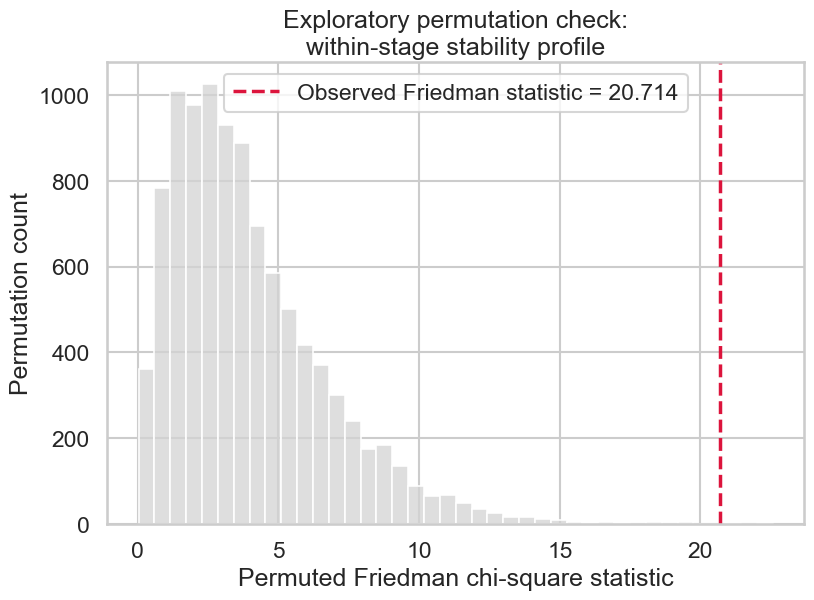

C:\Users\itxas\AppData\Local\Temp\ipykernel_20948\1364034737.py:604: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


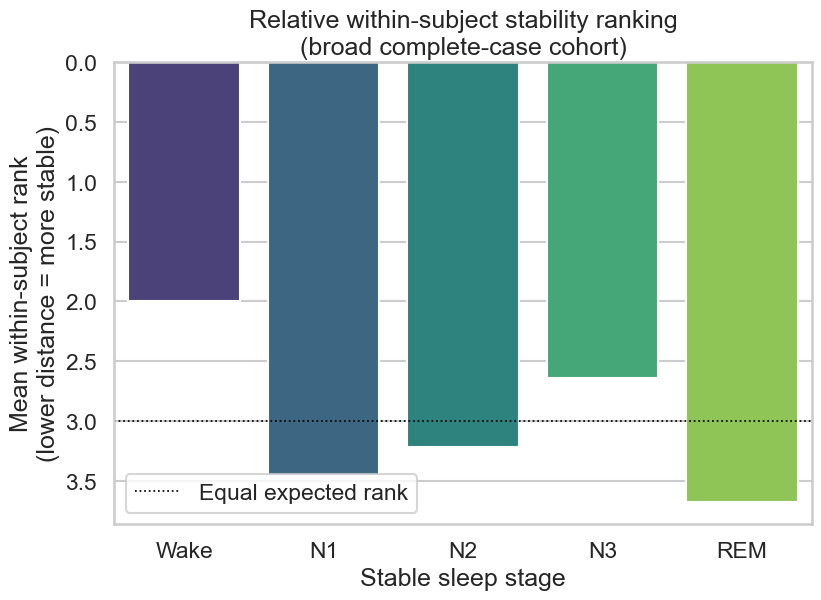


CELL 20 COMPLETE

Saved outputs:
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_friedman_broad_complete_case_stability_matrix.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_friedman_broad_complete_case_pair_counts.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_friedman_min3pairs_complete_case_stability_matrix.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_friedman_min3pairs_complete_case_pair_counts.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_within_stage_friedman_permutation_summary.csv
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_within_stage_friedman_permutation_distribution.png
- ..\graphs_output\phase_B_gatv2_autoencoder\delta_stride_10_density_20_within_stage_mean_rank_profile.png

Reporting reminder:
Treat the Friedman and permutation results as exploratory participant-level evidence.
Do not conduct stage-pair

In [71]:
# ------------------------------------------------------------------
# Cell 20 — exploratory within-stage stability statistics
#
# Research question:
#
# Does participant-level median within-stage delta graph-embedding
# displacement differ across Wake, N1, N2, N3, and REM?
#
# Input:
# subject_stage_stability_df
#
# Each row contains:
# - one participant
# - one sleep stage
# - the median 8D embedding distance across available stable,
#   adjacent 30-second epoch pairs
# - the number of pairs contributing to that median
#
# Statistical unit:
# participant
#
# Not:
# individual epoch pair
#
# Primary test:
# Friedman omnibus test across five repeated stages.
#
# Secondary robustness check:
# Within-subject label permutation test for the Friedman statistic.
#
# Important:
# This is exploratory. The GAT model was trained once, stable-pair
# selection was transition-aware, and some stage estimates are based
# on few pairs. Do not overstate a p-value as confirmatory evidence.
# ------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import friedmanchisquare


# ------------------------------------------------------------------
# 1. Verify inputs from the replacement Cell 17.
# ------------------------------------------------------------------

required_variables = [
    "subject_stage_stability_df",
    "stable_pairs_df",
    "stage_stability_summary_df",
    "stage_bootstrap_summary_df",
    "PHASE_B_OUTPUT_DIR",
    "BAND_TO_RUN",
    "EPOCH_STRIDE",
    "RETAINED_DENSITY",
    "STAGE_ORDER",
    "SEED",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run the replacement within-stage Cell 17 first.\n"
        f"Missing variables: {missing_variables}"
    )

required_columns = [
    "subject_id",
    "split",
    "stable_stage",
    "n_stable_30s_pairs",
    "median_embedding_distance",
]

missing_columns = [
    column_name
    for column_name in required_columns
    if column_name not in subject_stage_stability_df.columns
]

if missing_columns:
    raise RuntimeError(
        "subject_stage_stability_df is missing:\n"
        f"{missing_columns}"
    )


# ------------------------------------------------------------------
# 2. Helper: construct a participant × stage matrix.
#
# Each row:
# one participant
#
# Each column:
# one stable stage
#
# Each value:
# that participant's median 8D graph-embedding distance for the
# corresponding stable stage.
# ------------------------------------------------------------------

def make_complete_case_stability_matrix(
    subject_stage_df,
    stage_order,
    minimum_pairs_per_stage=1,
):
    """
    Create a complete-case participant-by-stage stability matrix.

    Parameters
    ----------
    subject_stage_df : pd.DataFrame
        Output of Cell 17.

    stage_order : list[str]
        Ordered stages:
        Wake, N1, N2, N3, REM.

    minimum_pairs_per_stage : int
        Minimum stable adjacent 30-s pairs required before a
        participant-stage median is admitted.

        1:
        Broad complete-case exploratory analysis.

        3:
        Support-filtered sensitivity analysis.

    Returns
    -------
    complete_matrix_df : pd.DataFrame
        Participants with non-missing values in every stage.

    eligibility_matrix_df : pd.DataFrame
        Full participant-by-stage matrix before complete-case removal.

    n_pairs_matrix_df : pd.DataFrame
        Corresponding number of stable pairs per subject and stage.
    """
    if minimum_pairs_per_stage < 1:
        raise ValueError(
            "minimum_pairs_per_stage must be at least 1."
        )

    stability_values_df = subject_stage_df.copy()

    # Remove weak/undefined estimates from consideration.
    stability_values_df.loc[
        stability_values_df[
            "n_stable_30s_pairs"
        ] < minimum_pairs_per_stage,
        "median_embedding_distance",
    ] = np.nan

    # Matrix of median embedding distances.
    eligibility_matrix_df = (
        stability_values_df
        .pivot(
            index="subject_id",
            columns="stable_stage",
            values="median_embedding_distance",
        )
        .reindex(columns=stage_order)
    )

    # Matrix of raw support counts.
    n_pairs_matrix_df = (
        stability_values_df
        .pivot(
            index="subject_id",
            columns="stable_stage",
            values="n_stable_30s_pairs",
        )
        .reindex(columns=stage_order)
    )

    # Retain only participants with valid values for every stage.
    complete_matrix_df = (
        eligibility_matrix_df
        .dropna(
            subset=stage_order,
            how="any",
        )
        .copy()
    )

    return (
        complete_matrix_df,
        eligibility_matrix_df,
        n_pairs_matrix_df,
    )


# ------------------------------------------------------------------
# 3. Helper: Friedman test and an optional within-subject permutation
# test.
#
# The permutation method:
# Within each participant, randomly reorder stage labels. This keeps
# each person's distribution of values intact but breaks the
# stage-to-value correspondence expected under the null hypothesis.
# ------------------------------------------------------------------

def friedman_with_permutation(
    complete_matrix_df,
    stage_order,
    n_permutations=10_000,
    random_seed=42,
):
    """
    Perform a Friedman omnibus test plus a participant-wise
    stage-label permutation check.

    Returns
    -------
    results : dict
        Friedman statistic / p-value / permutation p-value.

    observed_rank_means : pd.Series
        Mean within-subject rank for each stage.
        Lower distance = more stable, so lower rank means greater
        relative stability within participant.

    permutation_statistics : np.ndarray
        Null distribution of permuted Friedman statistics.
    """
    if len(complete_matrix_df) < 5:
        raise ValueError(
            "At least five complete-case participants are required."
        )

    values_matrix = complete_matrix_df[
        stage_order
    ].to_numpy(
        dtype=float
    )

    # scipy expects one separate vector per repeated condition.
    friedman_statistic, friedman_p_value = friedmanchisquare(
        *[
            values_matrix[:, stage_index]
            for stage_index in range(
                len(stage_order)
            )
        ]
    )

    # Rank stages within each participant.
    #
    # Rank 1 = smallest embedding distance = most stable stage for
    # that participant under this metric.
    rank_matrix = (
        pd.DataFrame(
            values_matrix,
            columns=stage_order,
        )
        .rank(
            axis=1,
            method="average",
            ascending=True,
        )
    )

    observed_rank_means = rank_matrix.mean(
        axis=0
    )

    # Permutation null distribution.
    permutation_rng = np.random.default_rng(
        random_seed
    )

    permutation_statistics = np.empty(
        n_permutations,
        dtype=float,
    )

    for permutation_index in range(
        n_permutations
    ):

        permuted_matrix = np.empty_like(
            values_matrix
        )

        # Shuffle the five stage labels independently within each
        # participant.
        for subject_index in range(
            values_matrix.shape[0]
        ):
            permuted_matrix[subject_index] = (
                permutation_rng.permutation(
                    values_matrix[subject_index]
                )
            )

        permuted_statistic, _ = friedmanchisquare(
            *[
                permuted_matrix[:, stage_index]
                for stage_index in range(
                    len(stage_order)
                )
            ]
        )

        permutation_statistics[
            permutation_index
        ] = permuted_statistic

    # Add one to numerator and denominator for a valid Monte-Carlo
    # p-value even if no permutation is more extreme.
    permutation_p_value = (
        1
        + np.sum(
            permutation_statistics
            >= friedman_statistic
        )
    ) / (
        n_permutations + 1
    )

    return {
        "n_complete_case_subjects": int(
            len(complete_matrix_df)
        ),
        "friedman_chi_square": float(
            friedman_statistic
        ),
        "friedman_p_value": float(
            friedman_p_value
        ),
        "permutation_p_value": float(
            permutation_p_value
        ),
    }, observed_rank_means, permutation_statistics


# ------------------------------------------------------------------
# 4. Broad complete-case analysis:
# At least one stable 30-s pair per stage.
# ------------------------------------------------------------------

(
    broad_complete_matrix_df,
    broad_eligibility_matrix_df,
    broad_pair_count_matrix_df,
) = make_complete_case_stability_matrix(
    subject_stage_df=subject_stage_stability_df,
    stage_order=STAGE_ORDER,
    minimum_pairs_per_stage=1,
)

print("=" * 70)
print("BROAD COMPLETE-CASE ANALYSIS")
print("=" * 70)

print(
    "Minimum stable pairs required per subject-stage: 1"
)

print(
    "Participants with all five non-missing stable-stage estimates:",
    len(broad_complete_matrix_df),
)

print("\nParticipants retained:")
print(
    broad_complete_matrix_df.index.tolist()
)

print("\nBroad complete-case stability matrix:")
display(
    broad_complete_matrix_df
)


# ------------------------------------------------------------------
# 5. Support-filtered sensitivity analysis:
# At least three stable 30-s pairs for every stage.
#
# This is not a model-selection procedure. It tests whether the
# conclusion is qualitatively similar after excluding medians based
# on one or two pairs.
# ------------------------------------------------------------------

(
    filtered_complete_matrix_df,
    filtered_eligibility_matrix_df,
    filtered_pair_count_matrix_df,
) = make_complete_case_stability_matrix(
    subject_stage_df=subject_stage_stability_df,
    stage_order=STAGE_ORDER,
    minimum_pairs_per_stage=3,
)

print("\n" + "=" * 70)
print("SUPPORT-FILTERED SENSITIVITY ANALYSIS")
print("=" * 70)

print(
    "Minimum stable pairs required per subject-stage: 3"
)

print(
    "Participants with at least three stable pairs in every stage:",
    len(filtered_complete_matrix_df),
)

print("\nParticipants retained:")
print(
    filtered_complete_matrix_df.index.tolist()
)


# ------------------------------------------------------------------
# 6. Run the broad Friedman and permutation tests.
# ------------------------------------------------------------------

BROAD_PERMUTATION_ITERATIONS = 10_000

(
    broad_test_results,
    broad_mean_stage_ranks,
    broad_permutation_statistics,
) = friedman_with_permutation(
    complete_matrix_df=broad_complete_matrix_df,
    stage_order=STAGE_ORDER,
    n_permutations=BROAD_PERMUTATION_ITERATIONS,
    random_seed=SEED,
)

print("\n" + "=" * 70)
print("BROAD FRIEDMAN OMNIBUS RESULT")
print("=" * 70)

for result_name, result_value in broad_test_results.items():

    if isinstance(result_value, float):
        print(
            f"{result_name}: "
            f"{result_value:.4f}"
        )
    else:
        print(
            f"{result_name}: "
            f"{result_value}"
        )

print(
    "\nMean within-subject ranks "
    "(lower embedding distance = greater relative stability):"
)

print(
    broad_mean_stage_ranks
    .reindex(STAGE_ORDER)
)


# ------------------------------------------------------------------
# 7. Run the filtered sensitivity test only if enough participants
# remain.
# ------------------------------------------------------------------

FILTERED_PERMUTATION_ITERATIONS = 10_000

if len(filtered_complete_matrix_df) >= 5:

    (
        filtered_test_results,
        filtered_mean_stage_ranks,
        filtered_permutation_statistics,
    ) = friedman_with_permutation(
        complete_matrix_df=filtered_complete_matrix_df,
        stage_order=STAGE_ORDER,
        n_permutations=FILTERED_PERMUTATION_ITERATIONS,
        random_seed=SEED + 1,
    )

    print("\n" + "=" * 70)
    print("SUPPORT-FILTERED FRIEDMAN SENSITIVITY RESULT")
    print("=" * 70)

    for result_name, result_value in (
        filtered_test_results.items()
    ):

        if isinstance(result_value, float):
            print(
                f"{result_name}: "
                f"{result_value:.4f}"
            )
        else:
            print(
                f"{result_name}: "
                f"{result_value}"
            )

    print(
        "\nMean within-subject ranks "
        "(lower = more stable):"
    )

    print(
        filtered_mean_stage_ranks
        .reindex(STAGE_ORDER)
    )

else:

    filtered_test_results = None
    filtered_mean_stage_ranks = None
    filtered_permutation_statistics = None

    print("\nSupport-filtered sensitivity test not run.")
    print(
        "Fewer than five participants had at least three stable "
        "adjacent pairs in every stage."
    )


# ------------------------------------------------------------------
# 8. Create a concise permutation null-distribution figure for the
# broad analysis.
#
# The dashed vertical line is the observed Friedman statistic.
# ------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 6),
)

sns.histplot(
    broad_permutation_statistics,
    bins=40,
    color="lightgray",
    edgecolor="white",
    ax=ax,
)

ax.axvline(
    broad_test_results[
        "friedman_chi_square"
    ],
    color="crimson",
    linewidth=2.5,
    linestyle="--",
    label=(
        "Observed Friedman statistic = "
        f"{broad_test_results['friedman_chi_square']:.3f}"
    ),
)

ax.set_title(
    "Exploratory permutation check:\n"
    "within-stage stability profile"
)

ax.set_xlabel(
    "Permuted Friedman chi-square statistic"
)

ax.set_ylabel("Permutation count")

ax.legend()

plt.show()


# ------------------------------------------------------------------
# 9. Create a clean stage-rank plot.
#
# Lower rank:
# a stage tended to have lower within-subject median embedding
# distances and therefore greater relative stability.
#
# This plot describes relative ordering inside complete-case subjects;
# it should be interpreted alongside the raw distance summaries and
# their bootstrap intervals from Cell 17.
# ------------------------------------------------------------------

fig_rank, ax_rank = plt.subplots(
    figsize=(9, 6),
)

rank_plot_df = pd.DataFrame(
    {
        "stage": STAGE_ORDER,
        "mean_within_subject_rank": (
            broad_mean_stage_ranks
            .reindex(STAGE_ORDER)
            .to_numpy()
        ),
    }
)

sns.barplot(
    data=rank_plot_df,
    x="stage",
    y="mean_within_subject_rank",
    palette="viridis",
    ax=ax_rank,
)

ax_rank.axhline(
    3,
    color="black",
    linestyle=":",
    linewidth=1.25,
    label="Equal expected rank",
)

ax_rank.invert_yaxis()

ax_rank.set_title(
    "Relative within-subject stability ranking\n"
    "(broad complete-case cohort)"
)

ax_rank.set_xlabel("Stable sleep stage")

ax_rank.set_ylabel(
    "Mean within-subject rank\n"
    "(lower distance = more stable)"
)

ax_rank.legend()

plt.show()


# ------------------------------------------------------------------
# 10. Save all outputs.
# ------------------------------------------------------------------

broad_matrix_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_friedman_broad_complete_case_stability_matrix.csv"
)

broad_pair_count_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_friedman_broad_complete_case_pair_counts.csv"
)

filtered_matrix_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_friedman_min3pairs_complete_case_stability_matrix.csv"
)

filtered_pair_count_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_friedman_min3pairs_complete_case_pair_counts.csv"
)

friedman_summary_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_within_stage_friedman_permutation_summary.csv"
)

permutation_figure_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_within_stage_friedman_permutation_distribution.png"
)

rank_figure_path = PHASE_B_OUTPUT_DIR / (
    f"{BAND_TO_RUN}_"
    f"stride_{EPOCH_STRIDE}_"
    f"density_{int(RETAINED_DENSITY * 100)}"
    "_within_stage_mean_rank_profile.png"
)

broad_complete_matrix_df.to_csv(
    broad_matrix_path,
    index=True,
)

broad_pair_count_matrix_df.loc[
    broad_complete_matrix_df.index,
    STAGE_ORDER,
].to_csv(
    broad_pair_count_path,
    index=True,
)

filtered_complete_matrix_df.to_csv(
    filtered_matrix_path,
    index=True,
)

if len(filtered_complete_matrix_df) > 0:
    filtered_pair_count_matrix_df.loc[
        filtered_complete_matrix_df.index,
        STAGE_ORDER,
    ].to_csv(
        filtered_pair_count_path,
        index=True,
    )

summary_rows = [
    {
        "analysis": "broad_complete_case_min_1_pair",
        **broad_test_results,
    }
]

if filtered_test_results is not None:
    summary_rows.append(
        {
            "analysis": "sensitivity_complete_case_min_3_pairs",
            **filtered_test_results,
        }
    )

friedman_summary_df = pd.DataFrame(
    summary_rows
)

friedman_summary_df.to_csv(
    friedman_summary_path,
    index=False,
)

fig.savefig(
    permutation_figure_path,
    dpi=300,
    bbox_inches="tight",
)

fig_rank.savefig(
    rank_figure_path,
    dpi=300,
    bbox_inches="tight",
)

print("\n" + "=" * 70)
print("CELL 20 COMPLETE")
print("=" * 70)

print("\nSaved outputs:")
print("-", broad_matrix_path)
print("-", broad_pair_count_path)
print("-", filtered_matrix_path)
print("-", filtered_pair_count_path)
print("-", friedman_summary_path)
print("-", permutation_figure_path)
print("-", rank_figure_path)

print("\nReporting reminder:")
print(
    "Treat the Friedman and permutation results as exploratory "
    "participant-level evidence."
)

print(
    "Do not conduct stage-pair post-hoc tests unless the omnibus "
    "result is clearly supported and the support-filtered sensitivity "
    "analysis is compatible."
)

In an exploratory 28-participant cohort analysis, the difference between participant-level median delta-band embedding displacement at scored sleep-stage transitions and stable 30-second pairs was heterogeneous and centered near zero (mean difference = 0.0051 =0.0051, bootstrap 95% CI − 0.0046 −0.0046 to 0.0157 0.0157; median difference = − 0.0020 =−0.0020, bootstrap 95% CI − 0.0112 −0.0112 to 0.0091 0.0091). Fourteen participants showed positive and fourteen negative differences. Thus, this transition-enriched analysis did not identify a uniform abrupt delta-network reconfiguration at all scored sleep-stage boundaries.

**Phase B proof-of-concept package:**

1. Method: edge-aware GATv2 autoencoder on sparse, dynamic delta wPLI graphs.
2. Technical validation: subject-disjoint 22/3/3 split; stable training; held-out reconstruction.
3. Representation output: 8D graph embeddings for 7,154 selected epoch graphs.
4. Dynamic test: participant-level stable-versus-transition comparison.
5. Result: no uniform pooled effect; marked individual heterogeneity.
6. Interpretation: discrete hypnogram boundaries do not consistently align with abrupt shifts in this learned delta graph representation.